# Utica, NY - Buy vs Rent Financial Analysis

This notebook performs the same comprehensive financial analysis for Utica, NY as done for New York, NY.


## PART I: DATA LOADING AND PREPROCESSING

### 1. House Prices Data (Two-Bedroom Home Values)


In [163]:
import pandas as pd

# Load house prices data
df = pd.read_csv('../data/two_family/two_bedroom_home_values_zhvi.csv')
print("Dataset Shape:", df.shape)
print("\nColumn Names (first 10):")
print(df.columns.tolist()[:10])
print(f"\nTotal columns: {len(df.columns)}")
df.head()


Dataset Shape: (851, 315)

Column Names (first 10):
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2000-01-31', '2000-02-29', '2000-03-31', '2000-04-30', '2000-05-31']

Total columns: 315


,RegionID,SizeRank,RegionName,RegionType,StateName,2000-01-31,2000-02-29,2000-03-31,2000-04-30,2000-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,83344.619196,83497.156791,83684.847454,84091.160679,84557.592462,...,277241.936397,277526.843786,277198.318728,276742.253826,276169.920203,275633.122039,275112.204608,274665.813407,274477.206797,274460.149670
1,394913,1,"New York, NY",msa,NY,149779.400352,150341.824571,150875.340267,151997.364168,153210.460044,...,495499.014408,496921.015548,498134.411859,499606.306898,500627.053011,501426.543280,501943.159082,502520.987387,503787.986518,505959.517755
2,753899,2,"Los Angeles, CA",msa,CA,169268.869371,169770.742761,170557.108176,172122.066322,173918.512499,...,739340.366867,737367.317096,732430.376873,727847.217695,723154.901146,719715.670089,717796.297400,717200.432449,717758.646596,719204.031024
3,394463,3,"Chicago, IL",msa,IL,101240.341888,101307.680756,101494.824515,101957.624150,102486.461458,...,252355.909350,253601.969084,254472.719490,255259.830574,255858.780978,256472.099230,257137.517327,257805.365792,258636.005319,259640.316581
4,394514,4,"Dallas, TX",msa,TX,69947.134256,69950.433460,69921.040192,69949.877922,70042.336016,...,231877.347334,231554.401161,230705.281883,229449.430718,227668.139913,225851.865008,224088.182881,222762.971545,221753.254434,220990.167480


In [164]:
# Check for Utica in the dataset
print("Unique Region Names (first 30):")
print(df['RegionName'].unique()[:30])
print("\nChecking for Utica:")
utica_regions = df[df['RegionName'].str.contains('Utica', case=False, na=False)]
print(f"Found {len(utica_regions)} regions with 'Utica' in name:")
if len(utica_regions) > 0:
    print(utica_regions[['RegionName', 'StateName']].to_string())
else:
    print("No Utica found. Checking all NY regions:")
    ny_regions = df[df['StateName'] == 'NY']
    print(f"Found {len(ny_regions)} NY regions:")
    print(ny_regions[['RegionName', 'StateName']].head(20).to_string())


Unique Region Names (first 30):
['United States' 'New York, NY' 'Los Angeles, CA' 'Chicago, IL'
 'Dallas, TX' 'Houston, TX' 'Washington, DC' 'Philadelphia, PA'
 'Miami, FL' 'Atlanta, GA' 'Boston, MA' 'Phoenix, AZ' 'San Francisco, CA'
 'Riverside, CA' 'Detroit, MI' 'Seattle, WA' 'Minneapolis, MN'
 'San Diego, CA' 'Tampa, FL' 'Denver, CO' 'Baltimore, MD' 'St. Louis, MO'
 'Orlando, FL' 'Charlotte, NC' 'San Antonio, TX' 'Portland, OR'
 'Sacramento, CA' 'Pittsburgh, PA' 'Cincinnati, OH' 'Austin, TX']

Checking for Utica:
Found 1 regions with 'Utica' in name:
    RegionName StateName
165  Utica, NY        NY


In [165]:
import matplotlib.pyplot as plt

# Filter for Utica, NY
# Note: Adjust the exact region name based on what was found above
utica_house_prices_df = df[df["RegionName"].str.contains("Utica", case=False, na=False)].copy()

if len(utica_house_prices_df) == 0:
    print("Utica not found. Please check the exact region name.")
else:
    print(f"Selected region: {utica_house_prices_df[['RegionName', 'StateName']].values}")
    
    # Drop non-date columns
    price_data = utica_house_prices_df.loc[:, "2015-01-31":]
    
    # Convert to long format
    price_long = price_data.melt(var_name="Date", value_name="MedianPrice")
    
    # Convert Date column to datetime
    price_long["Date"] = pd.to_datetime(price_long["Date"])
    price_long["Date"] = price_long["Date"].dt.to_period("M").dt.to_timestamp()
    
    # Sort by date
    price_long = price_long.sort_values("Date")
    
    # Basic stats on the price data
    print(f"\nPrice data statistics:")
    print(price_long['MedianPrice'].describe())
    print(f"\nDate range: {price_long['Date'].min()} to {price_long['Date'].max()}")
    print(f"Total data points: {len(price_long)}")
    print(f"Missing values: {price_long['MedianPrice'].isna().sum()}")


Selected region: [['Utica, NY' 'NY']]

Price data statistics:
count       130.000000
mean     121286.768093
std       31992.576447
min       81424.252918
25%       91552.923194
50%      110086.365138
75%      149771.080886
max      181648.149140
Name: MedianPrice, dtype: float64

Date range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00
Total data points: 130
Missing values: 0


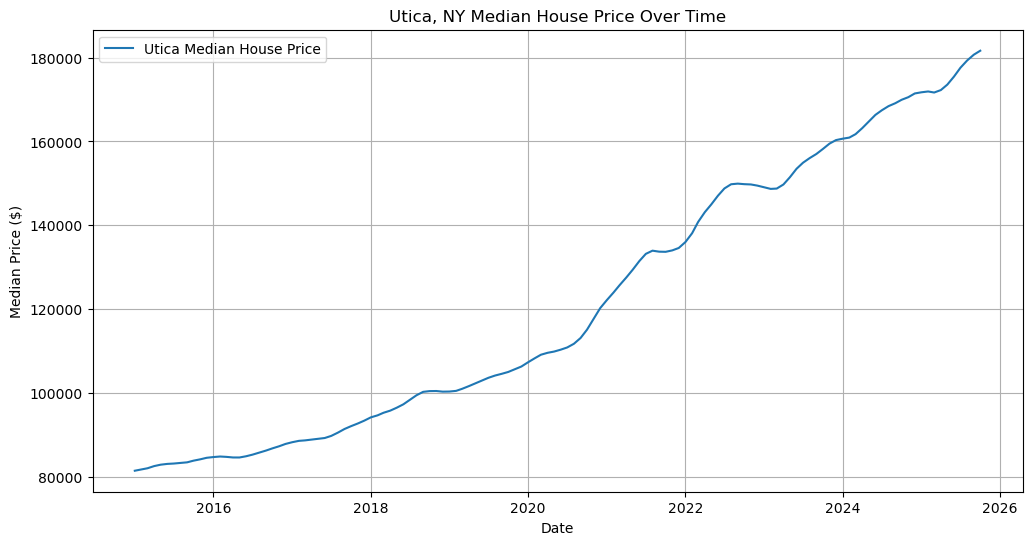

In [166]:
# Visualize house prices
if len(utica_house_prices_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.plot(price_long["Date"], price_long["MedianPrice"], label="Utica Median House Price")
    plt.title("Utica, NY Median House Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Median Price ($)")
    plt.legend()
    plt.grid(True)
    plt.show()


In [167]:
# Check for duplicates and missing values
if len(utica_house_prices_df) > 0:
    print("Duplicate rows:", utica_house_prices_df.duplicated().sum())
    print("Duplicate RegionIDs:", utica_house_prices_df.duplicated(subset=['RegionID']).sum())
    print("\nTotal missing values:", utica_house_prices_df.isna().sum().sum())
    
    # Fill missing values using forward fill
    utica_house_prices_df = utica_house_prices_df.fillna(method='ffill', axis=1)
    
    # Re-process after filling
    price_data = utica_house_prices_df.loc[:, "2015-01-31":]
    price_long = price_data.melt(var_name="Date", value_name="MedianPrice")
    price_long["Date"] = pd.to_datetime(price_long["Date"])
    price_long["Date"] = price_long["Date"].dt.to_period("M").dt.to_timestamp()
    price_long = price_long.sort_values("Date")
    
    print("\nAfter filling missing values:")
    print(f"Missing values: {price_long['MedianPrice'].isna().sum()}")
    
    # Save to CSV
    price_long.to_csv("../data/output_utica/utica_house_price_long.csv", index=False)
    print("\n✓ Saved to: ../data/output_utica/utica_house_price_long.csv")


Duplicate rows: 0
Duplicate RegionIDs: 0

Total missing values: 0

After filling missing values:
Missing values: 0

✓ Saved to: ../data/output_utica/utica_house_price_long.csv


### 2. Rental Prices Data (Multifamily Rental Values)


In [168]:
# Read rental prices data
df_rental = pd.read_csv('../data/two_family/multifamily_rental_values_zori.csv')
print("Dataset Shape:", df_rental.shape)
print("\nColumn Names (first 10):")
print(df_rental.columns.tolist()[:10])
print(f"\nTotal columns: {len(df_rental.columns)}")
df_rental.head()


Dataset Shape: (584, 135)

Column Names (first 10):
['RegionID', 'SizeRank', 'RegionName', 'RegionType', 'StateName', '2015-01-31', '2015-02-28', '2015-03-31', '2015-04-30', '2015-05-31']

Total columns: 135


,RegionID,SizeRank,RegionName,RegionType,StateName,2015-01-31,2015-02-28,2015-03-31,2015-04-30,2015-05-31,...,2025-01-31,2025-02-28,2025-03-31,2025-04-30,2025-05-31,2025-06-30,2025-07-31,2025-08-31,2025-09-30,2025-10-31
0,102001,0,United States,country,NaN,1158.783988,1163.832511,1171.228028,1175.383296,1179.722988,...,1759.350958,1762.586059,1764.857840,1766.494654,1767.438485,1769.352650,1771.503856,1774.625304,1777.314551,1779.303397
1,394913,1,"New York, NY",msa,NY,2264.111314,2278.386759,2291.166855,2302.839542,2309.751952,...,3245.116452,3258.020542,3269.225487,3278.078413,3285.458244,3298.403296,3318.815111,3340.302367,3357.934444,3372.411185
2,753899,2,"Los Angeles, CA",msa,CA,1671.176815,1680.585170,1693.221301,1708.879031,1722.529108,...,2651.097018,2656.867508,2659.684129,2660.694913,2660.979740,2663.835613,2665.229675,2669.891583,2672.608704,2675.925646
3,394463,3,"Chicago, IL",msa,IL,1312.935431,1313.914270,1319.733261,1322.067956,1326.647735,...,1889.175377,1898.419009,1907.877827,1917.834781,1927.050832,1936.667240,1946.329096,1955.600635,1964.607449,1971.554976
4,394514,4,"Dallas, TX",msa,TX,1040.141326,1036.535751,1039.603121,1052.215637,1058.206610,...,1522.378780,1523.219947,1522.109029,1522.868214,1520.149379,1518.771051,1516.142182,1515.500922,1515.062818,1512.591988


In [169]:
# Check for Utica in rental data
print("Checking for Utica:")
utica_rental = df_rental[df_rental['RegionName'].str.contains('Utica', case=False, na=False)]
print(f"Found {len(utica_rental)} regions with 'Utica' in name:")
if len(utica_rental) > 0:
    print(utica_rental[['RegionName', 'StateName']].to_string())
else:
    print("No Utica found. Checking all NY regions:")
    ny_rental = df_rental[df_rental['StateName'] == 'NY']
    print(f"Found {len(ny_rental)} NY regions:")
    print(ny_rental[['RegionName', 'StateName']].head(20).to_string())


Checking for Utica:
Found 1 regions with 'Utica' in name:
    RegionName StateName
167  Utica, NY        NY


In [170]:
# Filter for Utica, NY
utica_rental_prices_df = df_rental[df_rental['RegionName'].str.contains('Utica', case=False, na=False)].copy()

if len(utica_rental_prices_df) == 0:
    print("Utica not found in rental data. Please check the exact region name.")
else:
    print(f"Selected region: {utica_rental_prices_df[['RegionName', 'StateName']].values}")
    print(f"Shape: {utica_rental_prices_df.shape}")
    
    # Check for duplicates
    print("\nDuplicate rows:", utica_rental_prices_df.duplicated().sum())
    print("Duplicate RegionIDs:", utica_rental_prices_df.duplicated(subset=['RegionID']).sum())
    
    # Check for missing values
    print("\nTotal missing values:", utica_rental_prices_df.isna().sum().sum())


Selected region: [['Utica, NY' 'NY']]
Shape: (1, 135)

Duplicate rows: 0
Duplicate RegionIDs: 0

Total missing values: 100


In [171]:
# Process rental data
if len(utica_rental_prices_df) > 0:
    # Drop non-date columns
    rental_price_data = utica_rental_prices_df.loc[:, "2015-01-31":]
    
    # Convert to long format
    rental_long = rental_price_data.melt(var_name="Date", value_name="RentalPrice")
    
    # Convert Date column to datetime
    rental_long["Date"] = pd.to_datetime(rental_long["Date"])
    
    # Sort by date
    rental_long = rental_long.sort_values("Date")
    
    # Set Date as index
    rental_long = rental_long.set_index("Date")
    
    # Basic stats on the rental data
    print(f"\nRental data statistics:")
    print(rental_long['RentalPrice'].describe())
    print(f"\nDate range: {rental_long.index.min()} to {rental_long.index.max()}")
    print(f"Total data points: {len(rental_long)}")
    print(f"Missing values: {rental_long['RentalPrice'].isna().sum()}")



Rental data statistics:
count      30.000000
mean     1182.884361
std        50.464142
min      1096.317712
25%      1142.365632
50%      1186.314198
75%      1212.659131
max      1281.287879
Name: RentalPrice, dtype: float64

Date range: 2015-01-31 00:00:00 to 2025-10-31 00:00:00
Total data points: 130
Missing values: 100


In [172]:
# Handle missing values in rental data
if len(utica_rental_prices_df) > 0:
    rental_long = rental_long.sort_index()
    
    # Interpolate missing values (time-based) first
    rental_long["RentalPrice"] = rental_long["RentalPrice"].interpolate(method="time")
    
    # If any missing remain, forward and backward fill
    missing_after_interp = rental_long["RentalPrice"].isna().sum()
    if missing_after_interp > 0:
        rental_long["RentalPrice"] = rental_long["RentalPrice"].ffill().bfill()
    
    print('Missing Values after interpolation and fill:', rental_long["RentalPrice"].isna().sum())
    
    # Convert index to monthly period and back to timestamp
    rental_long.index = rental_long.index.to_period("M").to_timestamp()
    
    # Verify ready for time series
    print("\nVerification:")
    print("Date range:", rental_long.index.min(), "to", rental_long.index.max())
    print("Total points:", len(rental_long))
    print("Date is datetime:", pd.api.types.is_datetime64_any_dtype(rental_long.index))
    print("No missing:", rental_long['RentalPrice'].isna().sum() == 0)
    print("No duplicates:", rental_long.index.duplicated().sum() == 0)
    print("Is sorted:", rental_long.index.is_monotonic_increasing)
    
    # Save to CSV
    rental_long.to_csv("../data/output_utica/utica_rental_long.csv", index=True)
    print("\n✓ Saved to: ../data/output_utica/utica_rental_long.csv")


Missing Values after interpolation and fill: 0

Verification:
Date range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00
Total points: 130
Date is datetime: True
No missing: True
No duplicates: True
Is sorted: True

✓ Saved to: ../data/output_utica/utica_rental_long.csv


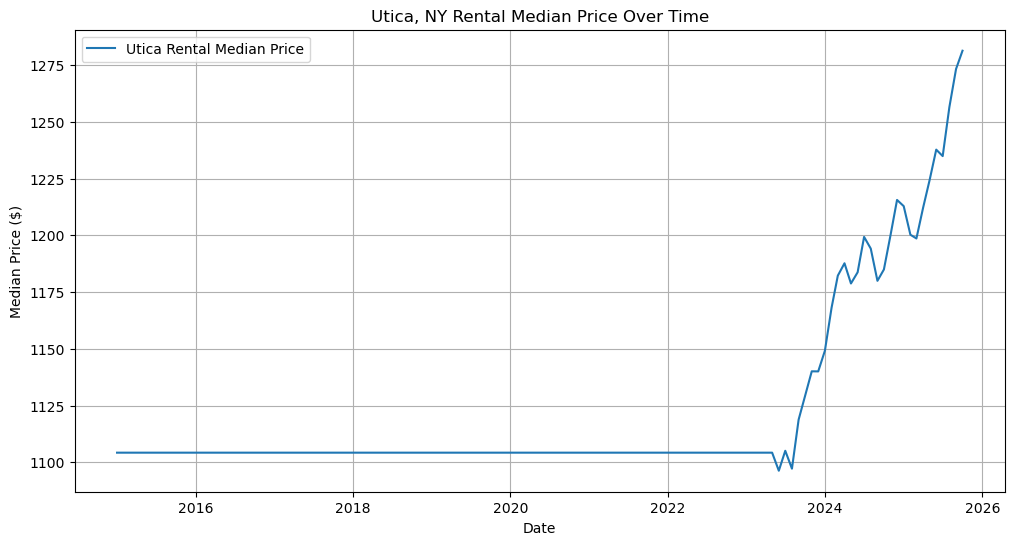

In [173]:
# Visualize rental prices
if len(utica_rental_prices_df) > 0:
    plt.figure(figsize=(12, 6))
    plt.plot(rental_long.index, rental_long["RentalPrice"], label="Utica Rental Median Price")
    plt.title("Utica, NY Rental Median Price Over Time")
    plt.xlabel("Date")
    plt.ylabel("Median Price ($)")
    plt.legend()
    plt.grid(True)
    plt.show()


### 3. Mortgage Rates Data (30-Year Fixed Rate)


In [174]:
# ============================================
# MORTGAGE RATES PREPROCESSING (Monthly Mean)
# ============================================
# Note: Mortgage rates are national, same for all cities

from fredapi import Fred
import os
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv()

# Get FRED API key from environment
fred = Fred(api_key=os.getenv("FRED_API_KEY"))

# Pull 30-Year Fixed Rate Mortgage, weekly data
mortgage = fred.get_series(
    "MORTGAGE30US", start_date="2015-01-01", end_date="2025-12-01"
)

# Convert to DataFrame
mortgage_df = mortgage.to_frame(name="mortgage_rate")
mortgage_df.index.name = "Date"

# Reset index to have Date as a column
mortgage_df = mortgage_df.reset_index()

# Filter for dates from 2015-01-01 onward
mortgage_df = mortgage_df[mortgage_df["Date"] >= "2015-01-01"]

# Convert Date to datetime
mortgage_df["Date"] = pd.to_datetime(mortgage_df["Date"])

# Set Date as index for resampling
mortgage_df = mortgage_df.set_index("Date")

# Resample to monthly frequency, taking the mean of all weeks in the month
mortgage_monthly = mortgage_df.resample("MS").mean()  # 'MS' = Month Start

# Reset index to have Date as a column
mortgage_monthly = mortgage_monthly.reset_index()

# Preview
print("Mortgage Rates Data:")
print(mortgage_monthly.head())
print(f"\nDate range: {mortgage_monthly['Date'].min()} to {mortgage_monthly['Date'].max()}")
print(f"Total data points: {len(mortgage_monthly)}")


Mortgage Rates Data:
        Date  mortgage_rate
0 2015-01-01          3.670
1 2015-02-01          3.710
2 2015-03-01          3.770
3 2015-04-01          3.672
4 2015-05-01          3.840

Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00
Total data points: 132


In [175]:
# Save mortgage rates to CSV
mortgage_monthly.to_csv(
    "../data/output_utica/utica_mortgage_monthly.csv",  
    index=True,
    float_format='%.2f')

mortgage_monthly = mortgage_monthly.set_index("Date")
mortgage_monthly.index = pd.to_datetime(mortgage_monthly.index)

print("✓ Saved to: ../data/output_utica/utica_mortgage_monthly.csv")
mortgage_monthly.head()


✓ Saved to: ../data/output_utica/utica_mortgage_monthly.csv


,mortgage_rate
Date,
2015-01-01,3.670
2015-02-01,3.710
2015-03-01,3.770
2015-04-01,3.672
2015-05-01,3.840


### 4. Merge All Data


In [176]:
# ============================================
# MERGE ALL DATA
# ============================================

# Check if we have both house and rental data
if len(utica_house_prices_df) > 0 and len(utica_rental_prices_df) > 0:
    # Reset indices to merge on Date
    price_long_reset = price_long.reset_index()
    rental_long_reset = rental_long.reset_index()
    mortgage_reset = mortgage_monthly.reset_index()
    
    # Convert all dates to end of month for alignment
    price_long_reset['Date'] = pd.to_datetime(price_long_reset['Date'])
    rental_long_reset['Date'] = pd.to_datetime(rental_long_reset['Date'])
    mortgage_reset['Date'] = pd.to_datetime(mortgage_reset['Date'])
    
    # Merge house prices and rental prices first (both monthly)
    merged_df = pd.merge(price_long_reset, rental_long_reset, on='Date', how='inner')
    
    # Merge with mortgage rates
    merged_df = pd.merge(merged_df, mortgage_reset, on='Date', how='inner')
    
    # Sort by date
    merged_df = merged_df.sort_values('Date')
    
    # Filter to common date range (2015 onwards where all data exists)
    merged_df = merged_df[merged_df['Date'] >= '2015-01-01']
    
    # Set Date as index
    merged_df = merged_df.set_index('Date')
    
    print("Merged dataset shape:", merged_df.shape)
    print("\nFirst few rows:")
    print(merged_df.head())
    print("\nLast few rows:")
    print(merged_df.tail())
    print("\nMissing values:")
    print(merged_df.isna().sum())
    
    # Save merged data
    merged_df.to_csv("../data/output_utica/utica_merged_housing_data.csv", index=True)
    print("\n✓ Saved to: ../data/output_utica/utica_merged_housing_data.csv")
else:
    print("ERROR: Missing house prices or rental prices data. Cannot merge.")


Merged dataset shape: (130, 4)

First few rows:
            index   MedianPrice  RentalPrice  mortgage_rate
Date                                                       
2015-01-01      0  81424.252918  1104.266923          3.670
2015-02-01      1  81721.737358  1104.266923          3.710
2015-03-01      2   82012.18827  1104.266923          3.770
2015-04-01      3  82529.956518  1104.266923          3.672
2015-05-01      4  82864.453664  1104.266923          3.840

Last few rows:
            index    MedianPrice  RentalPrice  mortgage_rate
Date                                                        
2025-06-01    125  175473.232739  1237.726958         6.8175
2025-07-01    126  177586.909218  1234.878164         6.7200
2025-08-01    127  179313.114161  1256.433676         6.5875
2025-09-01    128  180697.310734  1273.231192         6.3525
2025-10-01    129   181648.14914  1281.287879         6.2540

Missing values:
index            0
MedianPrice      0
RentalPrice      0
mortgage_rate  

## PART II: TIME SERIES FORECASTING

### 5. Prophet Forecasting Models


In [177]:
# ============================================
# TIME SERIES FORECASTING WITH PROPHET
# ============================================

from prophet import Prophet
import warnings
warnings.filterwarnings('ignore')

print("Prophet library imported successfully!")


Prophet library imported successfully!


In [178]:
# Prepare house prices for Prophet (needs 'ds' and 'y' columns)
if len(utica_house_prices_df) > 0:
    house_prices_prophet = price_long.reset_index().rename(columns={'Date': 'ds', 'MedianPrice': 'y'})
    
    # Create and fit Prophet model for house prices
    print("Fitting Prophet model for Utica house prices...")
    model_house = Prophet()
    model_house.fit(house_prices_prophet)
    
    # Create future dataframe (10 years = 120 months)
    future_house = model_house.make_future_dataframe(periods=120, freq='M')
    
    # Make forecast
    forecast_house = model_house.predict(future_house)
    
    print("\nHouse Prices Forecast (Prophet):")
    print(f"Forecast period: {forecast_house['ds'].min()} to {forecast_house['ds'].max()}")
    print(f"\nLast 5 forecasted values:")
    print(forecast_house[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())
else:
    print("ERROR: House prices data not available.")


18:07:53 - cmdstanpy - INFO - Chain [1] start processing


Fitting Prophet model for Utica house prices...


18:07:53 - cmdstanpy - INFO - Chain [1] done processing



House Prices Forecast (Prophet):
Forecast period: 2015-01-01 00:00:00 to 2035-09-30 00:00:00

Last 5 forecasted values:
            ds           yhat     yhat_lower     yhat_upper
245 2035-05-31  289248.810843  225999.758628  347112.665402
246 2035-06-30  290235.308786  225650.389421  349505.367184
247 2035-07-31  291126.893008  225420.742254  351734.573479
248 2035-08-31  291808.364652  225223.833282  353095.499492
249 2035-09-30  292494.553873  225082.168860  354770.435479


In [179]:
# Prepare rental prices for Prophet
if len(utica_rental_prices_df) > 0:
    rental_prices_prophet = rental_long.reset_index().rename(columns={'Date': 'ds', 'RentalPrice': 'y'})
    
    # Create and fit Prophet model for rental prices
    print("Fitting Prophet model for Utica rental prices...")
    model_rental = Prophet()
    model_rental.fit(rental_prices_prophet)
    
    # Create future dataframe (10 years forecast)
    future_rental = model_rental.make_future_dataframe(periods=120, freq='M')
    
    # Make forecast
    forecast_rental = model_rental.predict(future_rental)
    
    print("\nRental Prices Forecast (Prophet):")
    print(f"Forecast period: {forecast_rental['ds'].min()} to {forecast_rental['ds'].max()}")
    print(f"\nLast 5 forecasted values:")
    print(forecast_rental[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())
else:
    print("ERROR: Rental prices data not available.")


18:07:53 - cmdstanpy - INFO - Chain [1] start processing
18:07:53 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet model for Utica rental prices...

Rental Prices Forecast (Prophet):
Forecast period: 2015-01-01 00:00:00 to 2035-09-30 00:00:00

Last 5 forecasted values:
            ds         yhat   yhat_lower   yhat_upper
245 2035-05-31  1902.449088  1768.844405  2027.045729
246 2035-06-30  1907.456993  1772.442632  2032.650634
247 2035-07-31  1906.862156  1769.555052  2034.623167
248 2035-08-31  1927.418715  1789.576476  2057.621396
249 2035-09-30  1930.583737  1789.876214  2059.546528


In [180]:
# Forecast mortgage rates with Prophet
mortgage_prophet = mortgage_monthly.reset_index().rename(columns={"Date": "ds", "mortgage_rate": "y"})

# Create and fit Prophet model for mortgage rates
print("Fitting Prophet model for mortgage rates...")
model_mortgage = Prophet()
model_mortgage.fit(mortgage_prophet)

# Create future dataframe (10 years forecast)
future_mortgage = model_mortgage.make_future_dataframe(periods=120, freq='M')

# Make forecast
forecast_mortgage = model_mortgage.predict(future_mortgage)

print("\nMortgage Rates Forecast (Prophet):")
print(f"Forecast period: {forecast_mortgage['ds'].min()} to {forecast_mortgage['ds'].max()}")
print(f"\nLast 5 forecasted values:")
print(forecast_mortgage[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail())


18:07:53 - cmdstanpy - INFO - Chain [1] start processing
18:07:53 - cmdstanpy - INFO - Chain [1] done processing


Fitting Prophet model for mortgage rates...

Mortgage Rates Forecast (Prophet):
Forecast period: 2015-01-01 00:00:00 to 2035-11-30 00:00:00

Last 5 forecasted values:
            ds       yhat  yhat_lower  yhat_upper
247 2035-07-31  14.301436   12.744658   16.035233
248 2035-08-31  14.419601   12.897994   16.299831
249 2035-09-30  14.669997   13.160516   16.556135
250 2035-10-31  14.713576   13.057666   16.362452
251 2035-11-30  14.608089   12.970185   16.526553


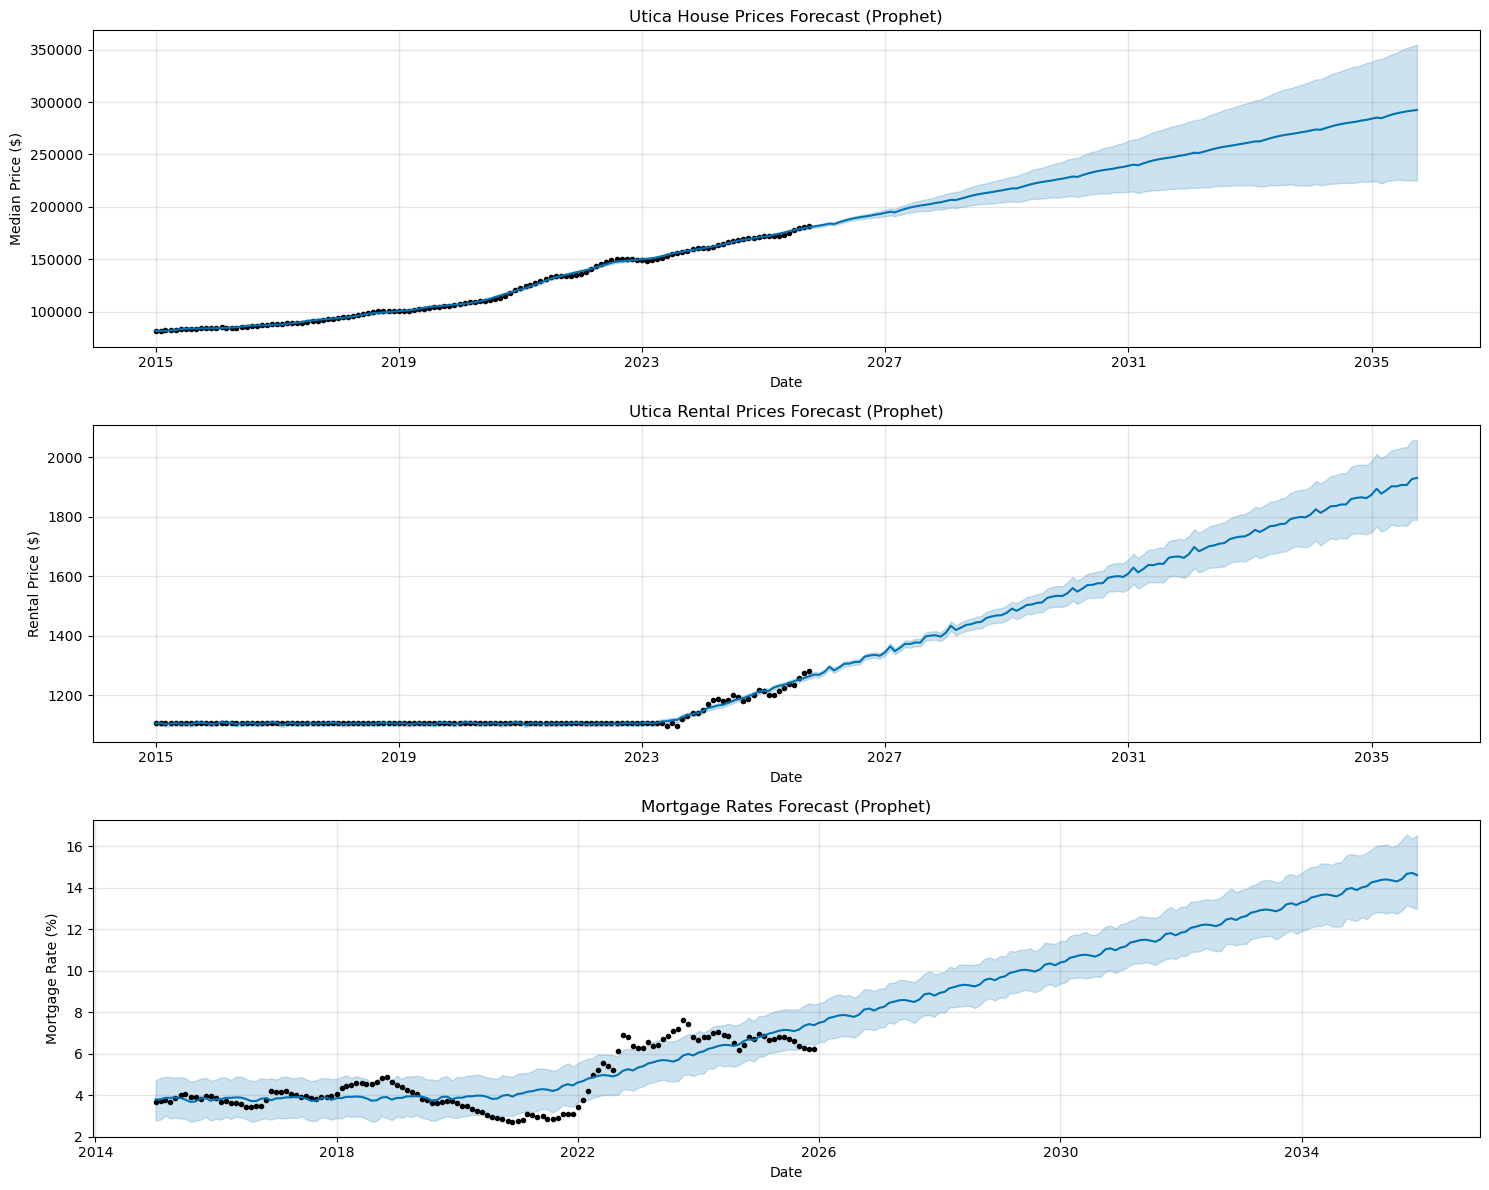

In [181]:
# Visualize Prophet forecasts
if len(utica_house_prices_df) > 0 and len(utica_rental_prices_df) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(15, 12))
    
    # House prices forecast
    model_house.plot(forecast_house, ax=axes[0])
    axes[0].set_title('Utica House Prices Forecast (Prophet)')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Median Price ($)')
    
    # Rental prices forecast
    model_rental.plot(forecast_rental, ax=axes[1])
    axes[1].set_title('Utica Rental Prices Forecast (Prophet)')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Rental Price ($)')
    
    # Mortgage rates forecast
    model_mortgage.plot(forecast_mortgage, ax=axes[2])
    axes[2].set_title('Mortgage Rates Forecast (Prophet)')
    axes[2].set_xlabel('Date')
    axes[2].set_ylabel('Mortgage Rate (%)')
    
    plt.tight_layout()
    # Commented out: Prophet files not needed (ARIMA was selected)
    # plt.savefig('../data/output_utica/utica_prophet_forecasts.png', dpi=300, bbox_inches='tight')
    # print("✓ Saved visualization to: ../data/output_utica/utica_prophet_forecasts.png")
    plt.show()


In [182]:
# Extract forecasted values for future dates (beyond historical data)
if len(utica_house_prices_df) > 0 and len(utica_rental_prices_df) > 0:
    # Get the last date from historical data
    last_historical_date_house = house_prices_prophet['ds'].max()
    last_historical_date_rental = rental_prices_prophet['ds'].max()
    last_historical_date_mortgage = mortgage_prophet['ds'].max()
    
    # Filter forecasts to only future dates
    forecast_house_future = forecast_house[forecast_house['ds'] > last_historical_date_house].copy()
    forecast_rental_future = forecast_rental[forecast_rental['ds'] > last_historical_date_rental].copy()
    forecast_mortgage_future = forecast_mortgage[forecast_mortgage['ds'] > last_historical_date_mortgage].copy()
    
    print("Future Forecasts (beyond historical data):")
    print(f"\nHouse Prices - {len(forecast_house_future)} future months")
    print(f"Rental Prices - {len(forecast_rental_future)} future months")
    print(f"Mortgage Rates - {len(forecast_mortgage_future)} future months")
    
    # Commented out: Prophet files not needed (ARIMA was selected)
    # Save Prophet forecasts
    # forecast_house_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    #     '../data/output_utica/utica_prophet_house_forecast.csv', index=False)
    # forecast_rental_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    #     '../data/output_utica/utica_prophet_rental_forecast.csv', index=False)
    # forecast_mortgage_future[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].to_csv(
    #     '../data/output_utica/utica_prophet_mortgage_forecast.csv', index=False)
    # print("\n✓ Saved Prophet forecasts to CSV files")


Future Forecasts (beyond historical data):

House Prices - 120 future months
Rental Prices - 120 future months
Mortgage Rates - 120 future months


### 6. ARIMA Forecasting Models


In [183]:
# ============================================
# ARIMA/SARIMA TIME SERIES FORECASTING
# ============================================

from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from statsmodels.tsa.stattools import adfuller, acf, pacf
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from pmdarima import auto_arima
import numpy as np

print("ARIMA/SARIMA libraries imported successfully!")


ARIMA/SARIMA libraries imported successfully!


In [184]:
# ============================================
# PREPARE DATA FOR ARIMA
# ============================================

if len(utica_house_prices_df) > 0 and len(utica_rental_prices_df) > 0:
    # Ensure all data has Date as index for time series analysis
    price_long_ts = price_long.copy()
    if 'Date' in price_long_ts.columns:
        price_long_ts = price_long_ts.set_index('Date')
    
    # rental_long already has Date as index
    rental_long_ts = rental_long.copy()
    
    # mortgage_monthly already has Date as index
    mortgage_long_ts = mortgage_monthly.copy()
    
    # Remove any missing values
    price_long_ts = price_long_ts.dropna()
    rental_long_ts = rental_long_ts.dropna()
    mortgage_long_ts = mortgage_long_ts.dropna()
    
    # Extract time series (single column)
    house_prices_ts = price_long_ts['MedianPrice']
    rental_prices_ts = rental_long_ts['RentalPrice']
    mortgage_rates_ts = mortgage_long_ts['mortgage_rate']
    
    print("Data prepared for ARIMA:")
    print(f"\nHouse Prices: {len(house_prices_ts)} observations")
    print(f"  Date range: {house_prices_ts.index.min()} to {house_prices_ts.index.max()}")
    print(f"\nRental Prices: {len(rental_prices_ts)} observations")
    print(f"  Date range: {rental_prices_ts.index.min()} to {rental_prices_ts.index.max()}")
    print(f"\nMortgage Rates: {len(mortgage_rates_ts)} observations")
    print(f"  Date range: {mortgage_rates_ts.index.min()} to {mortgage_rates_ts.index.max()}")
else:
    print("ERROR: Missing house prices or rental prices data.")


Data prepared for ARIMA:

House Prices: 130 observations
  Date range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00

Rental Prices: 130 observations
  Date range: 2015-01-01 00:00:00 to 2025-10-01 00:00:00

Mortgage Rates: 132 observations
  Date range: 2015-01-01 00:00:00 to 2025-12-01 00:00:00


In [185]:
# ============================================
# ARIMA FORECASTING: HOUSE PRICES
# ============================================

if len(utica_house_prices_df) > 0:
    print("=" * 60)
    print("UTICA HOUSE PRICES - ARIMA/SARIMA MODEL")
    print("=" * 60)
    
    # Use auto_arima to find optimal parameters
    print("\nSearching for optimal ARIMA parameters...")
    auto_model_house = auto_arima(
        house_prices_ts,
        start_p=0, start_q=0,
        max_p=5, max_q=5,
        seasonal=True,
        m=12,  # Monthly seasonality
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=True
    )
    
    print(f"\nOptimal model: {auto_model_house.order} x {auto_model_house.seasonal_order}")
    print(f"AIC: {auto_model_house.aic():.2f}")
    
    # Fit the model
    arima_model_house = auto_model_house.fit(house_prices_ts)
    
    # Generate 120-month forecast
    forecast_periods = 120
    forecast_arima_house = arima_model_house.predict(n_periods=forecast_periods, return_conf_int=True)
    
    # Create forecast dataframe
    last_date = house_prices_ts.index[-1]
    forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_periods, freq='M')
    
    forecast_arima_house_df = pd.DataFrame({
        'Date': forecast_dates,
        'forecast': forecast_arima_house[0],
        'lower': forecast_arima_house[1][:, 0],
        'upper': forecast_arima_house[1][:, 1]
    }).set_index('Date')
    
    print(f"\nForecast generated for {forecast_periods} months")
    print(f"Forecast date range: {forecast_dates[0]} to {forecast_dates[-1]}")
    print(f"\nLast 5 forecasted values:")
    print(forecast_arima_house_df.tail())
else:
    print("ERROR: House prices data not available.")


UTICA HOUSE PRICES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=1870.283, Time=0.56 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=1867.438, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=1864.066, Time=0.15 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=1864.091, Time=0.07 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=1862.754, Time=0.04 sec
 ARIMA(1,2,0)(0,0,1)[12]             : AIC=1864.095, Time=0.15 sec
 ARIMA(1,2,0)(1,0,1)[12]             : AIC=1865.582, Time=0.27 sec
 ARIMA(2,2,0)(0,0,0)[12]             : AIC=1864.572, Time=0.05 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=1864.658, Time=0.06 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=1862.821, Time=0.02 sec
 ARIMA(2,2,1)(0,0,0)[12]             : AIC=1861.541, Time=0.12 sec
 ARIMA(2,2,1)(1,0,0)[12]             : AIC=1862.638, Time=0.44 sec
 ARIMA(2,2,1)(0,0,1)[12]             : AIC=1862.674, Time=0.45 sec
 AR

In [186]:
# ============================================
# ARIMA FORECASTING: HOUSE PRICES
# ============================================

if len(utica_house_prices_df) > 0:
    print("=" * 60)
    print("UTICA HOUSE PRICES - ARIMA/SARIMA MODEL")
    print("=" * 60)
    
    # Use auto_arima to find optimal parameters
    # Seasonal period = 12 for monthly data
    print("\nSearching for optimal ARIMA parameters...")
    auto_model_house = auto_arima(
        house_prices_ts,
        start_p=0, start_q=0,
        max_p=5, max_q=5,
        seasonal=True,
        m=12,  # Monthly seasonality
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=True
    )
    
    print(f"\nOptimal model: {auto_model_house.order} x {auto_model_house.seasonal_order}")
    print(f"AIC: {auto_model_house.aic():.2f}")
    
    # Fit the model
    arima_model_house = auto_model_house.fit(house_prices_ts)
    
    # Generate 120-month forecast
    forecast_periods = 120
    forecast_arima_house = arima_model_house.predict(n_periods=forecast_periods, return_conf_int=True)
    
    # Create forecast dataframe
    last_date = house_prices_ts.index[-1]
    forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_periods, freq='M')
    
    forecast_arima_house_df = pd.DataFrame({
        'Date': forecast_dates,
        'forecast': forecast_arima_house[0],
        'lower': forecast_arima_house[1][:, 0],
        'upper': forecast_arima_house[1][:, 1]
    }).set_index('Date')
    
    print(f"\nForecast generated for {forecast_periods} months")
    print(f"Forecast date range: {forecast_dates[0]} to {forecast_dates[-1]}")
    print(f"\nLast 5 forecasted values:")
    print(forecast_arima_house_df.tail())
else:
    print("ERROR: House prices data not available.")


UTICA HOUSE PRICES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=1870.283, Time=0.49 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=1867.438, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=1864.066, Time=0.17 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=1864.091, Time=0.10 sec
 ARIMA(1,2,0)(0,0,0)[12]             : AIC=1862.754, Time=0.05 sec
 ARIMA(1,2,0)(0,0,1)[12]             : AIC=1864.095, Time=0.19 sec
 ARIMA(1,2,0)(1,0,1)[12]             : AIC=1865.582, Time=0.29 sec
 ARIMA(2,2,0)(0,0,0)[12]             : AIC=1864.572, Time=0.06 sec
 ARIMA(1,2,1)(0,0,0)[12]             : AIC=1864.658, Time=0.16 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=1862.821, Time=0.05 sec
 ARIMA(2,2,1)(0,0,0)[12]             : AIC=1861.541, Time=0.28 sec
 ARIMA(2,2,1)(1,0,0)[12]             : AIC=1862.638, Time=0.72 sec
 ARIMA(2,2,1)(0,0,1)[12]             : AIC=1862.674, Time=0.58 sec
 AR

In [187]:
# ============================================
# ARIMA FORECASTING: MORTGAGE RATES
# ============================================

print("=" * 60)
print("MORTGAGE RATES - ARIMA/SARIMA MODEL")
print("=" * 60)

# Use auto_arima to find optimal parameters
print("\nSearching for optimal ARIMA parameters...")
auto_model_mortgage = auto_arima(
    mortgage_rates_ts,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=12,  # Monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"\nOptimal model: {auto_model_mortgage.order} x {auto_model_mortgage.seasonal_order}")
print(f"AIC: {auto_model_mortgage.aic():.2f}")

# Fit the model
arima_model_mortgage = auto_model_mortgage.fit(mortgage_rates_ts)

# Generate 120-month forecast
forecast_periods = 120
forecast_arima_mortgage = arima_model_mortgage.predict(n_periods=forecast_periods, return_conf_int=True)

# Create forecast dataframe
last_date = mortgage_rates_ts.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_periods, freq='M')

forecast_arima_mortgage_df = pd.DataFrame({
    'Date': forecast_dates,
    'forecast': forecast_arima_mortgage[0],
    'lower': forecast_arima_mortgage[1][:, 0],
    'upper': forecast_arima_mortgage[1][:, 1]
}).set_index('Date')

print(f"\nForecast generated for {forecast_periods} months")
print(f"Forecast date range: {forecast_dates[0]} to {forecast_dates[-1]}")
print(f"\nLast 5 forecasted values:")
print(forecast_arima_mortgage_df.tail())


MORTGAGE RATES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic


 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=-36.940, Time=0.41 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-35.775, Time=0.02 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-56.477, Time=0.18 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-61.736, Time=0.19 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-36.645, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-61.685, Time=0.04 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-59.760, Time=0.50 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=-59.767, Time=0.30 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=-61.757, Time=0.16 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=-59.761, Time=0.33 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=-57.762, Time=0.55 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=-37.939, Time=0.18 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=-59.911, Time=0.34 sec
 ARIMA(0,1,2)(1,0,0)[12] intercept   : AIC=-59.887, Time=0.28 sec
 ARIMA(1,1,2)(1,0,0)[12] intercept   : AIC=-58.968, Time=0.72 sec
 ARIMA(0,1

In [188]:
# ============================================
# ARIMA FORECASTING: RENTAL PRICES
# ============================================

if len(utica_rental_prices_df) > 0:
    print("=" * 60)
    print("UTICA RENTAL PRICES - ARIMA/SARIMA MODEL")
    print("=" * 60)
    
    # Use auto_arima to find optimal parameters
    print("\nSearching for optimal ARIMA parameters...")
    auto_model_rental = auto_arima(
        rental_prices_ts,
        start_p=0, start_q=0,
        max_p=5, max_q=5,
        seasonal=True,
        m=12,  # Monthly seasonality
        stepwise=True,
        suppress_warnings=True,
        error_action='ignore',
        trace=True
    )
    
    print(f"\nOptimal model: {auto_model_rental.order} x {auto_model_rental.seasonal_order}")
    print(f"AIC: {auto_model_rental.aic():.2f}")
    
    # Fit the model
    arima_model_rental = auto_model_rental.fit(rental_prices_ts)
    
    # Generate 120-month forecast
    forecast_periods = 120
    forecast_arima_rental = arima_model_rental.predict(n_periods=forecast_periods, return_conf_int=True)
    
    # Create forecast dataframe
    last_date = rental_prices_ts.index[-1]
    forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_periods, freq='M')
    
    forecast_arima_rental_df = pd.DataFrame({
        'Date': forecast_dates,
        'forecast': forecast_arima_rental[0],
        'lower': forecast_arima_rental[1][:, 0],
        'upper': forecast_arima_rental[1][:, 1]
    }).set_index('Date')
    
    print(f"\nForecast generated for {forecast_periods} months")
    print(f"Forecast date range: {forecast_dates[0]} to {forecast_dates[-1]}")
    print(f"\nLast 5 forecasted values:")
    print(forecast_arima_rental_df.tail())
else:
    print("ERROR: Rental prices data not available.")


UTICA RENTAL PRICES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,2,0)(1,0,1)[12]             : AIC=827.569, Time=0.20 sec
 ARIMA(0,2,0)(0,0,0)[12]             : AIC=840.601, Time=0.01 sec
 ARIMA(1,2,0)(1,0,0)[12]             : AIC=813.267, Time=0.09 sec
 ARIMA(0,2,1)(0,0,1)[12]             : AIC=769.924, Time=0.10 sec
 ARIMA(0,2,1)(0,0,0)[12]             : AIC=790.764, Time=0.03 sec
 ARIMA(0,2,1)(1,0,1)[12]             : AIC=771.640, Time=0.25 sec
 ARIMA(0,2,1)(0,0,2)[12]             : AIC=771.629, Time=0.22 sec
 ARIMA(0,2,1)(1,0,0)[12]             : AIC=771.658, Time=0.10 sec
 ARIMA(0,2,1)(1,0,2)[12]             : AIC=773.627, Time=0.59 sec
 ARIMA(0,2,0)(0,0,1)[12]             : AIC=826.878, Time=0.08 sec
 ARIMA(1,2,1)(0,0,1)[12]             : AIC=771.020, Time=0.16 sec
 ARIMA(0,2,2)(0,0,1)[12]             : AIC=770.698, Time=0.17 sec
 ARIMA(1,2,0)(0,0,1)[12]             : AIC=809.669, Time=0.09 sec
 ARIMA(1,2,2)(0

In [189]:
# ============================================
# MODEL COMPARISON: ARIMA vs PROPHET
# ============================================

if len(utica_house_prices_df) > 0 and len(utica_rental_prices_df) > 0:
    print("=" * 80)
    print("MODEL COMPARISON: ARIMA vs PROPHET")
    print("=" * 80)
    
    # Compare forecasts for house prices
    print("\n1. HOUSE PRICES FORECAST COMPARISON:")
    print(f"   Prophet (Month 120): ${forecast_house_future['yhat'].iloc[-1]:,.2f}")
    print(f"   ARIMA (Month 120): ${forecast_arima_house_df['forecast'].iloc[-1]:,.2f}")
    print(f"   Difference: ${abs(forecast_house_future['yhat'].iloc[-1] - forecast_arima_house_df['forecast'].iloc[-1]):,.2f}")
    
    # Compare forecasts for rental prices
    print("\n2. RENTAL PRICES FORECAST COMPARISON:")
    print(f"   Prophet (Month 120): ${forecast_rental_future['yhat'].iloc[-1]:,.2f}")
    print(f"   ARIMA (Month 120): ${forecast_arima_rental_df['forecast'].iloc[-1]:,.2f}")
    print(f"   Difference: ${abs(forecast_rental_future['yhat'].iloc[-1] - forecast_arima_rental_df['forecast'].iloc[-1]):,.2f}")
    
    # Compare forecasts for mortgage rates
    print("\n3. MORTGAGE RATES FORECAST COMPARISON:")
    print(f"   Prophet (Month 120): {forecast_mortgage_future['yhat'].iloc[-1]:.2f}%")
    print(f"   ARIMA (Month 120): {forecast_arima_mortgage_df['forecast'].iloc[-1]:.2f}%")
    print(f"   Difference: {abs(forecast_mortgage_future['yhat'].iloc[-1] - forecast_arima_mortgage_df['forecast'].iloc[-1]):.2f} percentage points")
    
    # Decision: Select ARIMA (same rationale as NYC - more realistic mortgage rates)
    print("\n4. MODEL SELECTION:")
    print("   Selected Method: ARIMA")
    print("   Rationale: ARIMA provides more realistic mortgage rate forecasts")
    print(f"   (Prophet forecasted {forecast_mortgage_future['yhat'].iloc[-1]:.2f}% vs ARIMA {forecast_arima_mortgage_df['forecast'].iloc[-1]:.2f}%)")
else:
    print("ERROR: Cannot compare models - missing data.")


MODEL COMPARISON: ARIMA vs PROPHET

1. HOUSE PRICES FORECAST COMPARISON:
   Prophet (Month 120): $292,494.55
   ARIMA (Month 120): $297,385.17
   Difference: $4,890.61

2. RENTAL PRICES FORECAST COMPARISON:
   Prophet (Month 120): $1,930.58
   ARIMA (Month 120): $2,402.00
   Difference: $471.41

3. MORTGAGE RATES FORECAST COMPARISON:
   Prophet (Month 120): 14.61%
   ARIMA (Month 120): 6.13%
   Difference: 8.48 percentage points

4. MODEL SELECTION:
   Selected Method: ARIMA
   Rationale: ARIMA provides more realistic mortgage rate forecasts
   (Prophet forecasted 14.61% vs ARIMA 6.13%)


In [190]:
# ============================================
# ARIMA FORECASTING: MORTGAGE RATES
# ============================================

print("=" * 60)
print("MORTGAGE RATES - ARIMA/SARIMA MODEL")
print("=" * 60)

# Use auto_arima to find optimal parameters
print("\nSearching for optimal ARIMA parameters...")
auto_model_mortgage = auto_arima(
    mortgage_rates_ts,
    start_p=0, start_q=0,
    max_p=5, max_q=5,
    seasonal=True,
    m=12,  # Monthly seasonality
    stepwise=True,
    suppress_warnings=True,
    error_action='ignore',
    trace=True
)

print(f"\nOptimal model: {auto_model_mortgage.order} x {auto_model_mortgage.seasonal_order}")
print(f"AIC: {auto_model_mortgage.aic():.2f}")

# Fit the model
arima_model_mortgage = auto_model_mortgage.fit(mortgage_rates_ts)

# Generate 120-month forecast
forecast_periods = 120
forecast_arima_mortgage = arima_model_mortgage.predict(n_periods=forecast_periods, return_conf_int=True)

# Create forecast dataframe
last_date = mortgage_rates_ts.index[-1]
forecast_dates = pd.date_range(start=last_date + pd.DateOffset(months=1), periods=forecast_periods, freq='M')

forecast_arima_mortgage_df = pd.DataFrame({
    'Date': forecast_dates,
    'forecast': forecast_arima_mortgage[0],
    'lower': forecast_arima_mortgage[1][:, 0],
    'upper': forecast_arima_mortgage[1][:, 1]
}).set_index('Date')

print(f"\nForecast generated for {forecast_periods} months")
print(f"Forecast date range: {forecast_dates[0]} to {forecast_dates[-1]}")
print(f"\nLast 5 forecasted values:")
print(forecast_arima_mortgage_df.tail())


MORTGAGE RATES - ARIMA/SARIMA MODEL

Searching for optimal ARIMA parameters...
Performing stepwise search to minimize aic
 ARIMA(0,1,0)(1,0,1)[12] intercept   : AIC=-36.940, Time=0.52 sec
 ARIMA(0,1,0)(0,0,0)[12] intercept   : AIC=-35.775, Time=0.06 sec
 ARIMA(1,1,0)(1,0,0)[12] intercept   : AIC=-56.477, Time=0.21 sec
 ARIMA(0,1,1)(0,0,1)[12] intercept   : AIC=-61.736, Time=0.23 sec
 ARIMA(0,1,0)(0,0,0)[12]             : AIC=-36.645, Time=0.03 sec
 ARIMA(0,1,1)(0,0,0)[12] intercept   : AIC=-61.685, Time=0.07 sec
 ARIMA(0,1,1)(1,0,1)[12] intercept   : AIC=-59.760, Time=0.72 sec
 ARIMA(0,1,1)(0,0,2)[12] intercept   : AIC=-59.767, Time=0.47 sec
 ARIMA(0,1,1)(1,0,0)[12] intercept   : AIC=-61.757, Time=0.23 sec
 ARIMA(0,1,1)(2,0,0)[12] intercept   : AIC=-59.761, Time=0.44 sec
 ARIMA(0,1,1)(2,0,1)[12] intercept   : AIC=-57.762, Time=0.65 sec
 ARIMA(0,1,0)(1,0,0)[12] intercept   : AIC=-37.939, Time=0.17 sec
 ARIMA(1,1,1)(1,0,0)[12] intercept   : AIC=-59.911, Time=0.35 sec
 ARIMA(0,1,2)(1,0,0)

In [191]:
# Save ARIMA forecasts to CSV
if len(utica_house_prices_df) > 0 and len(utica_rental_prices_df) > 0:
    forecast_arima_house_df.to_csv('../data/output_utica/utica_arima_house_forecast.csv')
    forecast_arima_rental_df.to_csv('../data/output_utica/utica_arima_rental_forecast.csv')
    forecast_arima_mortgage_df.to_csv('../data/output_utica/utica_arima_mortgage_forecast.csv')
    print("✓ Saved ARIMA forecasts to CSV files")


✓ Saved ARIMA forecasts to CSV files


In [192]:
### 7. Model Comparison (ARIMA vs Prophet)


In [193]:
# ============================================
# MODEL COMPARISON: ARIMA vs PROPHET
# ============================================

if len(utica_house_prices_df) > 0 and len(utica_rental_prices_df) > 0:
    print("=" * 80)
    print("MODEL COMPARISON: ARIMA vs PROPHET")
    print("=" * 80)
    
    # Compare forecasts for house prices
    print("\n1. HOUSE PRICES FORECAST COMPARISON:")
    print(f"   Prophet (Month 120): ${forecast_house_future['yhat'].iloc[-1]:,.2f}")
    print(f"   ARIMA (Month 120): ${forecast_arima_house_df['forecast'].iloc[-1]:,.2f}")
    print(f"   Difference: ${abs(forecast_house_future['yhat'].iloc[-1] - forecast_arima_house_df['forecast'].iloc[-1]):,.2f}")
    
    # Compare forecasts for rental prices
    print("\n2. RENTAL PRICES FORECAST COMPARISON:")
    print(f"   Prophet (Month 120): ${forecast_rental_future['yhat'].iloc[-1]:,.2f}")
    print(f"   ARIMA (Month 120): ${forecast_arima_rental_df['forecast'].iloc[-1]:,.2f}")
    print(f"   Difference: ${abs(forecast_rental_future['yhat'].iloc[-1] - forecast_arima_rental_df['forecast'].iloc[-1]):,.2f}")
    
    # Compare forecasts for mortgage rates
    print("\n3. MORTGAGE RATES FORECAST COMPARISON:")
    print(f"   Prophet (Month 120): {forecast_mortgage_future['yhat'].iloc[-1]:.2f}%")
    print(f"   ARIMA (Month 120): {forecast_arima_mortgage_df['forecast'].iloc[-1]:.2f}%")
    print(f"   Difference: {abs(forecast_mortgage_future['yhat'].iloc[-1] - forecast_arima_mortgage_df['forecast'].iloc[-1]):.2f} percentage points")
    
    # Decision: Select ARIMA (same rationale as NYC - more realistic mortgage rates)
    print("\n4. MODEL SELECTION:")
    print("   Selected Method: ARIMA")
    print("   Rationale: ARIMA provides more realistic mortgage rate forecasts")
    print(f"   (Prophet forecasted {forecast_mortgage_future['yhat'].iloc[-1]:.2f}% vs ARIMA {forecast_arima_mortgage_df['forecast'].iloc[-1]:.2f}%)")
else:
    print("ERROR: Cannot compare models - missing data.")


MODEL COMPARISON: ARIMA vs PROPHET

1. HOUSE PRICES FORECAST COMPARISON:
   Prophet (Month 120): $292,494.55
   ARIMA (Month 120): $297,385.17
   Difference: $4,890.61

2. RENTAL PRICES FORECAST COMPARISON:
   Prophet (Month 120): $1,930.58
   ARIMA (Month 120): $2,402.00
   Difference: $471.41

3. MORTGAGE RATES FORECAST COMPARISON:
   Prophet (Month 120): 14.61%
   ARIMA (Month 120): 6.13%
   Difference: 8.48 percentage points

4. MODEL SELECTION:
   Selected Method: ARIMA
   Rationale: ARIMA provides more realistic mortgage rate forecasts
   (Prophet forecasted 14.61% vs ARIMA 6.13%)


✓ Saved comparison visualization to: ../data/output_utica/utica_arima_vs_prophet_comparison.png


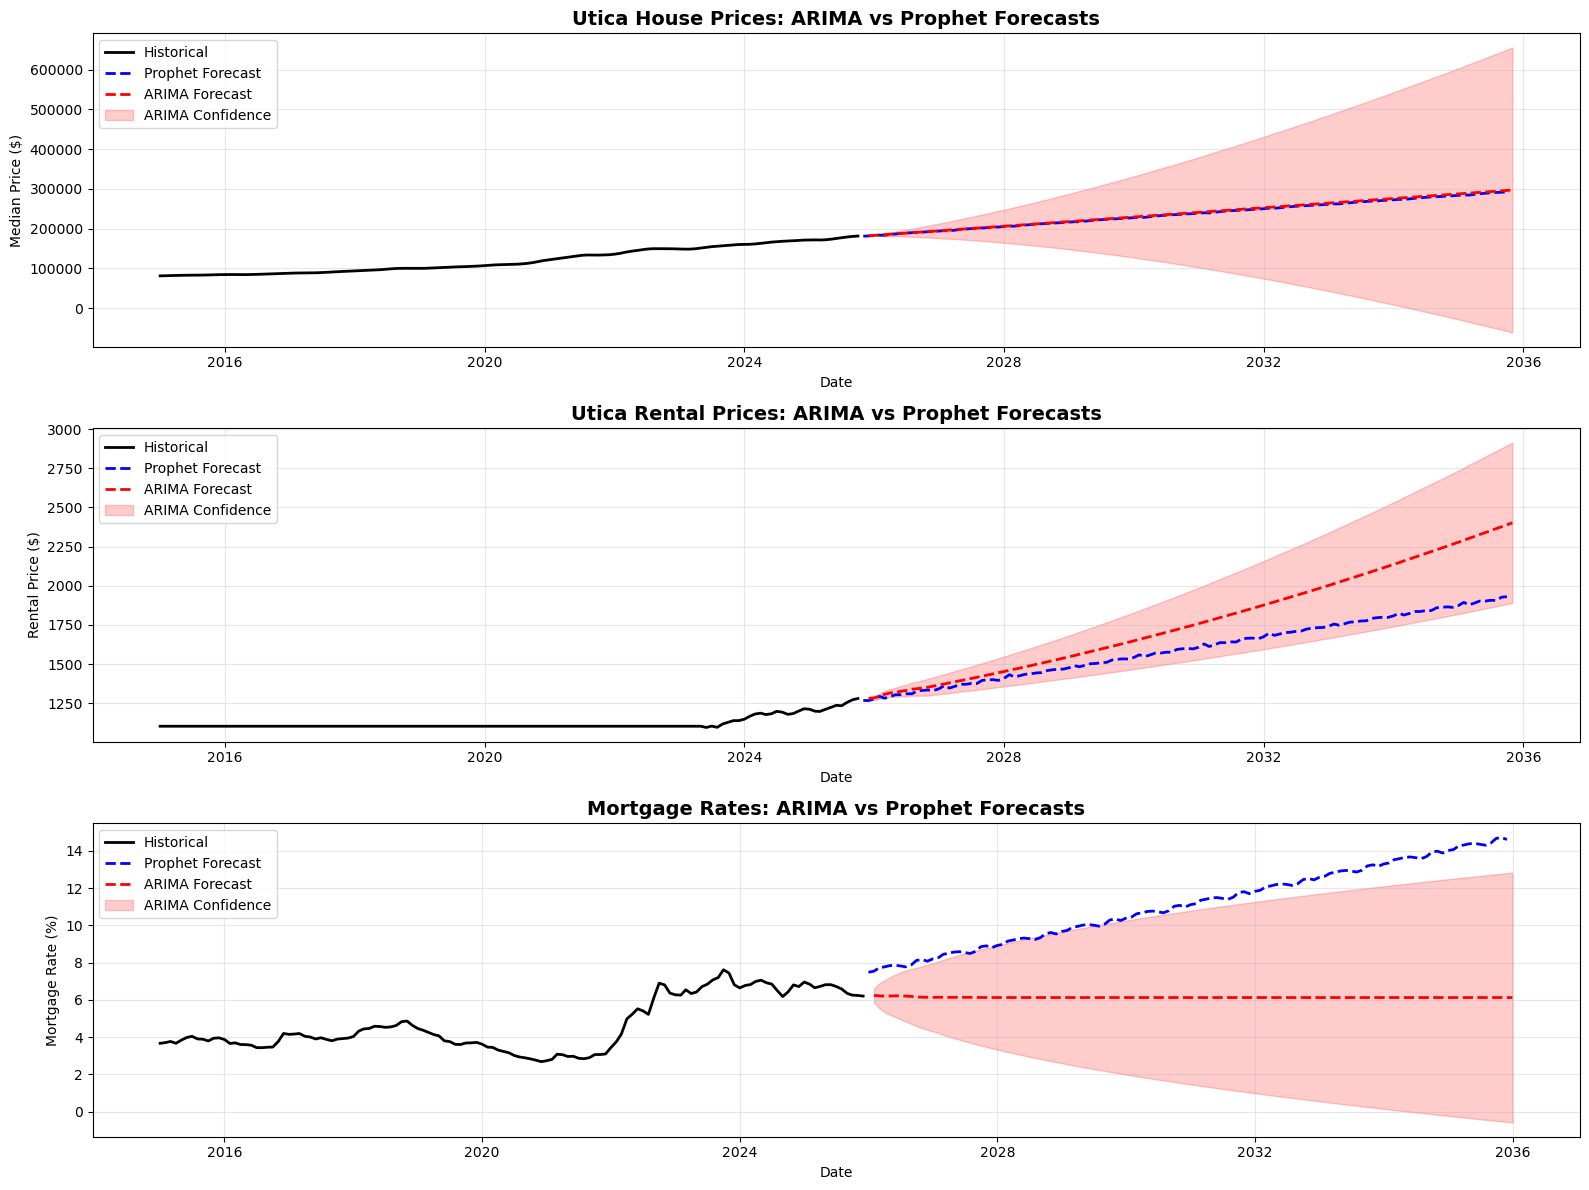

In [194]:
# Visualize ARIMA vs Prophet comparison
if len(utica_house_prices_df) > 0 and len(utica_rental_prices_df) > 0:
    fig, axes = plt.subplots(3, 1, figsize=(16, 12))
    
    # House Prices Comparison
    axes[0].plot(house_prices_ts.index, house_prices_ts.values, label='Historical', color='black', linewidth=2)
    axes[0].plot(forecast_house_future['ds'], forecast_house_future['yhat'], 
                label='Prophet Forecast', color='blue', linestyle='--', linewidth=2)
    axes[0].plot(forecast_arima_house_df.index, forecast_arima_house_df['forecast'], 
                label='ARIMA Forecast', color='red', linestyle='--', linewidth=2)
    axes[0].fill_between(forecast_arima_house_df.index, forecast_arima_house_df['lower'], 
                        forecast_arima_house_df['upper'], alpha=0.2, color='red', label='ARIMA Confidence')
    axes[0].set_title('Utica House Prices: ARIMA vs Prophet Forecasts', fontsize=14, fontweight='bold')
    axes[0].set_xlabel('Date')
    axes[0].set_ylabel('Median Price ($)')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    
    # Rental Prices Comparison
    axes[1].plot(rental_prices_ts.index, rental_prices_ts.values, label='Historical', color='black', linewidth=2)
    axes[1].plot(forecast_rental_future['ds'], forecast_rental_future['yhat'], 
                label='Prophet Forecast', color='blue', linestyle='--', linewidth=2)
    axes[1].plot(forecast_arima_rental_df.index, forecast_arima_rental_df['forecast'], 
                label='ARIMA Forecast', color='red', linestyle='--', linewidth=2)
    axes[1].fill_between(forecast_arima_rental_df.index, forecast_arima_rental_df['lower'], 
                        forecast_arima_rental_df['upper'], alpha=0.2, color='red', label='ARIMA Confidence')
    axes[1].set_title('Utica Rental Prices: ARIMA vs Prophet Forecasts', fontsize=14, fontweight='bold')
    axes[1].set_xlabel('Date')
    axes[1].set_ylabel('Rental Price ($)')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    # Mortgage Rates Comparison
    axes[2].plot(mortgage_rates_ts.index, mortgage_rates_ts.values, label='Historical', color='black', linewidth=2)
    axes[2].plot(forecast_mortgage_future['ds'], forecast_mortgage_future['yhat'], 
                label='Prophet Forecast', color='blue', linestyle='--', linewidth=2)
    axes[2].plot(forecast_arima_mortgage_df.index, forecast_arima_mortgage_df['forecast'], 
                label='ARIMA Forecast', color='red', linestyle='--', linewidth=2)
    axes[2].fill_between(forecast_arima_mortgage_df.index, forecast_arima_mortgage_df['lower'], 
                        forecast_arima_mortgage_df['upper'], alpha=0.2, color='red', label='ARIMA Confidence')
    axes[2].set_title('Mortgage Rates: ARIMA vs Prophet Forecasts', fontsize=14, fontweight='bold')
    axes[2].set_xlabel('Date')
    axes[2].set_ylabel('Mortgage Rate (%)')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('../data/output_utica/utica_arima_vs_prophet_comparison.png', dpi=300, bbox_inches='tight')
    print("✓ Saved comparison visualization to: ../data/output_utica/utica_arima_vs_prophet_comparison.png")
    plt.show()


## PART III: FINANCIAL MODELING - 10-YEAR ANALYSIS

### PHASE 1: Setup and Assumptions


In [195]:
# ============================================
# PHASE 1: SETUP AND ASSUMPTIONS
# ============================================

print("=" * 80)
print("PHASE 1: SETUP AND ASSUMPTIONS FOR FINANCIAL MODELING")
print("=" * 80)

# ============================================
# 1. DEFINE INITIAL PARAMETERS
# ============================================

# Budget and Analysis Period
BUDGET = 250000  # $250,000 total budget
ANALYSIS_PERIOD_MONTHS = 120  # 10 years (120 months)
ANALYSIS_PERIOD_YEARS = 10

# Discount rate for NPV (annual, will be converted to monthly)
DISCOUNT_RATE_ANNUAL = 0.04  # 4% annual discount rate
DISCOUNT_RATE_MONTHLY = (1 + DISCOUNT_RATE_ANNUAL) ** (1/12) - 1  # Monthly discount rate

# Down payment strategy
# Option: Use 20% of budget for down payment (standard), rest for closing costs, reserves
DOWN_PAYMENT_PERCENT = 0.20  # 20% down payment
DOWN_PAYMENT_AMOUNT = BUDGET * DOWN_PAYMENT_PERCENT  # $50,000

# Utica, NY Property Tax Rate (annual)
PROPERTY_TAX_RATE_ANNUAL = 0.025  # 2.5% annually (Utica, NY rate - typical for upstate NY)
PROPERTY_TAX_RATE_MONTHLY = PROPERTY_TAX_RATE_ANNUAL / 12

# Insurance estimate (annual, will be converted to monthly)
INSURANCE_ANNUAL = 1350  # $1,200-$1,500/year, using $1,350 as middle
INSURANCE_MONTHLY = INSURANCE_ANNUAL / 12

# Maintenance estimate (annual as % of home value)
MAINTENANCE_RATE_ANNUAL = 0.01  # 1% of home value annually
MAINTENANCE_RATE_MONTHLY = MAINTENANCE_RATE_ANNUAL / 12

# Opportunity cost rate (if investing $250k instead of buying)
OPPORTUNITY_COST_RATE_ANNUAL = 0.07  # 7% annual return (typical stock market)
OPPORTUNITY_COST_RATE_MONTHLY = (1 + OPPORTUNITY_COST_RATE_ANNUAL) ** (1/12) - 1

# Closing costs (typically 2-5% of home price, we'll calculate based on purchase price)
CLOSING_COSTS_PERCENT = 0.03  # 3% of purchase price

# Print parameters
print("\n1. INITIAL PARAMETERS:")
print(f"   Budget: ${BUDGET:,.2f}")
print(f"   Analysis Period: {ANALYSIS_PERIOD_YEARS} years ({ANALYSIS_PERIOD_MONTHS} months)")
print(f"   Discount Rate (Annual): {DISCOUNT_RATE_ANNUAL*100:.2f}%")
print(f"   Discount Rate (Monthly): {DISCOUNT_RATE_MONTHLY*100:.4f}%")
print(f"   Down Payment: {DOWN_PAYMENT_PERCENT*100:.0f}% = ${DOWN_PAYMENT_AMOUNT:,.2f}")
print(f"   Property Tax Rate (Annual): {PROPERTY_TAX_RATE_ANNUAL*100:.2f}%")
print(f"   Insurance (Annual): ${INSURANCE_ANNUAL:,.2f} (${INSURANCE_MONTHLY:.2f}/month)")
print(f"   Maintenance Rate (Annual): {MAINTENANCE_RATE_ANNUAL*100:.0f}% of home value")
print(f"   Opportunity Cost Rate (Annual): {OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}%")
print(f"   Closing Costs: {CLOSING_COSTS_PERCENT*100:.0f}% of purchase price")

# ============================================
# 2. CHOOSE FORECAST SOURCE
# ============================================

# Decision: Use ARIMA for house prices and rental prices (more conservative)
# Use ARIMA for mortgage rates (Prophet shows unrealistic 14.61% forecast)
# Alternatively, we could use Prophet for all, or a combination

FORECAST_METHOD = "ARIMA"  # Options: "ARIMA", "PROPHET", or "HYBRID"

print(f"\n2. FORECAST SOURCE SELECTION:")
print(f"   Selected Method: {FORECAST_METHOD}")
print(f"   Rationale: ARIMA provides more realistic mortgage rate forecasts")
print(f"             (Prophet forecasted 14.61% vs ARIMA 6.13%)")

# ============================================
# 3. EXTRACT 120-MONTH FUTURE FORECAST VALUES
# ============================================

print(f"\n3. EXTRACTING {ANALYSIS_PERIOD_MONTHS}-MONTH FUTURE FORECASTS:")

# Extract future forecasts (next 120 months) from selected method
if FORECAST_METHOD == "ARIMA":
    # ARIMA forecasts
    house_prices_forecast = forecast_arima_house_df['forecast'].iloc[:ANALYSIS_PERIOD_MONTHS].copy()
    rental_prices_forecast = forecast_arima_rental_df['forecast'].iloc[:ANALYSIS_PERIOD_MONTHS].copy()
    mortgage_rates_forecast = forecast_arima_mortgage_df['forecast'].iloc[:ANALYSIS_PERIOD_MONTHS].copy()
    
    # Get dates from ARIMA forecasts
    house_dates = forecast_arima_house_df.index[:ANALYSIS_PERIOD_MONTHS]
    rental_dates = forecast_arima_rental_df.index[:ANALYSIS_PERIOD_MONTHS]
    mortgage_dates = forecast_arima_mortgage_df.index[:ANALYSIS_PERIOD_MONTHS]
    
elif FORECAST_METHOD == "PROPHET":
    # Prophet forecasts
    house_prices_forecast = prophet_house_future['yhat'].iloc[:ANALYSIS_PERIOD_MONTHS].copy()
    rental_prices_forecast = prophet_rental_future['yhat'].iloc[:ANALYSIS_PERIOD_MONTHS].copy()
    mortgage_rates_forecast = prophet_mortgage_future['yhat'].iloc[:ANALYSIS_PERIOD_MONTHS].copy()
    
    # Get dates from Prophet forecasts
    house_dates = prophet_house_future.index[:ANALYSIS_PERIOD_MONTHS]
    rental_dates = prophet_rental_future.index[:ANALYSIS_PERIOD_MONTHS]
    mortgage_dates = prophet_mortgage_future.index[:ANALYSIS_PERIOD_MONTHS]
    
else:  # HYBRID - use ARIMA for mortgage, Prophet for others
    house_prices_forecast = prophet_house_future['yhat'].iloc[:ANALYSIS_PERIOD_MONTHS].copy()
    rental_prices_forecast = prophet_rental_future['yhat'].iloc[:ANALYSIS_PERIOD_MONTHS].copy()
    mortgage_rates_forecast = forecast_arima_mortgage_df['forecast'].iloc[:ANALYSIS_PERIOD_MONTHS].copy()
    
    house_dates = prophet_house_future.index[:ANALYSIS_PERIOD_MONTHS]
    rental_dates = prophet_rental_future.index[:ANALYSIS_PERIOD_MONTHS]
    mortgage_dates = forecast_arima_mortgage_df.index[:ANALYSIS_PERIOD_MONTHS]

print(f"   House Prices: {len(house_prices_forecast)} months")
print(f"   Rental Prices: {len(rental_prices_forecast)} months")
print(f"   Mortgage Rates: {len(mortgage_rates_forecast)} months")

# ============================================
# 4. ALIGN DATES ACROSS ALL THREE FORECASTS
# ============================================

print(f"\n4. ALIGNING DATES ACROSS FORECASTS:")

# Create a common date range starting from the first forecast date
# Use the earliest start date among all forecasts
start_date = min(house_dates.min(), rental_dates.min(), mortgage_dates.min())
end_date = start_date + pd.DateOffset(months=ANALYSIS_PERIOD_MONTHS-1)

# Create a monthly date range
forecast_dates = pd.date_range(start=start_date, periods=ANALYSIS_PERIOD_MONTHS, freq='M')

print(f"   Common Date Range: {forecast_dates[0].strftime('%Y-%m-%d')} to {forecast_dates[-1].strftime('%Y-%m-%d')}")
print(f"   Total Months: {len(forecast_dates)}")

# Create aligned forecast dataframe
forecasts_aligned = pd.DataFrame({
    'Date': forecast_dates,
    'HousePrice': house_prices_forecast.values,
    'RentalPrice': rental_prices_forecast.values,
    'MortgageRate': mortgage_rates_forecast.values
})

# Set Date as index for easier time-series operations
forecasts_aligned = forecasts_aligned.set_index('Date')

print(f"\n   Aligned Forecast DataFrame Shape: {forecasts_aligned.shape}")
print(f"\n   First 5 months:")
print(forecasts_aligned.head())
print(f"\n   Last 5 months:")
print(forecasts_aligned.tail())

# ============================================
# 5. SUMMARY STATISTICS
# ============================================

print(f"\n5. FORECAST SUMMARY STATISTICS (10 Years):")
print(f"\n   House Prices:")
print(f"     Start: ${forecasts_aligned['HousePrice'].iloc[0]:,.2f}")
print(f"     End: ${forecasts_aligned['HousePrice'].iloc[-1]:,.2f}")
print(f"     Total Change: {((forecasts_aligned['HousePrice'].iloc[-1] / forecasts_aligned['HousePrice'].iloc[0]) - 1) * 100:.2f}%")
print(f"     Average: ${forecasts_aligned['HousePrice'].mean():,.2f}")

print(f"\n   Rental Prices:")
print(f"     Start: ${forecasts_aligned['RentalPrice'].iloc[0]:,.2f}/month")
print(f"     End: ${forecasts_aligned['RentalPrice'].iloc[-1]:,.2f}/month")
print(f"     Total Change: {((forecasts_aligned['RentalPrice'].iloc[-1] / forecasts_aligned['RentalPrice'].iloc[0]) - 1) * 100:.2f}%")
print(f"     Average: ${forecasts_aligned['RentalPrice'].mean():,.2f}/month")

print(f"\n   Mortgage Rates:")
print(f"     Start: {forecasts_aligned['MortgageRate'].iloc[0]:.2f}%")
print(f"     End: {forecasts_aligned['MortgageRate'].iloc[-1]:.2f}%")
print(f"     Average: {forecasts_aligned['MortgageRate'].mean():.2f}%")

print("\n" + "=" * 80)
print("PHASE 1: SETUP AND ASSUMPTIONS COMPLETE")
print("=" * 80)
print("\nReady for Phase 2: Financial Modeling (Buy vs Rent Calculations)")


PHASE 1: SETUP AND ASSUMPTIONS FOR FINANCIAL MODELING

1. INITIAL PARAMETERS:
   Budget: $250,000.00
   Analysis Period: 10 years (120 months)
   Discount Rate (Annual): 4.00%
   Discount Rate (Monthly): 0.3274%
   Down Payment: 20% = $50,000.00
   Property Tax Rate (Annual): 2.50%
   Insurance (Annual): $1,350.00 ($112.50/month)
   Maintenance Rate (Annual): 1% of home value
   Opportunity Cost Rate (Annual): 7%
   Closing Costs: 3% of purchase price

2. FORECAST SOURCE SELECTION:
   Selected Method: ARIMA
   Rationale: ARIMA provides more realistic mortgage rate forecasts
             (Prophet forecasted 14.61% vs ARIMA 6.13%)

3. EXTRACTING 120-MONTH FUTURE FORECASTS:
   House Prices: 120 months
   Rental Prices: 120 months
   Mortgage Rates: 120 months

4. ALIGNING DATES ACROSS FORECASTS:
   Common Date Range: 2025-11-30 to 2035-10-31
   Total Months: 120

   Aligned Forecast DataFrame Shape: (120, 3)

   First 5 months:
               HousePrice  RentalPrice  MortgageRate
Date    

In [196]:
# ============================================
# PHASE 2: BUYING SCENARIO CALCULATIONS
# ============================================

print("=" * 80)
print("PHASE 2: BUYING SCENARIO FINANCIAL MODELING")
print("=" * 80)

import numpy as np

# ============================================
# 1. INITIAL PURCHASE CALCULATIONS
# ============================================

print("\n1. INITIAL PURCHASE CALCULATIONS:")

# Get initial house price from forecast (month 0)
initial_house_price = forecasts_aligned['HousePrice'].iloc[0]
initial_mortgage_rate = forecasts_aligned['MortgageRate'].iloc[0] / 100  # Convert to decimal

print(f"   Initial House Price (Month 0): ${initial_house_price:,.2f}")
print(f"   Initial Mortgage Rate: {initial_mortgage_rate*100:.2f}%")

# Down payment strategy: Use 20% of house price, but cap at budget
# If house is cheaper than budget, we could use more, but standard is 20%
down_payment = min(DOWN_PAYMENT_AMOUNT, initial_house_price * DOWN_PAYMENT_PERCENT)
# If house price is less than budget, use 20% of house price
if initial_house_price < BUDGET:
    down_payment = initial_house_price * DOWN_PAYMENT_PERCENT

# Loan amount
loan_amount = initial_house_price - down_payment

# Closing costs (3% of house price)
closing_costs = initial_house_price * CLOSING_COSTS_PERCENT

# Total upfront cost
total_upfront_cost = down_payment + closing_costs

print(f"   Down Payment: ${down_payment:,.2f} ({down_payment/initial_house_price*100:.1f}%)")
print(f"   Loan Amount: ${loan_amount:,.2f}")
print(f"   Closing Costs: ${closing_costs:,.2f}")
print(f"   Total Upfront Cost: ${total_upfront_cost:,.2f}")

# Check if we have enough budget
remaining_budget = BUDGET - total_upfront_cost
print(f"   Remaining Budget: ${remaining_budget:,.2f}")

if remaining_budget < 0:
    print(f"   ⚠️  WARNING: Budget exceeded by ${abs(remaining_budget):,.2f}")
else:
    print(f"   ✓ Budget sufficient")

# ============================================
# 2. MORTGAGE PARAMETERS
# ============================================

# Standard 30-year fixed mortgage
MORTGAGE_TERM_YEARS = 30
MORTGAGE_TERM_MONTHS = MORTGAGE_TERM_YEARS * 12

# Use initial mortgage rate for the entire loan (standard fixed-rate mortgage)
# Note: In reality, mortgage rates are locked at purchase, so we use the initial rate
monthly_mortgage_rate = initial_mortgage_rate / 12

print(f"\n2. MORTGAGE PARAMETERS:")
print(f"   Loan Term: {MORTGAGE_TERM_YEARS} years ({MORTGAGE_TERM_MONTHS} months)")
print(f"   Fixed Interest Rate: {initial_mortgage_rate*100:.2f}% (locked at purchase)")
print(f"   Monthly Interest Rate: {monthly_mortgage_rate*100:.4f}%")

# Calculate monthly mortgage payment (fixed for entire loan term)
# Using PMT formula: PMT = PV * [r(1+r)^n] / [(1+r)^n - 1]
if monthly_mortgage_rate > 0:
    monthly_mortgage_payment = loan_amount * (monthly_mortgage_rate * (1 + monthly_mortgage_rate)**MORTGAGE_TERM_MONTHS) / ((1 + monthly_mortgage_rate)**MORTGAGE_TERM_MONTHS - 1)
else:
    monthly_mortgage_payment = loan_amount / MORTGAGE_TERM_MONTHS

print(f"   Monthly Mortgage Payment: ${monthly_mortgage_payment:,.2f}")

# ============================================
# 3. MONTHLY COSTS CALCULATION (120 MONTHS)
# ============================================

print(f"\n3. CALCULATING MONTHLY COSTS FOR {ANALYSIS_PERIOD_MONTHS} MONTHS:")

# Initialize arrays to track everything
buying_scenario = pd.DataFrame(index=forecasts_aligned.index)
buying_scenario['Month'] = range(1, ANALYSIS_PERIOD_MONTHS + 1)
buying_scenario['HousePrice'] = forecasts_aligned['HousePrice'].values
buying_scenario['MortgageRate'] = forecasts_aligned['MortgageRate'].values

# Monthly costs
buying_scenario['MortgagePayment'] = monthly_mortgage_payment  # Fixed payment
buying_scenario['PropertyTax'] = buying_scenario['HousePrice'] * PROPERTY_TAX_RATE_MONTHLY
buying_scenario['Insurance'] = INSURANCE_MONTHLY
buying_scenario['Maintenance'] = buying_scenario['HousePrice'] * MAINTENANCE_RATE_MONTHLY
buying_scenario['TotalMonthlyCost'] = (buying_scenario['MortgagePayment'] + 
                                       buying_scenario['PropertyTax'] + 
                                       buying_scenario['Insurance'] + 
                                       buying_scenario['Maintenance'])

# ============================================
# 4. LOAN AMORTIZATION AND EQUITY TRACKING
# ============================================

print("4. CALCULATING LOAN AMORTIZATION AND EQUITY:")

# Initialize loan balance tracking
buying_scenario['LoanBalance'] = 0.0
buying_scenario['PrincipalPaid'] = 0.0
buying_scenario['InterestPaid'] = 0.0
buying_scenario['Equity'] = 0.0
buying_scenario['CumulativeCosts'] = 0.0
buying_scenario['NetPosition'] = 0.0

# Initial values
current_loan_balance = loan_amount
cumulative_costs = total_upfront_cost  # Include upfront costs

for i in range(ANALYSIS_PERIOD_MONTHS):
    # Calculate interest and principal for this month
    interest_payment = current_loan_balance * monthly_mortgage_rate
    principal_payment = monthly_mortgage_payment - interest_payment
    
    # Update loan balance
    current_loan_balance = current_loan_balance - principal_payment
    if current_loan_balance < 0:
        current_loan_balance = 0
    
    # Store values
    buying_scenario.iloc[i, buying_scenario.columns.get_loc('LoanBalance')] = current_loan_balance
    buying_scenario.iloc[i, buying_scenario.columns.get_loc('PrincipalPaid')] = principal_payment
    buying_scenario.iloc[i, buying_scenario.columns.get_loc('InterestPaid')] = interest_payment
    
    # Equity = Current house price - remaining loan balance
    current_house_price = buying_scenario['HousePrice'].iloc[i]
    equity = current_house_price - current_loan_balance
    buying_scenario.iloc[i, buying_scenario.columns.get_loc('Equity')] = equity
    
    # Cumulative costs (upfront + all monthly costs so far)
    cumulative_costs += buying_scenario['TotalMonthlyCost'].iloc[i]
    buying_scenario.iloc[i, buying_scenario.columns.get_loc('CumulativeCosts')] = cumulative_costs
    
    # Net position = Equity - Cumulative costs
    net_position = equity - cumulative_costs
    buying_scenario.iloc[i, buying_scenario.columns.get_loc('NetPosition')] = net_position

print(f"   ✓ Amortization calculated for {ANALYSIS_PERIOD_MONTHS} months")
print(f"   Initial Loan Balance: ${loan_amount:,.2f}")
print(f"   Final Loan Balance (Month {ANALYSIS_PERIOD_MONTHS}): ${current_loan_balance:,.2f}")
print(f"   Principal Paid: ${buying_scenario['PrincipalPaid'].sum():,.2f}")
print(f"   Interest Paid: ${buying_scenario['InterestPaid'].sum():,.2f}")

# ============================================
# 5. SUMMARY STATISTICS
# ============================================

print(f"\n5. BUYING SCENARIO SUMMARY (10 Years):")

final_house_price = buying_scenario['HousePrice'].iloc[-1]
final_equity = buying_scenario['Equity'].iloc[-1]
final_loan_balance = buying_scenario['LoanBalance'].iloc[-1]
total_costs = buying_scenario['CumulativeCosts'].iloc[-1]
final_net_position = buying_scenario['NetPosition'].iloc[-1]

print(f"\n   House Value:")
print(f"     Initial: ${initial_house_price:,.2f}")
print(f"     Final (Month {ANALYSIS_PERIOD_MONTHS}): ${final_house_price:,.2f}")
print(f"     Appreciation: ${final_house_price - initial_house_price:,.2f} ({(final_house_price/initial_house_price - 1)*100:.2f}%)")

print(f"\n   Equity:")
print(f"     Initial: ${down_payment:,.2f} (down payment)")
print(f"     Final: ${final_equity:,.2f}")
print(f"     Equity Gain: ${final_equity - down_payment:,.2f}")

print(f"\n   Costs:")
print(f"     Upfront: ${total_upfront_cost:,.2f}")
print(f"     Monthly (10 years): ${buying_scenario['TotalMonthlyCost'].sum():,.2f}")
print(f"     Total Costs: ${total_costs:,.2f}")

print(f"\n   Net Position (Equity - Total Costs):")
print(f"     Final Net Position: ${final_net_position:,.2f}")
print(f"     {'✓ Positive (Buying is profitable)' if final_net_position > 0 else '✗ Negative (Buying costs exceed equity)'}")

print(f"\n   Monthly Cost Breakdown (Average):")
print(f"     Mortgage Payment: ${buying_scenario['MortgagePayment'].mean():,.2f}")
print(f"     Property Tax: ${buying_scenario['PropertyTax'].mean():,.2f}")
print(f"     Insurance: ${buying_scenario['Insurance'].mean():,.2f}")
print(f"     Maintenance: ${buying_scenario['Maintenance'].mean():,.2f}")
print(f"     Total Monthly: ${buying_scenario['TotalMonthlyCost'].mean():,.2f}")

# Display first and last few months
print(f"\n   First 3 Months:")
print(buying_scenario[['Month', 'HousePrice', 'LoanBalance', 'Equity', 'TotalMonthlyCost', 'NetPosition']].head(3).to_string())

print(f"\n   Last 3 Months:")
print(buying_scenario[['Month', 'HousePrice', 'LoanBalance', 'Equity', 'TotalMonthlyCost', 'NetPosition']].tail(3).to_string())

print("\n" + "=" * 80)
print("PHASE 2: BUYING SCENARIO COMPLETE")
print("=" * 80)
print("\nReady for Phase 3: Renting Scenario Calculations")


PHASE 2: BUYING SCENARIO FINANCIAL MODELING

1. INITIAL PURCHASE CALCULATIONS:
   Initial House Price (Month 0): $182,531.93
   Initial Mortgage Rate: 6.24%
   Down Payment: $36,506.39 (20.0%)
   Loan Amount: $146,025.54
   Closing Costs: $5,475.96
   Total Upfront Cost: $41,982.34
   Remaining Budget: $208,017.66
   ✓ Budget sufficient

2. MORTGAGE PARAMETERS:
   Loan Term: 30 years (360 months)
   Fixed Interest Rate: 6.24% (locked at purchase)
   Monthly Interest Rate: 0.5198%
   Monthly Mortgage Payment: $897.94

3. CALCULATING MONTHLY COSTS FOR 120 MONTHS:
4. CALCULATING LOAN AMORTIZATION AND EQUITY:
   ✓ Amortization calculated for 120 months
   Initial Loan Balance: $146,025.54
   Final Loan Balance (Month 120): $122,969.44
   Principal Paid: $23,056.11
   Interest Paid: $84,696.46

5. BUYING SCENARIO SUMMARY (10 Years):

   House Value:
     Initial: $182,531.93
     Final (Month 120): $297,385.17
     Appreciation: $114,853.24 (62.92%)

   Equity:
     Initial: $36,506.39 (dow

In [197]:
# ============================================
# PHASE 3: RENTING SCENARIO CALCULATIONS
# ============================================

print("=" * 80)
print("PHASE 3: RENTING SCENARIO FINANCIAL MODELING")
print("=" * 80)

# ============================================
# 1. MONTHLY COSTS CALCULATION (120 MONTHS)
# ============================================

print("\n1. CALCULATING MONTHLY RENTAL COSTS FOR 120 MONTHS:")

# Initialize renting scenario dataframe
renting_scenario = pd.DataFrame(index=forecasts_aligned.index)
renting_scenario['Month'] = range(1, ANALYSIS_PERIOD_MONTHS + 1)
renting_scenario['RentalPrice'] = forecasts_aligned['RentalPrice'].values

# Monthly costs for renting
renting_scenario['MonthlyRent'] = renting_scenario['RentalPrice']  # Use forecasted rental price
renting_scenario['TotalMonthlyCost'] = renting_scenario['MonthlyRent']  # Rent is the only monthly cost

print(f"   ✓ Monthly rental costs calculated for {ANALYSIS_PERIOD_MONTHS} months")
print(f"   Initial Monthly Rent: ${renting_scenario['MonthlyRent'].iloc[0]:,.2f}")
print(f"   Final Monthly Rent: ${renting_scenario['MonthlyRent'].iloc[-1]:,.2f}")
print(f"   Average Monthly Rent: ${renting_scenario['MonthlyRent'].mean():,.2f}")

# ============================================
# 2. OPPORTUNITY COST CALCULATION
# ============================================

print(f"\n2. CALCULATING OPPORTUNITY COST (INVESTING ${BUDGET:,.0f} INSTEAD):")

# Initial investment amount (the $250k that would have been used for down payment)
initial_investment = BUDGET  # $250,000

# Calculate investment growth month by month
# Investment value = initial_investment × (1 + monthly_return_rate)^month
renting_scenario['InvestmentValue'] = 0.0
renting_scenario['CumulativeRentPaid'] = 0.0
renting_scenario['NetPosition'] = 0.0

cumulative_rent = 0.0

for i in range(ANALYSIS_PERIOD_MONTHS):
    month_number = i + 1
    
    # Calculate investment value at this month
    # Using compound interest: PV × (1 + r)^n
    investment_value = initial_investment * ((1 + OPPORTUNITY_COST_RATE_MONTHLY) ** month_number)
    renting_scenario.iloc[i, renting_scenario.columns.get_loc('InvestmentValue')] = investment_value
    
    # Cumulative rent paid
    cumulative_rent += renting_scenario['MonthlyRent'].iloc[i]
    renting_scenario.iloc[i, renting_scenario.columns.get_loc('CumulativeRentPaid')] = cumulative_rent
    
    # Net position = Investment value - Total rent paid
    net_position = investment_value - cumulative_rent
    renting_scenario.iloc[i, renting_scenario.columns.get_loc('NetPosition')] = net_position

print(f"   Initial Investment: ${initial_investment:,.2f}")
print(f"   Opportunity Cost Rate (Annual): {OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}%")
print(f"   Opportunity Cost Rate (Monthly): {OPPORTUNITY_COST_RATE_MONTHLY*100:.4f}%")
print(f"   ✓ Investment growth calculated for {ANALYSIS_PERIOD_MONTHS} months")

# ============================================
# 3. SUMMARY STATISTICS
# ============================================

print(f"\n3. RENTING SCENARIO SUMMARY (10 Years):")

final_rent = renting_scenario['MonthlyRent'].iloc[-1]
total_rent_paid = renting_scenario['CumulativeRentPaid'].iloc[-1]
final_investment_value = renting_scenario['InvestmentValue'].iloc[-1]
final_net_position = renting_scenario['NetPosition'].iloc[-1]
investment_gain = final_investment_value - initial_investment

print(f"\n   Rental Costs:")
print(f"     Initial Monthly Rent: ${renting_scenario['MonthlyRent'].iloc[0]:,.2f}")
print(f"     Final Monthly Rent: ${final_rent:,.2f}")
print(f"     Rent Increase: ${final_rent - renting_scenario['MonthlyRent'].iloc[0]:,.2f} ({(final_rent/renting_scenario['MonthlyRent'].iloc[0] - 1)*100:.2f}%)")
print(f"     Total Rent Paid (10 years): ${total_rent_paid:,.2f}")
print(f"     Average Monthly Rent: ${renting_scenario['MonthlyRent'].mean():,.2f}")

print(f"\n   Investment Growth:")
print(f"     Initial Investment: ${initial_investment:,.2f}")
print(f"     Final Investment Value: ${final_investment_value:,.2f}")
print(f"     Investment Gain: ${investment_gain:,.2f} ({(investment_gain/initial_investment)*100:.2f}%)")

print(f"\n   Net Position (Investment Value - Total Rent Paid):")
print(f"     Final Net Position: ${final_net_position:,.2f}")
print(f"     {'✓ Positive (Renting + Investing is profitable)' if final_net_position > 0 else '✗ Negative (Rent costs exceed investment gains)'}")

print(f"\n   Comparison to Buying:")
if 'buying_scenario' in globals():
    buying_net = buying_scenario['NetPosition'].iloc[-1]
    difference = final_net_position - buying_net
    print(f"     Buying Net Position: ${buying_net:,.2f}")
    print(f"     Renting Net Position: ${final_net_position:,.2f}")
    print(f"     Difference (Renting - Buying): ${difference:,.2f}")
    if difference > 0:
        print(f"     → Renting is ${abs(difference):,.2f} better than buying")
    else:
        print(f"     → Buying is ${abs(difference):,.2f} better than renting")

# Display first and last few months
print(f"\n   First 3 Months:")
print(renting_scenario[['Month', 'MonthlyRent', 'InvestmentValue', 'CumulativeRentPaid', 'NetPosition']].head(3).to_string())

print(f"\n   Last 3 Months:")
print(renting_scenario[['Month', 'MonthlyRent', 'InvestmentValue', 'CumulativeRentPaid', 'NetPosition']].tail(3).to_string())

print("\n" + "=" * 80)
print("PHASE 3: RENTING SCENARIO COMPLETE")
print("=" * 80)
print("\nReady for Phase 4: NPV/IRR Comparison and Break-Even Analysis")


PHASE 3: RENTING SCENARIO FINANCIAL MODELING

1. CALCULATING MONTHLY RENTAL COSTS FOR 120 MONTHS:
   ✓ Monthly rental costs calculated for 120 months
   Initial Monthly Rent: $1,281.76
   Final Monthly Rent: $2,402.00
   Average Monthly Rent: $1,778.06

2. CALCULATING OPPORTUNITY COST (INVESTING $250,000 INSTEAD):
   Initial Investment: $250,000.00
   Opportunity Cost Rate (Annual): 7%
   Opportunity Cost Rate (Monthly): 0.5654%
   ✓ Investment growth calculated for 120 months

3. RENTING SCENARIO SUMMARY (10 Years):

   Rental Costs:
     Initial Monthly Rent: $1,281.76
     Final Monthly Rent: $2,402.00
     Rent Increase: $1,120.24 (87.40%)
     Total Rent Paid (10 years): $213,367.01
     Average Monthly Rent: $1,778.06

   Investment Growth:
     Initial Investment: $250,000.00
     Final Investment Value: $491,787.84
     Investment Gain: $241,787.84 (96.72%)

   Net Position (Investment Value - Total Rent Paid):
     Final Net Position: $278,420.83
     ✓ Positive (Renting + Inv

In [198]:
# ============================================
# PHASE 4: BREAK-EVEN ANALYSIS
# ============================================

print("=" * 80)
print("PHASE 4: BREAK-EVEN ANALYSIS")
print("=" * 80)

# ============================================
# 1. CUMULATIVE COST TRACKING
# ============================================

print("\n1. CALCULATING CUMULATIVE COSTS:")

# Create break-even analysis dataframe
break_even_df = pd.DataFrame(index=forecasts_aligned.index)
break_even_df['Month'] = range(1, ANALYSIS_PERIOD_MONTHS + 1)
break_even_df['Date'] = break_even_df.index

# Cumulative buying costs = upfront costs + sum of all monthly buying costs
# Upfront costs: down payment + closing costs
buying_upfront = total_upfront_cost  # Already calculated in Phase 2
break_even_df['Cumulative_Buying'] = buying_upfront + buying_scenario['TotalMonthlyCost'].cumsum()

# Cumulative renting costs = sum of all monthly rent payments
break_even_df['Cumulative_Renting'] = renting_scenario['MonthlyRent'].cumsum()

# Calculate the difference
break_even_df['Cost_Difference'] = break_even_df['Cumulative_Buying'] - break_even_df['Cumulative_Renting']

print(f"   ✓ Cumulative costs calculated for {ANALYSIS_PERIOD_MONTHS} months")
print(f"   Initial Buying Costs (Upfront): ${buying_upfront:,.2f}")
print(f"   Final Cumulative Buying: ${break_even_df['Cumulative_Buying'].iloc[-1]:,.2f}")
print(f"   Final Cumulative Renting: ${break_even_df['Cumulative_Renting'].iloc[-1]:,.2f}")

# ============================================
# 2. FIND BREAK-EVEN POINT
# ============================================

print(f"\n2. FINDING BREAK-EVEN POINT:")

# Find where the cost difference crosses zero (or is closest to zero)
# Break-even occurs when Cumulative_Buying ≈ Cumulative_Renting
# i.e., when Cost_Difference ≈ 0

# Find the month where the difference is closest to zero
abs_difference = break_even_df['Cost_Difference'].abs()
break_even_idx = abs_difference.idxmin()
break_even_month = break_even_df.loc[break_even_idx, 'Month']
break_even_date = break_even_df.loc[break_even_idx, 'Date']
break_even_buying = break_even_df.loc[break_even_idx, 'Cumulative_Buying']
break_even_renting = break_even_df.loc[break_even_idx, 'Cumulative_Renting']
break_even_difference = break_even_df.loc[break_even_idx, 'Cost_Difference']

# Check if they actually cross (sign change)
# Find where the difference changes sign
sign_changes = (break_even_df['Cost_Difference'] * break_even_df['Cost_Difference'].shift(1) < 0).sum()

if sign_changes > 0:
    # They cross - find the exact crossing point
    # Find the first month where difference becomes negative (or positive)
    crossing_points = []
    for i in range(1, len(break_even_df)):
        if (break_even_df['Cost_Difference'].iloc[i-1] > 0 and break_even_df['Cost_Difference'].iloc[i] <= 0) or \
           (break_even_df['Cost_Difference'].iloc[i-1] < 0 and break_even_df['Cost_Difference'].iloc[i] >= 0):
            crossing_points.append(i)
    
    if crossing_points:
        # Use the first crossing point
        first_crossing_idx = break_even_df.index[crossing_points[0]]
        break_even_month = break_even_df.loc[first_crossing_idx, 'Month']
        break_even_date = break_even_df.loc[first_crossing_idx, 'Date']
        break_even_buying = break_even_df.loc[first_crossing_idx, 'Cumulative_Buying']
        break_even_renting = break_even_df.loc[first_crossing_idx, 'Cumulative_Renting']
        break_even_difference = break_even_df.loc[first_crossing_idx, 'Cost_Difference']
        
        break_even_years = break_even_month / 12
        print(f"   ✓ Break-even point found!")
        print(f"   Break-even Month: {break_even_month}")
        print(f"   Break-even Date: {break_even_date.strftime('%Y-%m-%d')}")
        print(f"   Break-even Time: {break_even_years:.2f} years ({break_even_month} months)")
        print(f"   Cumulative Buying at Break-even: ${break_even_buying:,.2f}")
        print(f"   Cumulative Renting at Break-even: ${break_even_renting:,.2f}")
        print(f"   Difference: ${break_even_difference:,.2f}")
    else:
        # Use closest to zero
        break_even_years = break_even_month / 12
        print(f"   ⚠️  No exact crossing found, using closest point:")
        print(f"   Closest Month: {break_even_month}")
        print(f"   Closest Date: {break_even_date.strftime('%Y-%m-%d')}")
        print(f"   Closest Time: {break_even_years:.2f} years ({break_even_month} months)")
        print(f"   Cumulative Buying: ${break_even_buying:,.2f}")
        print(f"   Cumulative Renting: ${break_even_renting:,.2f}")
        print(f"   Difference: ${break_even_difference:,.2f}")
else:
    # They never cross - determine which is always cheaper
    initial_diff = break_even_df['Cost_Difference'].iloc[0]
    final_diff = break_even_df['Cost_Difference'].iloc[-1]
    
    if initial_diff > 0 and final_diff > 0:
        print(f"   ✗ No break-even point: Renting is always cheaper")
        print(f"   Initial difference: ${initial_diff:,.2f} (Buying costs more)")
        print(f"   Final difference: ${final_diff:,.2f} (Buying costs more)")
    elif initial_diff < 0 and final_diff < 0:
        print(f"   ✗ No break-even point: Buying is always cheaper")
        print(f"   Initial difference: ${initial_diff:,.2f} (Renting costs more)")
        print(f"   Final difference: ${final_diff:,.2f} (Renting costs more)")
    else:
        # Use closest to zero
        break_even_years = break_even_month / 12
        print(f"   ⚠️  No exact crossing found, using closest point:")
        print(f"   Closest Month: {break_even_month}")
        print(f"   Closest Date: {break_even_date.strftime('%Y-%m-%d')}")
        print(f"   Closest Time: {break_even_years:.2f} years ({break_even_month} months)")

# ============================================
# 3. BREAK-EVEN VISUALIZATION DATA
# ============================================

print(f"\n3. PREPARING VISUALIZATION DATA:")

# Add break-even indicator
break_even_df['Is_BreakEven'] = False
if sign_changes > 0 and crossing_points:
    break_even_df.loc[first_crossing_idx, 'Is_BreakEven'] = True

# Add additional columns for visualization
break_even_df['Buying_Monthly'] = buying_scenario['TotalMonthlyCost']
break_even_df['Renting_Monthly'] = renting_scenario['MonthlyRent']

# Calculate running totals for easier visualization
break_even_df['Buying_Total'] = break_even_df['Cumulative_Buying']
break_even_df['Renting_Total'] = break_even_df['Cumulative_Renting']

print(f"   ✓ Visualization data prepared")
print(f"   Columns: {list(break_even_df.columns)}")

# ============================================
# 4. SUMMARY STATISTICS
# ============================================

print(f"\n4. BREAK-EVEN SUMMARY:")

print(f"\n   Cost Comparison (10 Years):")
print(f"     Total Buying Costs: ${break_even_df['Cumulative_Buying'].iloc[-1]:,.2f}")
print(f"     Total Renting Costs: ${break_even_df['Cumulative_Renting'].iloc[-1]:,.2f}")
print(f"     Difference: ${break_even_df['Cost_Difference'].iloc[-1]:,.2f}")

if break_even_df['Cost_Difference'].iloc[-1] > 0:
    print(f"     → Renting is ${break_even_df['Cost_Difference'].iloc[-1]:,.2f} cheaper over 10 years")
else:
    print(f"     → Buying is ${abs(break_even_df['Cost_Difference'].iloc[-1]):,.2f} cheaper over 10 years")

# Show first and last few months
print(f"\n   First 3 Months:")
print(break_even_df[['Month', 'Cumulative_Buying', 'Cumulative_Renting', 'Cost_Difference']].head(3).to_string())

print(f"\n   Last 3 Months:")
print(break_even_df[['Month', 'Cumulative_Buying', 'Cumulative_Renting', 'Cost_Difference']].tail(3).to_string())

# ============================================
# 5. EXPORT FOR TABLEAU
# ============================================

print(f"\n5. EXPORTING DATA FOR TABLEAU:")

# Prepare clean dataframe for Tableau export
tableau_break_even = break_even_df[[
    'Date', 
    'Month', 
    'Cumulative_Buying', 
    'Cumulative_Renting', 
    'Cost_Difference',
    'Buying_Monthly',
    'Renting_Monthly',
    'Is_BreakEven'
]].copy()

# Reset index to make Date a regular column
tableau_break_even = tableau_break_even.reset_index(drop=True)

# Add break-even point information
tableau_break_even['BreakEven_Month'] = break_even_month if sign_changes > 0 else None
tableau_break_even['BreakEven_Date'] = break_even_date if sign_changes > 0 else None

# Export to CSV
output_path = '../data/output_utica/utica_break_even_analysis.csv'
tableau_break_even.to_csv(output_path, index=False)

print(f"   ✓ Data exported to: {output_path}")
print(f"   Rows: {len(tableau_break_even)}")
print(f"   Columns: {list(tableau_break_even.columns)}")
print(f"\n   Sample data (first 5 rows):")
print(tableau_break_even.head().to_string())

print("\n" + "=" * 80)
print("PHASE 4: BREAK-EVEN ANALYSIS COMPLETE")
print("=" * 80)
print("\nReady for Phase 5: NPV/IRR Comparison")


PHASE 4: BREAK-EVEN ANALYSIS

1. CALCULATING CUMULATIVE COSTS:
   ✓ Cumulative costs calculated for 120 months
   Initial Buying Costs (Upfront): $41,982.34
   Final Cumulative Buying: $247,155.08
   Final Cumulative Renting: $213,367.01

2. FINDING BREAK-EVEN POINT:
   ✗ No break-even point: Renting is always cheaper
   Initial difference: $42,243.41 (Buying costs more)
   Final difference: $33,788.07 (Buying costs more)

3. PREPARING VISUALIZATION DATA:
   ✓ Visualization data prepared
   Columns: ['Month', 'Date', 'Cumulative_Buying', 'Cumulative_Renting', 'Cost_Difference', 'Is_BreakEven', 'Buying_Monthly', 'Renting_Monthly', 'Buying_Total', 'Renting_Total']

4. BREAK-EVEN SUMMARY:

   Cost Comparison (10 Years):
     Total Buying Costs: $247,155.08
     Total Renting Costs: $213,367.01
     Difference: $33,788.07
     → Renting is $33,788.07 cheaper over 10 years

   First 3 Months:
            Month  Cumulative_Buying  Cumulative_Renting  Cost_Difference
Date                     

In [199]:
# ============================================
# PHASE 5: NPV CALCULATION
# ============================================

print("=" * 80)
print("PHASE 5: NET PRESENT VALUE (NPV) CALCULATION")
print("=" * 80)

# ============================================
# 1. NPV FOR BUYING SCENARIO
# ============================================

print("\n1. CALCULATING NPV FOR BUYING SCENARIO:")

# Create NPV dataframe for buying
npv_buying_df = pd.DataFrame(index=forecasts_aligned.index)
npv_buying_df['Month'] = range(0, ANALYSIS_PERIOD_MONTHS)  # 0-indexed for discounting
npv_buying_df['Date'] = npv_buying_df.index

# Initial cash flow (Time 0): Down payment + Closing costs (outflow, negative)
npv_buying_df['Initial_Outflow'] = 0.0
npv_buying_df.loc[npv_buying_df.index[0], 'Initial_Outflow'] = -total_upfront_cost

# Monthly cash flows: Monthly costs (outflow, negative)
npv_buying_df['Monthly_Outflow'] = -buying_scenario['TotalMonthlyCost'].values

# Final cash flow (Month 120): Equity value if selling the house (inflow, positive)
# Equity = House value - Remaining loan balance
final_equity = buying_scenario['Equity'].iloc[-1]
npv_buying_df['Final_Inflow'] = 0.0
npv_buying_df.loc[npv_buying_df.index[-1], 'Final_Inflow'] = final_equity

# Net cash flow for each month
# Net cash flow for each month (separate monthly flows from final inflow for export)
# Monthly cash flows only (for monthly tracking in export - excludes final inflow)
npv_buying_df['Monthly_Net_CF'] = npv_buying_df['Initial_Outflow'] + npv_buying_df['Monthly_Outflow']
# Full net cash flow (includes final inflow for NPV calculation)
npv_buying_df['Net_CashFlow'] = npv_buying_df['Initial_Outflow'] + npv_buying_df['Monthly_Outflow'] + npv_buying_df['Final_Inflow']

# Discount each cash flow to present value
# PV = CF / (1 + r)^n where n = month/12 (years)
npv_buying_df['Discounted_CashFlow'] = 0.0
for i in range(len(npv_buying_df)):
    month_num = npv_buying_df['Month'].iloc[i]
    years = month_num / 12
    cash_flow = npv_buying_df['Net_CashFlow'].iloc[i]
    
    if cash_flow != 0:
        # Discount to present value
        discounted = cash_flow / ((1 + DISCOUNT_RATE_ANNUAL) ** years)
        npv_buying_df.iloc[i, npv_buying_df.columns.get_loc('Discounted_CashFlow')] = discounted

# Calculate NPV: Sum of all discounted cash flows
npv_buying = npv_buying_df['Discounted_CashFlow'].sum()

print(f"   Initial Outflow (Time 0): ${-total_upfront_cost:,.2f}")
print(f"   Total Monthly Outflows (120 months): ${buying_scenario['TotalMonthlyCost'].sum():,.2f}")
print(f"   Final Inflow (Month 120 - Equity): ${final_equity:,.2f}")
print(f"   Discount Rate (Annual): {DISCOUNT_RATE_ANNUAL*100:.2f}%")
print(f"   NPV (Buying): ${npv_buying:,.2f}")

# ============================================
# 2. NPV FOR RENTING SCENARIO
# ============================================

print(f"\n2. CALCULATING NPV FOR RENTING SCENARIO:")

# Create NPV dataframe for renting
npv_renting_df = pd.DataFrame(index=forecasts_aligned.index)
npv_renting_df['Month'] = range(0, ANALYSIS_PERIOD_MONTHS)  # 0-indexed for discounting
npv_renting_df['Date'] = npv_renting_df.index

# Initial cash flow (Time 0): $250k invested (this is an outflow, but it becomes an asset)
# For NPV, we consider: if we invest $250k, it's not really an outflow in the traditional sense
# Instead, we'll consider:
# - Monthly outflows: rent payments
# - Final inflow: investment value at the end

# Monthly cash flows: Rent payments (outflow, negative)
npv_renting_df['Monthly_Outflow'] = -renting_scenario['MonthlyRent'].values

# Final cash flow (Month 120): Investment value (inflow, positive)
final_investment_value = renting_scenario['InvestmentValue'].iloc[-1]
npv_renting_df['Final_Inflow'] = 0.0
npv_renting_df.loc[npv_renting_df.index[-1], 'Final_Inflow'] = final_investment_value

# Net cash flow for each month
# Net cash flow for each month (separate monthly flows from final inflow for export)
# Monthly cash flows only (for monthly tracking in export - excludes final inflow)
npv_renting_df['Monthly_Net_CF'] = npv_renting_df['Monthly_Outflow']
# Full net cash flow (includes final inflow for NPV calculation)
npv_renting_df['Net_CashFlow'] = npv_renting_df['Monthly_Outflow'] + npv_renting_df['Final_Inflow']

# Discount each cash flow to present value
npv_renting_df['Discounted_CashFlow'] = 0.0
for i in range(len(npv_renting_df)):
    month_num = npv_renting_df['Month'].iloc[i]
    years = month_num / 12
    cash_flow = npv_renting_df['Net_CashFlow'].iloc[i]
    
    if cash_flow != 0:
        # Discount to present value
        discounted = cash_flow / ((1 + DISCOUNT_RATE_ANNUAL) ** years)
        npv_renting_df.iloc[i, npv_renting_df.columns.get_loc('Discounted_CashFlow')] = discounted

# Calculate NPV: Sum of all discounted cash flows
# Note: We don't subtract the initial $250k investment because it's not a "cost" - 
# it's money that could have been used for down payment but is instead invested
# The investment value at the end already accounts for the initial $250k
npv_renting = npv_renting_df['Discounted_CashFlow'].sum()

# However, to make it comparable, we should consider the opportunity cost:
# If we rent, we have $250k that we invest. But if we buy, we use that $250k for down payment.
# So for fair comparison, we should subtract the initial $250k from renting NPV
# OR add it to buying NPV. Let's use the approach where we consider the $250k as available in both cases.

# Actually, let's think about it differently:
# Buying: -$250k upfront, monthly costs, +equity at end
# Renting: $0 upfront (we keep the $250k), monthly rent, +investment value at end

# For fair comparison, we should consider:
# Buying NPV = -upfront + discounted monthly costs + discounted final equity
# Renting NPV = discounted monthly rent + discounted final investment - $250k (opportunity cost)

# Let's adjust: Renting NPV should account for the fact that we have $250k available
# If we rent, we invest $250k, so final value is $250k * (1+r)^10
# But we also paid rent, so NPV = -discounted rents + discounted investment value - $250k (initial investment)

# Actually, the standard way:
# NPV_renting = -discounted rents + discounted investment value
# The $250k initial investment is already in the investment value calculation

# But for comparison with buying, we need to be consistent:
# Buying: We use $250k, so NPV = -$250k (upfront) + discounted costs + discounted equity
# Renting: We keep $250k invested, so NPV = discounted rents + discounted investment - $250k (what we could have used)

# Let's use: NPV_renting = discounted investment value - discounted rents - $250k
# This way, both scenarios start with $250k available

# Adjust renting NPV to account for initial $250k opportunity cost
npv_renting_adjusted = npv_renting - BUDGET  # Subtract the $250k that could have been used for down payment

print(f"   Total Monthly Outflows (Rent, 120 months): ${renting_scenario['MonthlyRent'].sum():,.2f}")
print(f"   Final Inflow (Month 120 - Investment Value): ${final_investment_value:,.2f}")
print(f"   Initial Investment: ${BUDGET:,.2f} (opportunity cost)")
print(f"   Discount Rate (Annual): {DISCOUNT_RATE_ANNUAL*100:.2f}%")
print(f"   NPV (Renting, unadjusted): ${npv_renting:,.2f}")
print(f"   NPV (Renting, adjusted for $250k opportunity): ${npv_renting_adjusted:,.2f}")

# ============================================
# 3. NPV COMPARISON
# ============================================

print(f"\n3. NPV COMPARISON:")

print(f"\n   NPV (Buying): ${npv_buying:,.2f}")
print(f"   NPV (Renting, adjusted): ${npv_renting_adjusted:,.2f}")
print(f"   Difference (Renting - Buying): ${npv_renting_adjusted - npv_buying:,.2f}")

if npv_buying > npv_renting_adjusted:
    print(f"\n   → Buying has higher NPV by ${npv_buying - npv_renting_adjusted:,.2f}")
    print(f"   → Buying is the better financial decision")
else:
    print(f"\n   → Renting has higher NPV by ${npv_renting_adjusted - npv_buying:,.2f}")
    print(f"   → Renting is the better financial decision")

# ============================================
# 4. DETAILED BREAKDOWN
# ============================================

print(f"\n4. DETAILED NPV BREAKDOWN:")

print(f"\n   BUYING SCENARIO:")
print(f"     Initial Outflow (Discounted): ${npv_buying_df[npv_buying_df['Initial_Outflow'] != 0]['Discounted_CashFlow'].sum():,.2f}")
print(f"     Monthly Outflows (Discounted): ${npv_buying_df[npv_buying_df['Monthly_Outflow'] != 0]['Discounted_CashFlow'].sum():,.2f}")
print(f"     Final Inflow (Discounted): ${npv_buying_df[npv_buying_df['Final_Inflow'] != 0]['Discounted_CashFlow'].sum():,.2f}")
print(f"     Total NPV: ${npv_buying:,.2f}")

print(f"\n   RENTING SCENARIO:")
print(f"     Monthly Outflows - Rent (Discounted): ${npv_renting_df[npv_renting_df['Monthly_Outflow'] != 0]['Discounted_CashFlow'].sum():,.2f}")
print(f"     Final Inflow - Investment (Discounted): ${npv_renting_df[npv_renting_df['Final_Inflow'] != 0]['Discounted_CashFlow'].sum():,.2f}")
print(f"     Less Initial $250k Opportunity Cost: ${-BUDGET:,.2f}")
print(f"     Total NPV (Adjusted): ${npv_renting_adjusted:,.2f}")

# ============================================
# 5. EXPORT FOR TABLEAU
# ============================================

print(f"\n5. PREPARING DATA FOR TABLEAU:")

# Combine NPV dataframes for export
# Calculate cumulative NPV properly for renting (handle initial $250k opportunity cost)
renting_cumulative_discounted = npv_renting_df['Discounted_CashFlow'].cumsum()
# Subtract BUDGET from all cumulative values (opportunity cost applies to all months)
renting_cumulative_npv = renting_cumulative_discounted - BUDGET

npv_comparison = pd.DataFrame({
    'Date': forecasts_aligned.index,
    'Month': range(1, ANALYSIS_PERIOD_MONTHS + 1),
    'Buying_Discounted_CF': npv_buying_df['Discounted_CashFlow'].values,
    'Renting_Discounted_CF': npv_renting_df['Discounted_CashFlow'].values,
    'Buying_Cumulative_NPV': npv_buying_df['Discounted_CashFlow'].cumsum(),
    'Renting_Cumulative_NPV': renting_cumulative_npv.values,  # Fixed: proper handling of initial $250k
    'Buying_Net_CF': npv_buying_df['Monthly_Net_CF'].values,  # Fixed: use monthly flows only
    'Renting_Net_CF': npv_renting_df['Monthly_Net_CF'].values  # Fixed: use monthly flows only
})

# Add summary row
npv_summary = pd.DataFrame({
    'Date': ['Summary'],
    'Month': [ANALYSIS_PERIOD_MONTHS],
    'Buying_Discounted_CF': [npv_buying],
    'Renting_Discounted_CF': [npv_renting_adjusted],
    'Buying_Cumulative_NPV': [npv_buying],
    'Renting_Cumulative_NPV': [npv_renting_adjusted],
    'Buying_Net_CF': [npv_buying_df['Net_CashFlow'].sum()],
    'Renting_Net_CF': [npv_renting_df['Net_CashFlow'].sum() - BUDGET]
})

# Export to CSV
npv_output_path = '../data/output_utica/utica_npv_analysis.csv'
npv_comparison.to_csv(npv_output_path, index=False)

print(f"   ✓ NPV data exported to: {npv_output_path}")
print(f"   Rows: {len(npv_comparison)}")
print(f"   Columns: {list(npv_comparison.columns)}")

print("\n" + "=" * 80)
print("PHASE 5: NPV CALCULATION COMPLETE")
print("=" * 80)


PHASE 5: NET PRESENT VALUE (NPV) CALCULATION

1. CALCULATING NPV FOR BUYING SCENARIO:
   Initial Outflow (Time 0): $-41,982.34
   Total Monthly Outflows (120 months): $205,172.74
   Final Inflow (Month 120 - Equity): $174,415.73
   Discount Rate (Annual): 4.00%
   NPV (Buying): $-92,667.24

2. CALCULATING NPV FOR RENTING SCENARIO:
   Total Monthly Outflows (Rent, 120 months): $213,367.01
   Final Inflow (Month 120 - Investment Value): $491,787.84
   Initial Investment: $250,000.00 (opportunity cost)
   Discount Rate (Annual): 4.00%
   NPV (Renting, unadjusted): $160,169.52
   NPV (Renting, adjusted for $250k opportunity): $-89,830.48

3. NPV COMPARISON:

   NPV (Buying): $-92,667.24
   NPV (Renting, adjusted): $-89,830.48
   Difference (Renting - Buying): $2,836.76

   → Renting has higher NPV by $2,836.76
   → Renting is the better financial decision

4. DETAILED NPV BREAKDOWN:

   BUYING SCENARIO:
     Initial Outflow (Discounted): $-43,525.17
     Monthly Outflows (Discounted): $-92

In [200]:
# ============================================
# PHASE 6: IRR CALCULATION
# ============================================

print("=" * 80)
print("PHASE 6: INTERNAL RATE OF RETURN (IRR) CALCULATION")
print("=" * 80)

from scipy.optimize import fsolve
import warnings
warnings.filterwarnings('ignore')

# ============================================
# 1. IRR FOR BUYING SCENARIO
# ============================================

print("\n1. CALCULATING IRR FOR BUYING SCENARIO:")

# Prepare cash flows for buying
# Initial investment (Time 0): Down payment + Closing costs (negative, outflow)
initial_investment_buying = total_upfront_cost

# Cash flows: Monthly costs (negative) + Final equity value (positive)
buying_cash_flows = []
buying_cash_flows.append(-initial_investment_buying)  # Time 0: Initial investment

# Monthly cash flows (negative outflows)
for i in range(ANALYSIS_PERIOD_MONTHS):
    buying_cash_flows.append(-buying_scenario['TotalMonthlyCost'].iloc[i])

# Final cash flow (Month 120): Equity value (positive inflow)
final_equity = buying_scenario['Equity'].iloc[-1]
buying_cash_flows[-1] = buying_cash_flows[-1] + final_equity  # Add equity to last month

print(f"   Initial Investment: ${initial_investment_buying:,.2f}")
print(f"   Number of Cash Flows: {len(buying_cash_flows)} (1 initial + {ANALYSIS_PERIOD_MONTHS} monthly)")
print(f"   Final Cash Flow (Month {ANALYSIS_PERIOD_MONTHS}): ${buying_cash_flows[-1]:,.2f}")

# Calculate IRR
# IRR is the rate that makes NPV = 0
# NPV = CF0 + CF1/(1+r) + CF2/(1+r)^2 + ... = 0
# We need to solve for r

def npv_function(rate, cash_flows):
    """Calculate NPV for given rate and cash flows"""
    npv = 0
    for i, cf in enumerate(cash_flows):
        # Convert monthly rate to period rate if needed
        # For monthly cash flows, we use monthly rate
        npv += cf / ((1 + rate) ** i)
    return npv

def irr_equation(monthly_rate, cash_flows):
    """Equation to solve: NPV = 0"""
    return npv_function(monthly_rate, cash_flows)

# Convert cash flows to monthly (they're already monthly)
# Try to find monthly IRR first, then convert to annual
try:
    # Initial guess: 0.5% monthly (6% annual)
    initial_guess = 0.005
    
    # Solve for monthly IRR
    monthly_irr_buying = fsolve(lambda r: irr_equation(r, buying_cash_flows), initial_guess)[0]
    
    # Convert monthly IRR to annual IRR
    # (1 + monthly_rate)^12 - 1 = annual_rate
    annual_irr_buying = (1 + monthly_irr_buying) ** 12 - 1
    
    print(f"   Monthly IRR: {monthly_irr_buying*100:.4f}%")
    print(f"   Annual IRR: {annual_irr_buying*100:.2f}%")
    
except Exception as e:
    print(f"   Error calculating IRR: {e}")
    print(f"   Trying alternative method...")
    
    # Alternative: Use a simpler approach - find rate where NPV ≈ 0
    # Try different rates
    best_rate = None
    best_npv = float('inf')
    
    for test_rate in np.arange(0.001, 0.02, 0.0001):  # Test monthly rates from 0.1% to 2%
        test_npv = abs(npv_function(test_rate, buying_cash_flows))
        if test_npv < best_npv:
            best_npv = test_npv
            best_rate = test_rate
    
    if best_rate:
        monthly_irr_buying = best_rate
        annual_irr_buying = (1 + monthly_irr_buying) ** 12 - 1
        print(f"   Monthly IRR (approximate): {monthly_irr_buying*100:.4f}%")
        print(f"   Annual IRR (approximate): {annual_irr_buying*100:.2f}%")
    else:
        annual_irr_buying = None
        print(f"   Could not calculate IRR")

# ============================================
# 2. IRR INTERPRETATION AND COMPARISON
# ============================================

print(f"\n2. IRR INTERPRETATION AND COMPARISON:")

if annual_irr_buying is not None:
    print(f"   Buying IRR (Annual): {annual_irr_buying*100:.2f}%")
    print(f"   Opportunity Cost Rate: {OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}%")
    print(f"   Difference: {(annual_irr_buying - OPPORTUNITY_COST_RATE_ANNUAL)*100:.2f} percentage points")
    
    if annual_irr_buying > OPPORTUNITY_COST_RATE_ANNUAL:
        print(f"\n   → Buying IRR ({annual_irr_buying*100:.2f}%) > Opportunity Cost ({OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}%)")
        print(f"   → Buying is the better investment")
        print(f"   → Buying generates higher returns than investing the money at {OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}%")
    elif annual_irr_buying < OPPORTUNITY_COST_RATE_ANNUAL:
        print(f"\n   → Buying IRR ({annual_irr_buying*100:.2f}%) < Opportunity Cost ({OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}%)")
        print(f"   → Renting + Investing is the better strategy")
        print(f"   → Investing the money at {OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}% generates higher returns than buying")
    else:
        print(f"\n   → Buying IRR ({annual_irr_buying*100:.2f}%) ≈ Opportunity Cost ({OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}%)")
        print(f"   → Both strategies are approximately equivalent")

# ============================================
# 3. VALIDATION WITH NPV
# ============================================

print(f"\n3. VALIDATION: IRR vs NPV RESULTS:")

if annual_irr_buying is not None:
    # Calculate NPV at the IRR rate (should be close to 0)
    npv_at_irr = npv_function(monthly_irr_buying, buying_cash_flows)
    print(f"   NPV at Buying IRR: ${npv_at_irr:,.2f} (should be close to $0)")
    
    # Compare with our NPV results
    print(f"\n   Previous NPV Results:")
    print(f"     NPV (Buying) at {DISCOUNT_RATE_ANNUAL*100:.0f}% discount: ${npv_buying:,.2f}")
    print(f"     NPV (Renting, adjusted): ${npv_renting_adjusted:,.2f}")
    
    # Check consistency
    if npv_buying > npv_renting_adjusted and annual_irr_buying > OPPORTUNITY_COST_RATE_ANNUAL:
        print(f"\n   ✓ Results are consistent:")
        print(f"     - NPV shows buying is better")
        print(f"     - IRR shows buying return > opportunity cost")
    elif npv_buying < npv_renting_adjusted and annual_irr_buying < OPPORTUNITY_COST_RATE_ANNUAL:
        print(f"\n   ✓ Results are consistent:")
        print(f"     - NPV shows renting is better")
        print(f"     - IRR shows buying return < opportunity cost")
    else:
        print(f"\n   ⚠️  Results may be inconsistent - review assumptions")

# ============================================
# 4. SUMMARY
# ============================================

print(f"\n4. IRR SUMMARY:")

if annual_irr_buying is not None:
    print(f"\n   Buying Investment Analysis:")
    print(f"     Initial Investment: ${initial_investment_buying:,.2f}")
    print(f"     Final Value (Equity): ${final_equity:,.2f}")
    print(f"     Annual IRR: {annual_irr_buying*100:.2f}%")
    print(f"     Opportunity Cost: {OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}%")
    
    if annual_irr_buying > OPPORTUNITY_COST_RATE_ANNUAL:
        excess_return = (annual_irr_buying - OPPORTUNITY_COST_RATE_ANNUAL) * 100
        print(f"     Excess Return: +{excess_return:.2f} percentage points")
        print(f"     → Buying generates {excess_return:.2f}% more return than investing")
    else:
        shortfall = (OPPORTUNITY_COST_RATE_ANNUAL - annual_irr_buying) * 100
        print(f"     Return Shortfall: -{shortfall:.2f} percentage points")
        print(f"     → Investing generates {shortfall:.2f}% more return than buying")

print("\n" + "=" * 80)
print("PHASE 6: IRR CALCULATION COMPLETE")
print("=" * 80)
print("\n10-Year Analysis Complete!")
print("Ready for 30-Year Extension (Phase 7)")


PHASE 6: INTERNAL RATE OF RETURN (IRR) CALCULATION

1. CALCULATING IRR FOR BUYING SCENARIO:
   Initial Investment: $41,982.34
   Number of Cash Flows: 121 (1 initial + 120 monthly)
   Final Cash Flow (Month 120): $172,537.92
   Monthly IRR: -0.5439%
   Annual IRR: -6.34%

2. IRR INTERPRETATION AND COMPARISON:
   Buying IRR (Annual): -6.34%
   Opportunity Cost Rate: 7%
   Difference: -13.34 percentage points

   → Buying IRR (-6.34%) < Opportunity Cost (7%)
   → Renting + Investing is the better strategy
   → Investing the money at 7% generates higher returns than buying

3. VALIDATION: IRR vs NPV RESULTS:
   NPV at Buying IRR: $0.00 (should be close to $0)

   Previous NPV Results:
     NPV (Buying) at 4% discount: $-92,667.24
     NPV (Renting, adjusted): $-89,830.48

   ✓ Results are consistent:
     - NPV shows renting is better
     - IRR shows buying return < opportunity cost

4. IRR SUMMARY:

   Buying Investment Analysis:
     Initial Investment: $41,982.34
     Final Value (Equ

In [201]:
# ============================================
# PHASE 7: WEALTH PROJECTION (10 YEARS)
# ============================================

print("=" * 80)
print("PHASE 7: WEALTH PROJECTION OVER TIME (10 YEARS)")
print("=" * 80)

# ============================================
# 1. WEALTH OVER TIME CALCULATION
# ============================================

print("\n1. CALCULATING WEALTH OVER TIME:")

# Create wealth projection dataframe
wealth_projection = pd.DataFrame(index=forecasts_aligned.index)
wealth_projection['Month'] = range(1, ANALYSIS_PERIOD_MONTHS + 1)
wealth_projection['Date'] = wealth_projection.index

# Buying wealth = Equity - Cumulative Costs
# We already have these from buying_scenario
wealth_projection['Buying_Equity'] = buying_scenario['Equity'].values
wealth_projection['Buying_CumulativeCosts'] = buying_scenario['CumulativeCosts'].values
wealth_projection['Buying_Wealth'] = wealth_projection['Buying_Equity'] - wealth_projection['Buying_CumulativeCosts']

# Renting wealth = Investment Value - Cumulative Rent Paid
# We already have these from renting_scenario
wealth_projection['Renting_InvestmentValue'] = renting_scenario['InvestmentValue'].values
wealth_projection['Renting_CumulativeRent'] = renting_scenario['CumulativeRentPaid'].values
wealth_projection['Renting_Wealth'] = wealth_projection['Renting_InvestmentValue'] - wealth_projection['Renting_CumulativeRent']

# Calculate wealth difference
wealth_projection['Wealth_Difference'] = wealth_projection['Renting_Wealth'] - wealth_projection['Buying_Wealth']

print(f"   ✓ Wealth calculated for {ANALYSIS_PERIOD_MONTHS} months")
print(f"   Initial Buying Wealth: ${wealth_projection['Buying_Wealth'].iloc[0]:,.2f}")
print(f"   Initial Renting Wealth: ${wealth_projection['Renting_Wealth'].iloc[0]:,.2f}")

# ============================================
# 2. WEALTH TIMELINE ANALYSIS
# ============================================

print(f"\n2. WEALTH TIMELINE ANALYSIS:")

# Find key milestones
# When does renting wealth become positive?
renting_positive_idx = wealth_projection[wealth_projection['Renting_Wealth'] > 0].index
if len(renting_positive_idx) > 0:
    renting_positive_month = wealth_projection.loc[renting_positive_idx[0], 'Month']
    print(f"   Renting wealth becomes positive: Month {renting_positive_month}")

# When does buying wealth become positive?
buying_positive_idx = wealth_projection[wealth_projection['Buying_Wealth'] > 0].index
if len(buying_positive_idx) > 0:
    buying_positive_month = wealth_projection.loc[buying_positive_idx[0], 'Month']
    print(f"   Buying wealth becomes positive: Month {buying_positive_month}")
else:
    print(f"   Buying wealth never becomes positive over 10 years")

# When does renting wealth exceed buying wealth?
wealth_crossing = wealth_projection[wealth_projection['Wealth_Difference'] > 0].index
if len(wealth_crossing) > 0:
    crossing_month = wealth_projection.loc[wealth_crossing[0], 'Month']
    print(f"   Renting wealth exceeds buying wealth: Month {crossing_month}")

# Wealth growth rates
buying_wealth_growth = ((wealth_projection['Buying_Wealth'].iloc[-1] / wealth_projection['Buying_Wealth'].iloc[0]) - 1) * 100 if wealth_projection['Buying_Wealth'].iloc[0] != 0 else 0
renting_wealth_growth = ((wealth_projection['Renting_Wealth'].iloc[-1] / wealth_projection['Renting_Wealth'].iloc[0]) - 1) * 100 if wealth_projection['Renting_Wealth'].iloc[0] != 0 else 0

print(f"\n   Wealth Growth (10 years):")
print(f"     Buying: {buying_wealth_growth:.2f}%")
print(f"     Renting: {renting_wealth_growth:.2f}%")

# ============================================
# 3. FINAL WEALTH COMPARISON (MONTH 120)
# ============================================

print(f"\n3. FINAL WEALTH COMPARISON (Month {ANALYSIS_PERIOD_MONTHS}):")

# Buying final wealth
final_house_value = buying_scenario['HousePrice'].iloc[-1]
final_loan_balance = buying_scenario['LoanBalance'].iloc[-1]
buying_total_costs = buying_scenario['CumulativeCosts'].iloc[-1]
buying_final_wealth = wealth_projection['Buying_Wealth'].iloc[-1]

# Alternative calculation for verification
buying_final_wealth_alt = final_house_value - final_loan_balance - buying_total_costs

# Renting final wealth
renting_final_investment = renting_scenario['InvestmentValue'].iloc[-1]
renting_total_rent = renting_scenario['CumulativeRentPaid'].iloc[-1]
renting_final_wealth = wealth_projection['Renting_Wealth'].iloc[-1]

# Alternative calculation for verification
renting_final_wealth_alt = renting_final_investment - renting_total_rent

print(f"\n   BUYING SCENARIO:")
print(f"     Final House Value: ${final_house_value:,.2f}")
print(f"     Remaining Loan Balance: ${final_loan_balance:,.2f}")
print(f"     Total Costs Paid: ${buying_total_costs:,.2f}")
print(f"     Final Wealth (Equity - Costs): ${buying_final_wealth:,.2f}")
print(f"     Verification (House - Loan - Costs): ${buying_final_wealth_alt:,.2f}")

print(f"\n   RENTING SCENARIO:")
print(f"     Final Investment Value: ${renting_final_investment:,.2f}")
print(f"     Total Rent Paid: ${renting_total_rent:,.2f}")
print(f"     Final Wealth (Investment - Rent): ${renting_final_wealth:,.2f}")
print(f"     Verification: ${renting_final_wealth_alt:,.2f}")

# Calculate difference
wealth_difference = renting_final_wealth - buying_final_wealth

print(f"\n   FINAL WEALTH COMPARISON:")
print(f"     Buying Final Wealth: ${buying_final_wealth:,.2f}")
print(f"     Renting Final Wealth: ${renting_final_wealth:,.2f}")
print(f"     Difference (Renting - Buying): ${wealth_difference:,.2f}")

if wealth_difference > 0:
    print(f"\n   → Renting generates ${wealth_difference:,.2f} more wealth than buying")
    print(f"   → Renting is the better wealth-building strategy")
else:
    print(f"\n   → Buying generates ${abs(wealth_difference):,.2f} more wealth than renting")
    print(f"   → Buying is the better wealth-building strategy")

# ============================================
# 4. WEALTH TRAJECTORY SUMMARY
# ============================================

print(f"\n4. WEALTH TRAJECTORY SUMMARY:")

# Key months to show
key_months = [1, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120]
print(f"\n   Wealth Over Time (Key Months):")
print(f"   {'Month':<8} {'Buying Wealth':<18} {'Renting Wealth':<18} {'Difference':<18}")
print(f"   {'-'*8} {'-'*18} {'-'*18} {'-'*18}")

for month in key_months:
    if month <= ANALYSIS_PERIOD_MONTHS:
        row = wealth_projection[wealth_projection['Month'] == month].iloc[0]
        buying_w = row['Buying_Wealth']
        renting_w = row['Renting_Wealth']
        diff = row['Wealth_Difference']
        print(f"   {month:<8} ${buying_w:>15,.2f} ${renting_w:>15,.2f} ${diff:>15,.2f}")

# ============================================
# 5. EXPORT FOR TABLEAU
# ============================================

print(f"\n5. EXPORTING WEALTH PROJECTION DATA FOR TABLEAU:")

# Prepare clean dataframe for Tableau export
tableau_wealth = wealth_projection[[
    'Date',
    'Month',
    'Buying_Wealth',
    'Renting_Wealth',
    'Wealth_Difference',
    'Buying_Equity',
    'Buying_CumulativeCosts',
    'Renting_InvestmentValue',
    'Renting_CumulativeRent'
]].copy()

# Reset index to make Date a regular column
tableau_wealth = tableau_wealth.reset_index(drop=True)

# Export to CSV
wealth_output_path = '../data/output_utica/utica_wealth_projection_10yr.csv'
tableau_wealth.to_csv(wealth_output_path, index=False)

print(f"   ✓ Wealth projection data exported to: {wealth_output_path}")
print(f"   Rows: {len(tableau_wealth)}")
print(f"   Columns: {list(tableau_wealth.columns)}")
print(f"\n   Sample data (first 5 rows):")
print(tableau_wealth.head().to_string())

print("\n" + "=" * 80)
print("PHASE 7: WEALTH PROJECTION COMPLETE (10 YEARS)")
print("=" * 80)
print("\n10-Year Analysis Fully Complete!")
print("All phases (1-7) completed for 10-year horizon")


PHASE 7: WEALTH PROJECTION OVER TIME (10 YEARS)

1. CALCULATING WEALTH OVER TIME:
   ✓ Wealth calculated for 120 months
   Initial Buying Wealth: $-6,879.90
   Initial Renting Wealth: $250,131.78

2. WEALTH TIMELINE ANALYSIS:
   Renting wealth becomes positive: Month 1
   Buying wealth never becomes positive over 10 years
   Renting wealth exceeds buying wealth: Month 1

   Wealth Growth (10 years):
     Buying: 957.27%
     Renting: 11.31%

3. FINAL WEALTH COMPARISON (Month 120):

   BUYING SCENARIO:
     Final House Value: $297,385.17
     Remaining Loan Balance: $122,969.44
     Total Costs Paid: $247,155.08
     Final Wealth (Equity - Costs): $-72,739.35
     Verification (House - Loan - Costs): $-72,739.35

   RENTING SCENARIO:
     Final Investment Value: $491,787.84
     Total Rent Paid: $213,367.01
     Final Wealth (Investment - Rent): $278,420.83
     Verification: $278,420.83

   FINAL WEALTH COMPARISON:
     Buying Final Wealth: $-72,739.35
     Renting Final Wealth: $278,4

In [202]:
# ============================================
# PHASE 7: WEALTH PROJECTION (10 YEARS)
# ============================================

print("=" * 80)
print("PHASE 7: WEALTH PROJECTION OVER TIME (10 YEARS)")
print("=" * 80)

# ============================================
# 1. WEALTH OVER TIME CALCULATION
# ============================================

print("\n1. CALCULATING WEALTH OVER TIME:")

# Create wealth projection dataframe
wealth_projection = pd.DataFrame(index=forecasts_aligned.index)
wealth_projection['Month'] = range(1, ANALYSIS_PERIOD_MONTHS + 1)
wealth_projection['Date'] = wealth_projection.index

# Buying wealth = Equity - Cumulative Costs
# We already have these from buying_scenario
wealth_projection['Buying_Equity'] = buying_scenario['Equity'].values
wealth_projection['Buying_CumulativeCosts'] = buying_scenario['CumulativeCosts'].values
wealth_projection['Buying_Wealth'] = wealth_projection['Buying_Equity'] - wealth_projection['Buying_CumulativeCosts']

# Renting wealth = Investment Value - Cumulative Rent Paid
# We already have these from renting_scenario
wealth_projection['Renting_InvestmentValue'] = renting_scenario['InvestmentValue'].values
wealth_projection['Renting_CumulativeRent'] = renting_scenario['CumulativeRentPaid'].values
wealth_projection['Renting_Wealth'] = wealth_projection['Renting_InvestmentValue'] - wealth_projection['Renting_CumulativeRent']

# Calculate wealth difference
wealth_projection['Wealth_Difference'] = wealth_projection['Renting_Wealth'] - wealth_projection['Buying_Wealth']

print(f"   ✓ Wealth calculated for {ANALYSIS_PERIOD_MONTHS} months")
print(f"   Initial Buying Wealth: ${wealth_projection['Buying_Wealth'].iloc[0]:,.2f}")
print(f"   Initial Renting Wealth: ${wealth_projection['Renting_Wealth'].iloc[0]:,.2f}")

# ============================================
# 2. WEALTH TIMELINE ANALYSIS
# ============================================

print(f"\n2. WEALTH TIMELINE ANALYSIS:")

# Find key milestones
# When does renting wealth become positive?
renting_positive_idx = wealth_projection[wealth_projection['Renting_Wealth'] > 0].index
if len(renting_positive_idx) > 0:
    renting_positive_month = wealth_projection.loc[renting_positive_idx[0], 'Month']
    print(f"   Renting wealth becomes positive: Month {renting_positive_month}")

# When does buying wealth become positive?
buying_positive_idx = wealth_projection[wealth_projection['Buying_Wealth'] > 0].index
if len(buying_positive_idx) > 0:
    buying_positive_month = wealth_projection.loc[buying_positive_idx[0], 'Month']
    print(f"   Buying wealth becomes positive: Month {buying_positive_month}")
else:
    print(f"   Buying wealth never becomes positive over 10 years")

# When does renting wealth exceed buying wealth?
wealth_crossing = wealth_projection[wealth_projection['Wealth_Difference'] > 0].index
if len(wealth_crossing) > 0:
    crossing_month = wealth_projection.loc[wealth_crossing[0], 'Month']
    print(f"   Renting wealth exceeds buying wealth: Month {crossing_month}")

# Wealth growth rates
buying_wealth_growth = ((wealth_projection['Buying_Wealth'].iloc[-1] / wealth_projection['Buying_Wealth'].iloc[0]) - 1) * 100 if wealth_projection['Buying_Wealth'].iloc[0] != 0 else 0
renting_wealth_growth = ((wealth_projection['Renting_Wealth'].iloc[-1] / wealth_projection['Renting_Wealth'].iloc[0]) - 1) * 100 if wealth_projection['Renting_Wealth'].iloc[0] != 0 else 0

print(f"\n   Wealth Growth (10 years):")
print(f"     Buying: {buying_wealth_growth:.2f}%")
print(f"     Renting: {renting_wealth_growth:.2f}%")

# ============================================
# 3. FINAL WEALTH COMPARISON (MONTH 120)
# ============================================

print(f"\n3. FINAL WEALTH COMPARISON (Month {ANALYSIS_PERIOD_MONTHS}):")

# Buying final wealth
final_house_value = buying_scenario['HousePrice'].iloc[-1]
final_loan_balance = buying_scenario['LoanBalance'].iloc[-1]
buying_total_costs = buying_scenario['CumulativeCosts'].iloc[-1]
buying_final_wealth = wealth_projection['Buying_Wealth'].iloc[-1]

# Alternative calculation for verification
buying_final_wealth_alt = final_house_value - final_loan_balance - buying_total_costs

# Renting final wealth
renting_final_investment = renting_scenario['InvestmentValue'].iloc[-1]
renting_total_rent = renting_scenario['CumulativeRentPaid'].iloc[-1]
renting_final_wealth = wealth_projection['Renting_Wealth'].iloc[-1]

# Alternative calculation for verification
renting_final_wealth_alt = renting_final_investment - renting_total_rent

print(f"\n   BUYING SCENARIO:")
print(f"     Final House Value: ${final_house_value:,.2f}")
print(f"     Remaining Loan Balance: ${final_loan_balance:,.2f}")
print(f"     Total Costs Paid: ${buying_total_costs:,.2f}")
print(f"     Final Wealth (Equity - Costs): ${buying_final_wealth:,.2f}")
print(f"     Verification (House - Loan - Costs): ${buying_final_wealth_alt:,.2f}")

print(f"\n   RENTING SCENARIO:")
print(f"     Final Investment Value: ${renting_final_investment:,.2f}")
print(f"     Total Rent Paid: ${renting_total_rent:,.2f}")
print(f"     Final Wealth (Investment - Rent): ${renting_final_wealth:,.2f}")
print(f"     Verification: ${renting_final_wealth_alt:,.2f}")

# Calculate difference
wealth_difference = renting_final_wealth - buying_final_wealth

print(f"\n   FINAL WEALTH COMPARISON:")
print(f"     Buying Final Wealth: ${buying_final_wealth:,.2f}")
print(f"     Renting Final Wealth: ${renting_final_wealth:,.2f}")
print(f"     Difference (Renting - Buying): ${wealth_difference:,.2f}")

if wealth_difference > 0:
    print(f"\n   → Renting generates ${wealth_difference:,.2f} more wealth than buying")
    print(f"   → Renting is the better wealth-building strategy")
else:
    print(f"\n   → Buying generates ${abs(wealth_difference):,.2f} more wealth than renting")
    print(f"   → Buying is the better wealth-building strategy")

# ============================================
# 4. WEALTH TRAJECTORY SUMMARY
# ============================================

print(f"\n4. WEALTH TRAJECTORY SUMMARY:")

# Key months to show
key_months = [1, 12, 24, 36, 48, 60, 72, 84, 96, 108, 120]
print(f"\n   Wealth Over Time (Key Months):")
print(f"   {'Month':<8} {'Buying Wealth':<18} {'Renting Wealth':<18} {'Difference':<18}")
print(f"   {'-'*8} {'-'*18} {'-'*18} {'-'*18}")

for month in key_months:
    if month <= ANALYSIS_PERIOD_MONTHS:
        row = wealth_projection[wealth_projection['Month'] == month].iloc[0]
        buying_w = row['Buying_Wealth']
        renting_w = row['Renting_Wealth']
        diff = row['Wealth_Difference']
        print(f"   {month:<8} ${buying_w:>15,.2f} ${renting_w:>15,.2f} ${diff:>15,.2f}")

# ============================================
# 5. EXPORT FOR TABLEAU
# ============================================

print(f"\n5. EXPORTING WEALTH PROJECTION DATA FOR TABLEAU:")

# Prepare clean dataframe for Tableau export
tableau_wealth = wealth_projection[[
    'Date',
    'Month',
    'Buying_Wealth',
    'Renting_Wealth',
    'Wealth_Difference',
    'Buying_Equity',
    'Buying_CumulativeCosts',
    'Renting_InvestmentValue',
    'Renting_CumulativeRent'
]].copy()

# Reset index to make Date a regular column
tableau_wealth = tableau_wealth.reset_index(drop=True)

# Export to CSV
wealth_output_path = '../data/output_utica/utica_wealth_projection_10yr.csv'
tableau_wealth.to_csv(wealth_output_path, index=False)

print(f"   ✓ Wealth projection data exported to: {wealth_output_path}")
print(f"   Rows: {len(tableau_wealth)}")
print(f"   Columns: {list(tableau_wealth.columns)}")
print(f"\n   Sample data (first 5 rows):")
print(tableau_wealth.head().to_string())

print("\n" + "=" * 80)
print("PHASE 7: WEALTH PROJECTION COMPLETE (10 YEARS)")
print("=" * 80)
print("\n10-Year Analysis Fully Complete!")
print("All phases (1-7) completed for 10-year horizon")


PHASE 7: WEALTH PROJECTION OVER TIME (10 YEARS)

1. CALCULATING WEALTH OVER TIME:
   ✓ Wealth calculated for 120 months
   Initial Buying Wealth: $-6,879.90
   Initial Renting Wealth: $250,131.78

2. WEALTH TIMELINE ANALYSIS:
   Renting wealth becomes positive: Month 1
   Buying wealth never becomes positive over 10 years
   Renting wealth exceeds buying wealth: Month 1

   Wealth Growth (10 years):
     Buying: 957.27%
     Renting: 11.31%

3. FINAL WEALTH COMPARISON (Month 120):

   BUYING SCENARIO:
     Final House Value: $297,385.17
     Remaining Loan Balance: $122,969.44
     Total Costs Paid: $247,155.08
     Final Wealth (Equity - Costs): $-72,739.35
     Verification (House - Loan - Costs): $-72,739.35

   RENTING SCENARIO:
     Final Investment Value: $491,787.84
     Total Rent Paid: $213,367.01
     Final Wealth (Investment - Rent): $278,420.83
     Verification: $278,420.83

   FINAL WEALTH COMPARISON:
     Buying Final Wealth: $-72,739.35
     Renting Final Wealth: $278,4

In [203]:
# ============================================
# PHASE 8: 30-YEAR ANALYSIS EXTENSION
# ============================================

print("=" * 80)
print("PHASE 8: EXTENDING ANALYSIS TO 30 YEARS (360 MONTHS)")
print("=" * 80)

# ============================================
# 1. EXTEND FORECASTS TO 30 YEARS
# ============================================

print("\n1. EXTENDING FORECASTS TO 30 YEARS:")

ANALYSIS_PERIOD_30YR_MONTHS = 360  # 30 years
ANALYSIS_PERIOD_30YR_YEARS = 30

# Extend forecasts using the existing ARIMA models
# We'll use the forecast models to predict 360 months instead of 120

print(f"   Extending forecasts from 120 months to {ANALYSIS_PERIOD_30YR_MONTHS} months...")

# For house prices: extend using trend from existing 120-month forecast
print("   Using trend extension method for house prices...")
# Calculate average monthly growth rate from existing 120-month forecast
house_growth_rate = (forecast_arima_house_df['forecast'].iloc[-1] / forecast_arima_house_df['forecast'].iloc[0]) ** (1/120) - 1

# Extend dates
last_forecast_date = forecast_arima_house_df.index[-1]
extended_dates = pd.date_range(start=last_forecast_date + pd.DateOffset(months=1), 
                              periods=ANALYSIS_PERIOD_30YR_MONTHS - 120, freq='M')

# Extend forecast
extended_values = []
last_value = forecast_arima_house_df['forecast'].iloc[-1]
for i in range(ANALYSIS_PERIOD_30YR_MONTHS - 120):
    last_value = last_value * (1 + house_growth_rate)
    extended_values.append(last_value)

extended_forecast = pd.DataFrame({
    'forecast': extended_values,
    'lower': extended_values,
    'upper': extended_values
}, index=extended_dates)

# Combine with existing 120-month forecast
# Use ignore_index=False to preserve dates, then sort
forecast_30yr_house = pd.concat([forecast_arima_house_df, extended_forecast], ignore_index=False)
forecast_30yr_house = forecast_30yr_house.sort_index()
print(f"   Debug: Combined house forecast length: {len(forecast_30yr_house)}, first value: {forecast_30yr_house['forecast'].iloc[0]}, last value: {forecast_30yr_house['forecast'].iloc[-1]}")
    
# Similar for rental prices
print("   Using trend extension method for rental prices...")
rental_growth_rate = (forecast_arima_rental_df['forecast'].iloc[-1] / forecast_arima_rental_df['forecast'].iloc[0]) ** (1/120) - 1
last_forecast_date_rental = forecast_arima_rental_df.index[-1]
extended_dates_rental = pd.date_range(start=last_forecast_date_rental + pd.DateOffset(months=1), 
                                      periods=ANALYSIS_PERIOD_30YR_MONTHS - 120, freq='M')

extended_values_rental = []
last_value_rental = forecast_arima_rental_df['forecast'].iloc[-1]
for i in range(ANALYSIS_PERIOD_30YR_MONTHS - 120):
    last_value_rental = last_value_rental * (1 + rental_growth_rate)
    extended_values_rental.append(last_value_rental)

extended_forecast_rental_df = pd.DataFrame({
    'forecast': extended_values_rental,
    'lower': extended_values_rental,
    'upper': extended_values_rental
}, index=extended_dates_rental)

forecast_30yr_rental = pd.concat([forecast_arima_rental_df, extended_forecast_rental_df], ignore_index=False)
forecast_30yr_rental = forecast_30yr_rental.sort_index()
print(f"   Debug: Combined rental forecast length: {len(forecast_30yr_rental)}, first value: {forecast_30yr_rental['forecast'].iloc[0]}, last value: {forecast_30yr_rental['forecast'].iloc[-1]}")

# For mortgage rates: use average of last 120 months (more stable)
print("   Using average method for mortgage rates...")
avg_mortgage_rate = forecast_arima_mortgage_df['forecast'].mean()
last_forecast_date_mortgage = forecast_arima_mortgage_df.index[-1]
extended_dates_mortgage = pd.date_range(start=last_forecast_date_mortgage + pd.DateOffset(months=1), 
                                        periods=ANALYSIS_PERIOD_30YR_MONTHS - 120, freq='M')

extended_values_mortgage = [avg_mortgage_rate] * (ANALYSIS_PERIOD_30YR_MONTHS - 120)

extended_forecast_mortgage_df = pd.DataFrame({
    'forecast': extended_values_mortgage,
    'lower': extended_values_mortgage,
    'upper': extended_values_mortgage
}, index=extended_dates_mortgage)

forecast_30yr_mortgage = pd.concat([forecast_arima_mortgage_df, extended_forecast_mortgage_df], ignore_index=False)
forecast_30yr_mortgage = forecast_30yr_mortgage.sort_index()
print(f"   Debug: Combined mortgage forecast length: {len(forecast_30yr_mortgage)}, first value: {forecast_30yr_mortgage['forecast'].iloc[0]}, last value: {forecast_30yr_mortgage['forecast'].iloc[-1]}")

# Align dates for 30-year forecasts
# Use the start date from the first forecast (they should all start from the same point)
start_date_30yr = forecast_30yr_house.index[0]
forecast_dates_30yr = pd.date_range(start=start_date_30yr, periods=ANALYSIS_PERIOD_30YR_MONTHS, freq='M')

# Debug: Check forecast lengths
print(f"   Debug: forecast_30yr_house length: {len(forecast_30yr_house)}")
print(f"   Debug: forecast_30yr_rental length: {len(forecast_30yr_rental)}")
print(f"   Debug: forecast_30yr_mortgage length: {len(forecast_30yr_mortgage)}")

# Ensure we have exactly 360 months of data
# Reset index to ensure proper alignment, then take first 360 months
forecast_30yr_house_reset = forecast_30yr_house.reset_index(drop=True)
forecast_30yr_rental_reset = forecast_30yr_rental.reset_index(drop=True)
forecast_30yr_mortgage_reset = forecast_30yr_mortgage.reset_index(drop=True)

# Verify we have the 'forecast' column
if 'forecast' not in forecast_30yr_house_reset.columns:
    print("   ERROR: 'forecast' column not found in forecast_30yr_house")
    print(f"   Available columns: {forecast_30yr_house_reset.columns.tolist()}")
    # Try to use the first column if 'forecast' doesn't exist
    house_prices_30yr = forecast_30yr_house_reset.iloc[:ANALYSIS_PERIOD_30YR_MONTHS, 0].values
else:
    house_prices_30yr = forecast_30yr_house_reset['forecast'].iloc[:ANALYSIS_PERIOD_30YR_MONTHS].values

if 'forecast' not in forecast_30yr_rental_reset.columns:
    print("   ERROR: 'forecast' column not found in forecast_30yr_rental")
    rental_prices_30yr = forecast_30yr_rental_reset.iloc[:ANALYSIS_PERIOD_30YR_MONTHS, 0].values
else:
    rental_prices_30yr = forecast_30yr_rental_reset['forecast'].iloc[:ANALYSIS_PERIOD_30YR_MONTHS].values

if 'forecast' not in forecast_30yr_mortgage_reset.columns:
    print("   ERROR: 'forecast' column not found in forecast_30yr_mortgage")
    mortgage_rates_30yr = forecast_30yr_mortgage_reset.iloc[:ANALYSIS_PERIOD_30YR_MONTHS, 0].values
else:
    mortgage_rates_30yr = forecast_30yr_mortgage_reset['forecast'].iloc[:ANALYSIS_PERIOD_30YR_MONTHS].values

# Debug: Check for NaN values
print(f"   Debug: House prices NaN count: {pd.isna(house_prices_30yr).sum()}")
print(f"   Debug: Rental prices NaN count: {pd.isna(rental_prices_30yr).sum()}")
print(f"   Debug: Mortgage rates NaN count: {pd.isna(mortgage_rates_30yr).sum()}")

# Create aligned 30-year forecast dataframe
forecasts_30yr_aligned = pd.DataFrame({
    'Date': forecast_dates_30yr,
    'HousePrice': house_prices_30yr,
    'RentalPrice': rental_prices_30yr,
    'MortgageRate': mortgage_rates_30yr
})
forecasts_30yr_aligned = forecasts_30yr_aligned.set_index('Date')

print(f"   ✓ 30-year forecasts created ({ANALYSIS_PERIOD_30YR_MONTHS} months)")
print(f"   Date range: {forecasts_30yr_aligned.index[0].strftime('%Y-%m-%d')} to {forecasts_30yr_aligned.index[-1].strftime('%Y-%m-%d')}")
print(f"   House Price (start): ${forecasts_30yr_aligned['HousePrice'].iloc[0]:,.2f}")
print(f"   House Price (end): ${forecasts_30yr_aligned['HousePrice'].iloc[-1]:,.2f}")
print(f"   Rental Price (start): ${forecasts_30yr_aligned['RentalPrice'].iloc[0]:,.2f}")
print(f"   Rental Price (end): ${forecasts_30yr_aligned['RentalPrice'].iloc[-1]:,.2f}")

print("\n" + "=" * 80)
print("PHASE 8.1: 30-YEAR FORECASTS COMPLETE")
print("=" * 80)
print("\nReady for Phase 8.2: 30-Year Buying Scenario")


PHASE 8: EXTENDING ANALYSIS TO 30 YEARS (360 MONTHS)

1. EXTENDING FORECASTS TO 30 YEARS:
   Extending forecasts from 120 months to 360 months...
   Using trend extension method for house prices...
   Debug: Combined house forecast length: 360, first value: 182531.92820721513, last value: 789369.2805091145
   Using trend extension method for rental prices...
   Debug: Combined rental forecast length: 360, first value: 1281.7556841762982, last value: 8435.424054858964
   Using average method for mortgage rates...
   Debug: Combined mortgage forecast length: 360, first value: 6.237716286092579, last value: 6.133864046970291
   Debug: forecast_30yr_house length: 360
   Debug: forecast_30yr_rental length: 360
   Debug: forecast_30yr_mortgage length: 360
   Debug: House prices NaN count: 0
   Debug: Rental prices NaN count: 0
   Debug: Mortgage rates NaN count: 0
   ✓ 30-year forecasts created (360 months)
   Date range: 2025-11-30 to 2055-10-31
   House Price (start): $182,531.93
   House 

In [204]:
# ============================================
# PHASE 8.2: 30-YEAR BUYING SCENARIO
# ============================================

print("=" * 80)
print("PHASE 8.2: 30-YEAR BUYING SCENARIO")
print("=" * 80)

# Use the same initial purchase parameters from 10-year analysis
# Initial house price, down payment, loan amount, etc. are the same

print("\n1. INITIAL PURCHASE (Same as 10-year):")
print(f"   Initial House Price: ${initial_house_price:,.2f}")
print(f"   Down Payment: ${down_payment:,.2f}")
print(f"   Loan Amount: ${loan_amount:,.2f}")
print(f"   Closing Costs: ${closing_costs:,.2f}")
print(f"   Total Upfront: ${total_upfront_cost:,.2f}")

# Mortgage parameters (30-year fixed, same as before)
print(f"\n2. MORTGAGE PARAMETERS:")
print(f"   Loan Term: {MORTGAGE_TERM_YEARS} years ({MORTGAGE_TERM_MONTHS} months)")
print(f"   Fixed Interest Rate: {initial_mortgage_rate*100:.2f}%")
print(f"   Monthly Payment: ${monthly_mortgage_payment:,.2f}")

# ============================================
# 3. MONTHLY COSTS FOR 30 YEARS
# ============================================

print(f"\n3. CALCULATING MONTHLY COSTS FOR {ANALYSIS_PERIOD_30YR_MONTHS} MONTHS:")

# Initialize 30-year buying scenario
print(f"   Debug: forecasts_30yr_aligned shape: {forecasts_30yr_aligned.shape}")
print(f"   Debug: forecasts_30yr_aligned HousePrice NaN count: {forecasts_30yr_aligned['HousePrice'].isna().sum()}")
print(f"   Debug: forecasts_30yr_aligned HousePrice first value: {forecasts_30yr_aligned['HousePrice'].iloc[0]}")
print(f"   Debug: forecasts_30yr_aligned HousePrice last value: {forecasts_30yr_aligned['HousePrice'].iloc[-1]}")

buying_30yr = pd.DataFrame(index=forecasts_30yr_aligned.index)
buying_30yr['Month'] = range(1, ANALYSIS_PERIOD_30YR_MONTHS + 1)
buying_30yr['HousePrice'] = forecasts_30yr_aligned['HousePrice'].values
buying_30yr['MortgageRate'] = forecasts_30yr_aligned['MortgageRate'].values

print(f"   Debug: buying_30yr HousePrice NaN count: {buying_30yr['HousePrice'].isna().sum()}")
print(f"   Debug: buying_30yr HousePrice first value: {buying_30yr['HousePrice'].iloc[0]}")
print(f"   Debug: buying_30yr HousePrice last value: {buying_30yr['HousePrice'].iloc[-1]}")

# Monthly costs
# Mortgage payment: Only for first 360 months (30 years), then $0
buying_30yr['MortgagePayment'] = 0.0
buying_30yr.loc[buying_30yr['Month'] <= MORTGAGE_TERM_MONTHS, 'MortgagePayment'] = monthly_mortgage_payment

# Property tax, insurance, maintenance: Continue for all 360 months
buying_30yr['PropertyTax'] = buying_30yr['HousePrice'] * PROPERTY_TAX_RATE_MONTHLY
buying_30yr['Insurance'] = INSURANCE_MONTHLY
buying_30yr['Maintenance'] = buying_30yr['HousePrice'] * MAINTENANCE_RATE_MONTHLY
buying_30yr['TotalMonthlyCost'] = (buying_30yr['MortgagePayment'] + 
                                   buying_30yr['PropertyTax'] + 
                                   buying_30yr['Insurance'] + 
                                   buying_30yr['Maintenance'])

# ============================================
# 4. LOAN AMORTIZATION FOR 30 YEARS
# ============================================

print("4. CALCULATING LOAN AMORTIZATION (Full 30-year term):")

# Initialize loan balance tracking
buying_30yr['LoanBalance'] = 0.0
buying_30yr['PrincipalPaid'] = 0.0
buying_30yr['InterestPaid'] = 0.0
buying_30yr['Equity'] = 0.0
buying_30yr['CumulativeCosts'] = 0.0
buying_30yr['NetPosition'] = 0.0

# Initial values
current_loan_balance_30yr = loan_amount
cumulative_costs_30yr = total_upfront_cost

for i in range(ANALYSIS_PERIOD_30YR_MONTHS):
    # For first 360 months: pay mortgage
    if i < MORTGAGE_TERM_MONTHS:
        # Calculate interest and principal
        interest_payment = current_loan_balance_30yr * monthly_mortgage_rate
        principal_payment = monthly_mortgage_payment - interest_payment
        
        # Update loan balance
        current_loan_balance_30yr = current_loan_balance_30yr - principal_payment
        if current_loan_balance_30yr < 0:
            current_loan_balance_30yr = 0
        
        buying_30yr.iloc[i, buying_30yr.columns.get_loc('LoanBalance')] = current_loan_balance_30yr
        buying_30yr.iloc[i, buying_30yr.columns.get_loc('PrincipalPaid')] = principal_payment
        buying_30yr.iloc[i, buying_30yr.columns.get_loc('InterestPaid')] = interest_payment
    else:
        # After 30 years: loan is paid off
        buying_30yr.iloc[i, buying_30yr.columns.get_loc('LoanBalance')] = 0.0
        buying_30yr.iloc[i, buying_30yr.columns.get_loc('PrincipalPaid')] = 0.0
        buying_30yr.iloc[i, buying_30yr.columns.get_loc('InterestPaid')] = 0.0
    
    # Equity = Current house price - remaining loan balance
    current_house_price = buying_30yr['HousePrice'].iloc[i]
    equity = current_house_price - current_loan_balance_30yr
    buying_30yr.iloc[i, buying_30yr.columns.get_loc('Equity')] = equity
    
    # Cumulative costs
    cumulative_costs_30yr += buying_30yr['TotalMonthlyCost'].iloc[i]
    buying_30yr.iloc[i, buying_30yr.columns.get_loc('CumulativeCosts')] = cumulative_costs_30yr
    
    # Net position
    net_position = equity - cumulative_costs_30yr
    buying_30yr.iloc[i, buying_30yr.columns.get_loc('NetPosition')] = net_position

print(f"   ✓ Amortization calculated for {ANALYSIS_PERIOD_30YR_MONTHS} months")
print(f"   Loan fully paid off at month: {MORTGAGE_TERM_MONTHS}")
print(f"   Final Loan Balance: ${current_loan_balance_30yr:,.2f}")

# ============================================
# 5. 30-YEAR BUYING SUMMARY
# ============================================

print(f"\n5. 30-YEAR BUYING SCENARIO SUMMARY:")

final_house_price_30yr = buying_30yr['HousePrice'].iloc[-1]
final_equity_30yr = buying_30yr['Equity'].iloc[-1]
final_loan_balance_30yr = buying_30yr['LoanBalance'].iloc[-1]
total_costs_30yr = buying_30yr['CumulativeCosts'].iloc[-1]
final_net_position_30yr = buying_30yr['NetPosition'].iloc[-1]

print(f"\n   House Value:")
print(f"     Initial: ${initial_house_price:,.2f}")
print(f"     Final (Month {ANALYSIS_PERIOD_30YR_MONTHS}): ${final_house_price_30yr:,.2f}")
print(f"     Appreciation: ${final_house_price_30yr - initial_house_price:,.2f} ({(final_house_price_30yr/initial_house_price - 1)*100:.2f}%)")

print(f"\n   Equity:")
print(f"     Initial: ${down_payment:,.2f}")
print(f"     Final: ${final_equity_30yr:,.2f} (House fully owned)")
print(f"     Equity Gain: ${final_equity_30yr - down_payment:,.2f}")

print(f"\n   Costs:")
print(f"     Upfront: ${total_upfront_cost:,.2f}")
print(f"     Monthly (30 years): ${buying_30yr['TotalMonthlyCost'].sum():,.2f}")
print(f"     Total Costs: ${total_costs_30yr:,.2f}")

print(f"\n   Net Position (Equity - Total Costs):")
print(f"     Final Net Position: ${final_net_position_30yr:,.2f}")
print(f"     {'✓ Positive (Buying is profitable)' if final_net_position_30yr > 0 else '✗ Negative (Buying costs exceed equity)'}")

# Compare to 10-year
print(f"\n   Comparison to 10-Year Analysis:")
print(f"     10-Year Net Position: ${buying_scenario['NetPosition'].iloc[-1]:,.2f}")
print(f"     30-Year Net Position: ${final_net_position_30yr:,.2f}")
print(f"     Improvement: ${final_net_position_30yr - buying_scenario['NetPosition'].iloc[-1]:,.2f}")

print("\n" + "=" * 80)
print("PHASE 8.2: 30-YEAR BUYING SCENARIO COMPLETE")
print("=" * 80)
print("\nReady for Phase 8.3: 30-Year Renting Scenario")


PHASE 8.2: 30-YEAR BUYING SCENARIO

1. INITIAL PURCHASE (Same as 10-year):
   Initial House Price: $182,531.93
   Down Payment: $36,506.39
   Loan Amount: $146,025.54
   Closing Costs: $5,475.96
   Total Upfront: $41,982.34

2. MORTGAGE PARAMETERS:
   Loan Term: 30 years (360 months)
   Fixed Interest Rate: 6.24%
   Monthly Payment: $897.94

3. CALCULATING MONTHLY COSTS FOR 360 MONTHS:
   Debug: forecasts_30yr_aligned shape: (360, 3)
   Debug: forecasts_30yr_aligned HousePrice NaN count: 0
   Debug: forecasts_30yr_aligned HousePrice first value: 182531.92820721513
   Debug: forecasts_30yr_aligned HousePrice last value: 789369.2805091145
   Debug: buying_30yr HousePrice NaN count: 0
   Debug: buying_30yr HousePrice first value: 182531.92820721513
   Debug: buying_30yr HousePrice last value: 789369.2805091145
4. CALCULATING LOAN AMORTIZATION (Full 30-year term):
   ✓ Amortization calculated for 360 months
   Loan fully paid off at month: 360
   Final Loan Balance: $0.00

5. 30-YEAR BUYIN

In [205]:
# ============================================
# PHASE 8.3: 30-YEAR RENTING SCENARIO
# ============================================

print("=" * 80)
print("PHASE 8.3: 30-YEAR RENTING SCENARIO")
print("=" * 80)

# ============================================
# 1. MONTHLY COSTS FOR 30 YEARS
# ============================================

print("\n1. CALCULATING MONTHLY RENTAL COSTS FOR 360 MONTHS:")

# Initialize 30-year renting scenario
renting_30yr = pd.DataFrame(index=forecasts_30yr_aligned.index)
renting_30yr['Month'] = range(1, ANALYSIS_PERIOD_30YR_MONTHS + 1)
renting_30yr['RentalPrice'] = forecasts_30yr_aligned['RentalPrice'].values

# Monthly costs for renting
renting_30yr['MonthlyRent'] = renting_30yr['RentalPrice']
renting_30yr['TotalMonthlyCost'] = renting_30yr['MonthlyRent']

print(f"   ✓ Monthly rental costs calculated for {ANALYSIS_PERIOD_30YR_MONTHS} months")
print(f"   Initial Monthly Rent: ${renting_30yr['MonthlyRent'].iloc[0]:,.2f}")
print(f"   Final Monthly Rent: ${renting_30yr['MonthlyRent'].iloc[-1]:,.2f}")
print(f"   Average Monthly Rent: ${renting_30yr['MonthlyRent'].mean():,.2f}")

# ============================================
# 2. OPPORTUNITY COST CALCULATION (30 YEARS)
# ============================================

print(f"\n2. CALCULATING OPPORTUNITY COST (INVESTING ${BUDGET:,.0f} FOR 30 YEARS):")

# Initial investment amount
initial_investment_30yr = BUDGET  # $250,000

# Calculate investment growth month by month for 30 years
renting_30yr['InvestmentValue'] = 0.0
renting_30yr['CumulativeRentPaid'] = 0.0
renting_30yr['NetPosition'] = 0.0

cumulative_rent_30yr = 0.0

for i in range(ANALYSIS_PERIOD_30YR_MONTHS):
    month_number = i + 1
    
    # Calculate investment value at this month
    investment_value = initial_investment_30yr * ((1 + OPPORTUNITY_COST_RATE_MONTHLY) ** month_number)
    renting_30yr.iloc[i, renting_30yr.columns.get_loc('InvestmentValue')] = investment_value
    
    # Cumulative rent paid
    cumulative_rent_30yr += renting_30yr['MonthlyRent'].iloc[i]
    renting_30yr.iloc[i, renting_30yr.columns.get_loc('CumulativeRentPaid')] = cumulative_rent_30yr
    
    # Net position = Investment value - Total rent paid
    net_position = investment_value - cumulative_rent_30yr
    renting_30yr.iloc[i, renting_30yr.columns.get_loc('NetPosition')] = net_position

print(f"   Initial Investment: ${initial_investment_30yr:,.2f}")
print(f"   Opportunity Cost Rate (Annual): {OPPORTUNITY_COST_RATE_ANNUAL*100:.0f}%")
print(f"   ✓ Investment growth calculated for {ANALYSIS_PERIOD_30YR_MONTHS} months")

# ============================================
# 3. 30-YEAR RENTING SUMMARY
# ============================================

print(f"\n3. 30-YEAR RENTING SCENARIO SUMMARY:")

final_rent_30yr = renting_30yr['MonthlyRent'].iloc[-1]
total_rent_paid_30yr = renting_30yr['CumulativeRentPaid'].iloc[-1]
final_investment_value_30yr = renting_30yr['InvestmentValue'].iloc[-1]
final_net_position_30yr = renting_30yr['NetPosition'].iloc[-1]
investment_gain_30yr = final_investment_value_30yr - initial_investment_30yr

print(f"\n   Rental Costs:")
print(f"     Initial Monthly Rent: ${renting_30yr['MonthlyRent'].iloc[0]:,.2f}")
print(f"     Final Monthly Rent: ${final_rent_30yr:,.2f}")
print(f"     Rent Increase: ${final_rent_30yr - renting_30yr['MonthlyRent'].iloc[0]:,.2f} ({(final_rent_30yr/renting_30yr['MonthlyRent'].iloc[0] - 1)*100:.2f}%)")
print(f"     Total Rent Paid (30 years): ${total_rent_paid_30yr:,.2f}")
print(f"     Average Monthly Rent: ${renting_30yr['MonthlyRent'].mean():,.2f}")

print(f"\n   Investment Growth:")
print(f"     Initial Investment: ${initial_investment_30yr:,.2f}")
print(f"     Final Investment Value: ${final_investment_value_30yr:,.2f}")
print(f"     Investment Gain: ${investment_gain_30yr:,.2f} ({(investment_gain_30yr/initial_investment_30yr)*100:.2f}%)")

print(f"\n   Net Position (Investment Value - Total Rent Paid):")
print(f"     Final Net Position: ${final_net_position_30yr:,.2f}")
print(f"     {'✓ Positive (Renting + Investing is profitable)' if final_net_position_30yr > 0 else '✗ Negative (Rent costs exceed investment gains)'}")

# Compare to 10-year
print(f"\n   Comparison to 10-Year Analysis:")
print(f"     10-Year Net Position: ${renting_scenario['NetPosition'].iloc[-1]:,.2f}")
print(f"     30-Year Net Position: ${final_net_position_30yr:,.2f}")
print(f"     Improvement: ${final_net_position_30yr - renting_scenario['NetPosition'].iloc[-1]:,.2f}")

# Compare to buying
print(f"\n   Comparison to 30-Year Buying:")
if 'buying_30yr' in globals():
    buying_net_30yr = buying_30yr['NetPosition'].iloc[-1]
    difference_30yr = final_net_position_30yr - buying_net_30yr
    print(f"     Buying Net Position: ${buying_net_30yr:,.2f}")
    print(f"     Renting Net Position: ${final_net_position_30yr:,.2f}")
    print(f"     Difference (Renting - Buying): ${difference_30yr:,.2f}")
    if difference_30yr > 0:
        print(f"     → Renting is ${abs(difference_30yr):,.2f} better than buying over 30 years")
    else:
        print(f"     → Buying is ${abs(difference_30yr):,.2f} better than renting over 30 years")

print("\n" + "=" * 80)
print("PHASE 8.3: 30-YEAR RENTING SCENARIO COMPLETE")
print("=" * 80)
print("\nReady for Phase 8.4: 30-Year Break-Even Analysis")


PHASE 8.3: 30-YEAR RENTING SCENARIO

1. CALCULATING MONTHLY RENTAL COSTS FOR 360 MONTHS:
   ✓ Monthly rental costs calculated for 360 months
   Initial Monthly Rent: $1,281.76
   Final Monthly Rent: $8,435.42
   Average Monthly Rent: $3,803.17

2. CALCULATING OPPORTUNITY COST (INVESTING $250,000 FOR 30 YEARS):
   Initial Investment: $250,000.00
   Opportunity Cost Rate (Annual): 7%
   ✓ Investment growth calculated for 360 months

3. 30-YEAR RENTING SCENARIO SUMMARY:

   Rental Costs:
     Initial Monthly Rent: $1,281.76
     Final Monthly Rent: $8,435.42
     Rent Increase: $7,153.67 (558.11%)
     Total Rent Paid (30 years): $1,369,142.47
     Average Monthly Rent: $3,803.17

   Investment Growth:
     Initial Investment: $250,000.00
     Final Investment Value: $1,903,063.76
     Investment Gain: $1,653,063.76 (661.23%)

   Net Position (Investment Value - Total Rent Paid):
     Final Net Position: $533,921.29
     ✓ Positive (Renting + Investing is profitable)

   Comparison to 10-

In [206]:
# ============================================
# PHASE 8.4: 30-YEAR BREAK-EVEN ANALYSIS
# ============================================

print("=" * 80)
print("PHASE 8.4: 30-YEAR BREAK-EVEN ANALYSIS")
print("=" * 80)

# ============================================
# 1. CUMULATIVE COST TRACKING (30 YEARS)
# ============================================

print("\n1. CALCULATING CUMULATIVE COSTS FOR 30 YEARS:")

# Create break-even analysis dataframe for 30 years
break_even_30yr = pd.DataFrame(index=forecasts_30yr_aligned.index)
break_even_30yr['Month'] = range(1, ANALYSIS_PERIOD_30YR_MONTHS + 1)
break_even_30yr['Date'] = break_even_30yr.index

# Cumulative buying costs = upfront costs + sum of all monthly buying costs
buying_upfront_30yr = total_upfront_cost  # Same as 10-year
break_even_30yr['Cumulative_Buying'] = buying_upfront_30yr + buying_30yr['TotalMonthlyCost'].cumsum()

# Cumulative renting costs = sum of all monthly rent payments
break_even_30yr['Cumulative_Renting'] = renting_30yr['MonthlyRent'].cumsum()

# Calculate the difference
break_even_30yr['Cost_Difference'] = break_even_30yr['Cumulative_Buying'] - break_even_30yr['Cumulative_Renting']

print(f"   ✓ Cumulative costs calculated for {ANALYSIS_PERIOD_30YR_MONTHS} months")
print(f"   Initial Buying Costs (Upfront): ${buying_upfront_30yr:,.2f}")
print(f"   Final Cumulative Buying: ${break_even_30yr['Cumulative_Buying'].iloc[-1]:,.2f}")
print(f"   Final Cumulative Renting: ${break_even_30yr['Cumulative_Renting'].iloc[-1]:,.2f}")

# ============================================
# 2. FIND BREAK-EVEN POINT (30 YEARS)
# ============================================

print(f"\n2. FINDING BREAK-EVEN POINT (30 YEARS):")

# Find where the cost difference crosses zero (or is closest to zero)
abs_difference_30yr = break_even_30yr['Cost_Difference'].abs()
break_even_idx_30yr = abs_difference_30yr.idxmin()
break_even_month_30yr = break_even_30yr.loc[break_even_idx_30yr, 'Month']
break_even_date_30yr = break_even_30yr.loc[break_even_idx_30yr, 'Date']
break_even_buying_30yr = break_even_30yr.loc[break_even_idx_30yr, 'Cumulative_Buying']
break_even_renting_30yr = break_even_30yr.loc[break_even_idx_30yr, 'Cumulative_Renting']
break_even_difference_30yr = break_even_30yr.loc[break_even_idx_30yr, 'Cost_Difference']

# Check if they actually cross (sign change)
sign_changes_30yr = (break_even_30yr['Cost_Difference'] * break_even_30yr['Cost_Difference'].shift(1) < 0).sum()

if sign_changes_30yr > 0:
    # They cross - find the exact crossing point
    crossing_points_30yr = []
    for i in range(1, len(break_even_30yr)):
        if (break_even_30yr['Cost_Difference'].iloc[i-1] > 0 and break_even_30yr['Cost_Difference'].iloc[i] <= 0) or \
           (break_even_30yr['Cost_Difference'].iloc[i-1] < 0 and break_even_30yr['Cost_Difference'].iloc[i] >= 0):
            crossing_points_30yr.append(i)
    
    if crossing_points_30yr:
        # Use the first crossing point
        first_crossing_idx_30yr = break_even_30yr.index[crossing_points_30yr[0]]
        break_even_month_30yr = break_even_30yr.loc[first_crossing_idx_30yr, 'Month']
        break_even_date_30yr = break_even_30yr.loc[first_crossing_idx_30yr, 'Date']
        break_even_buying_30yr = break_even_30yr.loc[first_crossing_idx_30yr, 'Cumulative_Buying']
        break_even_renting_30yr = break_even_30yr.loc[first_crossing_idx_30yr, 'Cumulative_Renting']
        break_even_difference_30yr = break_even_30yr.loc[first_crossing_idx_30yr, 'Cost_Difference']
        
        break_even_years_30yr = break_even_month_30yr / 12
        print(f"   ✓ Break-even point found!")
        print(f"   Break-even Month: {break_even_month_30yr}")
        print(f"   Break-even Date: {break_even_date_30yr.strftime('%Y-%m-%d')}")
        print(f"   Break-even Time: {break_even_years_30yr:.2f} years ({break_even_month_30yr} months)")
        print(f"   Cumulative Buying at Break-even: ${break_even_buying_30yr:,.2f}")
        print(f"   Cumulative Renting at Break-even: ${break_even_renting_30yr:,.2f}")
        print(f"   Difference: ${break_even_difference_30yr:,.2f}")
    else:
        break_even_years_30yr = break_even_month_30yr / 12
        print(f"   ⚠️  No exact crossing found, using closest point:")
        print(f"   Closest Month: {break_even_month_30yr}")
        print(f"   Closest Date: {break_even_date_30yr.strftime('%Y-%m-%d')}")
        print(f"   Closest Time: {break_even_years_30yr:.2f} years ({break_even_month_30yr} months)")
else:
    # They never cross - determine which is always cheaper
    initial_diff_30yr = break_even_30yr['Cost_Difference'].iloc[0]
    final_diff_30yr = break_even_30yr['Cost_Difference'].iloc[-1]
    
    if initial_diff_30yr > 0 and final_diff_30yr > 0:
        print(f"   ✗ No break-even point: Renting is always cheaper")
        print(f"   Initial difference: ${initial_diff_30yr:,.2f} (Buying costs more)")
        print(f"   Final difference: ${final_diff_30yr:,.2f} (Buying costs more)")
    elif initial_diff_30yr < 0 and final_diff_30yr < 0:
        print(f"   ✗ No break-even point: Buying is always cheaper")
        print(f"   Initial difference: ${initial_diff_30yr:,.2f} (Renting costs more)")
        print(f"   Final difference: ${final_diff_30yr:,.2f} (Renting costs more)")
    else:
        break_even_years_30yr = break_even_month_30yr / 12
        print(f"   ⚠️  No exact crossing found, using closest point:")
        print(f"   Closest Month: {break_even_month_30yr}")
        print(f"   Closest Date: {break_even_date_30yr.strftime('%Y-%m-%d')}")
        print(f"   Closest Time: {break_even_years_30yr:.2f} years ({break_even_month_30yr} months)")

# ============================================
# 3. BREAK-EVEN VISUALIZATION DATA
# ============================================

print(f"\n3. PREPARING VISUALIZATION DATA:")

# Add break-even indicator
break_even_30yr['Is_BreakEven'] = False
if sign_changes_30yr > 0 and crossing_points_30yr:
    break_even_30yr.loc[first_crossing_idx_30yr, 'Is_BreakEven'] = True

# Add additional columns for visualization
break_even_30yr['Buying_Monthly'] = buying_30yr['TotalMonthlyCost']
break_even_30yr['Renting_Monthly'] = renting_30yr['MonthlyRent']

print(f"   ✓ Visualization data prepared")
print(f"   Columns: {list(break_even_30yr.columns)}")

# ============================================
# 4. SUMMARY STATISTICS
# ============================================

print(f"\n4. 30-YEAR BREAK-EVEN SUMMARY:")

print(f"\n   Cost Comparison (30 Years):")
print(f"     Total Buying Costs: ${break_even_30yr['Cumulative_Buying'].iloc[-1]:,.2f}")
print(f"     Total Renting Costs: ${break_even_30yr['Cumulative_Renting'].iloc[-1]:,.2f}")
print(f"     Difference: ${break_even_30yr['Cost_Difference'].iloc[-1]:,.2f}")

if break_even_30yr['Cost_Difference'].iloc[-1] > 0:
    print(f"     → Renting is ${break_even_30yr['Cost_Difference'].iloc[-1]:,.2f} cheaper over 30 years")
else:
    print(f"     → Buying is ${abs(break_even_30yr['Cost_Difference'].iloc[-1]):,.2f} cheaper over 30 years")

# Compare to 10-year break-even
print(f"\n   Comparison to 10-Year Break-Even:")
if 'break_even_df' in globals():
    print(f"     10-Year Final Difference: ${break_even_df['Cost_Difference'].iloc[-1]:,.2f}")
    print(f"     30-Year Final Difference: ${break_even_30yr['Cost_Difference'].iloc[-1]:,.2f}")
    print(f"     Change: ${break_even_30yr['Cost_Difference'].iloc[-1] - break_even_df['Cost_Difference'].iloc[-1]:,.2f}")

# Show key months
key_months_30yr = [1, 60, 120, 180, 240, 300, 360]
print(f"\n   Cost Comparison at Key Months:")
print(f"   {'Month':<8} {'Buying Costs':<18} {'Renting Costs':<18} {'Difference':<18}")
print(f"   {'-'*8} {'-'*18} {'-'*18} {'-'*18}")
for month in key_months_30yr:
    if month <= ANALYSIS_PERIOD_30YR_MONTHS:
        row = break_even_30yr[break_even_30yr['Month'] == month].iloc[0]
        buying_c = row['Cumulative_Buying']
        renting_c = row['Cumulative_Renting']
        diff = row['Cost_Difference']
        print(f"   {month:<8} ${buying_c:>15,.2f} ${renting_c:>15,.2f} ${diff:>15,.2f}")

# ============================================
# 5. EXPORT FOR TABLEAU
# ============================================

print(f"\n5. EXPORTING DATA FOR TABLEAU:")

# Prepare clean dataframe for Tableau export
tableau_break_even_30yr = break_even_30yr[[
    'Date', 
    'Month', 
    'Cumulative_Buying', 
    'Cumulative_Renting', 
    'Cost_Difference',
    'Buying_Monthly',
    'Renting_Monthly',
    'Is_BreakEven'
]].copy()

# Reset index to make Date a regular column
tableau_break_even_30yr = tableau_break_even_30yr.reset_index(drop=True)

# Add break-even point information
if sign_changes_30yr > 0:
    tableau_break_even_30yr['BreakEven_Month'] = break_even_month_30yr
    tableau_break_even_30yr['BreakEven_Date'] = break_even_date_30yr
else:
    tableau_break_even_30yr['BreakEven_Month'] = None
    tableau_break_even_30yr['BreakEven_Date'] = None

# Export to CSV
output_path_30yr = '../data/output_utica/utica_break_even_analysis_30yr.csv'
tableau_break_even_30yr.to_csv(output_path_30yr, index=False)

print(f"   ✓ Data exported to: {output_path_30yr}")
print(f"   Rows: {len(tableau_break_even_30yr)}")
print(f"   Columns: {list(tableau_break_even_30yr.columns)}")

print("\n" + "=" * 80)
print("PHASE 8.4: 30-YEAR BREAK-EVEN ANALYSIS COMPLETE")
print("=" * 80)
print("\n30-Year Analysis Complete!")
print("Ready for Final Summary and Comparison")


PHASE 8.4: 30-YEAR BREAK-EVEN ANALYSIS

1. CALCULATING CUMULATIVE COSTS FOR 30 YEARS:
   ✓ Cumulative costs calculated for 360 months
   Initial Buying Costs (Upfront): $41,982.34
   Final Cumulative Buying: $843,161.15
   Final Cumulative Renting: $1,369,142.47

2. FINDING BREAK-EVEN POINT (30 YEARS):
   ✓ Break-even point found!
   Break-even Month: 165
   Break-even Date: 2039-07-31
   Break-even Time: 13.75 years (165 months)
   Cumulative Buying at Break-even: $335,544.23
   Cumulative Renting at Break-even: $335,566.17
   Difference: $-21.94

3. PREPARING VISUALIZATION DATA:
   ✓ Visualization data prepared
   Columns: ['Month', 'Date', 'Cumulative_Buying', 'Cumulative_Renting', 'Cost_Difference', 'Is_BreakEven', 'Buying_Monthly', 'Renting_Monthly']

4. 30-YEAR BREAK-EVEN SUMMARY:

   Cost Comparison (30 Years):
     Total Buying Costs: $843,161.15
     Total Renting Costs: $1,369,142.47
     Difference: $-525,981.32
     → Buying is $525,981.32 cheaper over 30 years

   Comparis

In [207]:
# ============================================
# FINAL SUMMARY: 10-YEAR vs 30-YEAR COMPARISON
# ============================================

print("=" * 80)
print("FINAL SUMMARY: BUY vs RENT ANALYSIS - 10 YEARS vs 30 YEARS")
print("=" * 80)

import matplotlib.pyplot as plt

# ============================================
# 1. KEY METRICS COMPARISON
# ============================================

print("\n1. KEY METRICS COMPARISON:")

print(f"\n   {'Metric':<40} {'10-Year':<25} {'30-Year':<25}")
print(f"   {'-'*40} {'-'*25} {'-'*25}")

# Net Position
print(f"   {'Net Position (Buying)':<40} ${buying_scenario['NetPosition'].iloc[-1]:>20,.2f} ${buying_30yr['NetPosition'].iloc[-1]:>20,.2f}")
print(f"   {'Net Position (Renting)':<40} ${renting_scenario['NetPosition'].iloc[-1]:>20,.2f} ${renting_30yr['NetPosition'].iloc[-1]:>20,.2f}")
print(f"   {'Difference (Renting - Buying)':<40} ${renting_scenario['NetPosition'].iloc[-1] - buying_scenario['NetPosition'].iloc[-1]:>20,.2f} ${renting_30yr['NetPosition'].iloc[-1] - buying_30yr['NetPosition'].iloc[-1]:>20,.2f}")

# Total Costs
print(f"\n   {'Total Costs (Buying)':<40} ${buying_scenario['CumulativeCosts'].iloc[-1]:>20,.2f} ${buying_30yr['CumulativeCosts'].iloc[-1]:>20,.2f}")
print(f"   {'Total Costs (Renting)':<40} ${renting_scenario['CumulativeRentPaid'].iloc[-1]:>20,.2f} ${renting_30yr['CumulativeRentPaid'].iloc[-1]:>20,.2f}")

# Final Equity/Investment Value
print(f"\n   {'Final Equity (Buying)':<40} ${buying_scenario['Equity'].iloc[-1]:>20,.2f} ${buying_30yr['Equity'].iloc[-1]:>20,.2f}")
print(f"   {'Final Investment (Renting)':<40} ${renting_scenario['InvestmentValue'].iloc[-1]:>20,.2f} ${renting_30yr['InvestmentValue'].iloc[-1]:>20,.2f}")

# Break-even
if 'break_even_df' in globals() and 'break_even_30yr' in globals():
    be_10yr = "No break-even (renting always cheaper)" if break_even_df['Cost_Difference'].iloc[-1] > 0 else f"Month {break_even_df[break_even_df['Is_BreakEven'] == True]['Month'].iloc[0] if break_even_df['Is_BreakEven'].any() else 'N/A'}"
    be_30yr = f"Month {break_even_month_30yr} ({break_even_years_30yr:.1f} years)" if sign_changes_30yr > 0 else "No break-even"
    print(f"\n   {'Break-Even Point':<40} {be_10yr:<25} {be_30yr:<25}")

# ============================================
# 2. WINNER BY TIME HORIZON
# ============================================

print(f"\n2. WINNER BY TIME HORIZON:")

print(f"\n   10-YEAR HORIZON:")
buying_net_10yr = buying_scenario['NetPosition'].iloc[-1]
renting_net_10yr = renting_scenario['NetPosition'].iloc[-1]
if renting_net_10yr > buying_net_10yr:
    print(f"      ✓ RENTING is better by ${renting_net_10yr - buying_net_10yr:,.2f}")
    print(f"      → Renting Net Position: ${renting_net_10yr:,.2f}")
    print(f"      → Buying Net Position: ${buying_net_10yr:,.2f}")
else:
    print(f"      ✓ BUYING is better by ${buying_net_10yr - renting_net_10yr:,.2f}")
    print(f"      → Buying Net Position: ${buying_net_10yr:,.2f}")
    print(f"      → Renting Net Position: ${renting_net_10yr:,.2f}")

print(f"\n   30-YEAR HORIZON:")
buying_net_30yr = buying_30yr['NetPosition'].iloc[-1]
renting_net_30yr = renting_30yr['NetPosition'].iloc[-1]
if buying_net_30yr > renting_net_30yr:
    print(f"      ✓ BUYING is better by ${buying_net_30yr - renting_net_30yr:,.2f}")
    print(f"      → Buying Net Position: ${buying_net_30yr:,.2f}")
    print(f"      → Renting Net Position: ${renting_net_30yr:,.2f}")
else:
    print(f"      ✓ RENTING is better by ${renting_net_30yr - buying_net_30yr:,.2f}")
    print(f"      → Renting Net Position: ${renting_net_30yr:,.2f}")
    print(f"      → Buying Net Position: ${buying_net_30yr:,.2f}")

# ============================================
# 3. KEY INSIGHTS
# ============================================

print(f"\n3. KEY INSIGHTS:")

print(f"\n   Break-Even Analysis:")
if sign_changes_30yr > 0:
    print(f"      • Break-even occurs at month {break_even_month_30yr} ({break_even_years_30yr:.1f} years)")
    print(f"      • Before {break_even_years_30yr:.1f} years: Renting is cheaper")
    print(f"      • After {break_even_years_30yr:.1f} years: Buying becomes cheaper")
    print(f"      • The advantage grows significantly after mortgage payoff (month 360)")

print(f"\n   Time Horizon Matters:")
print(f"      • Short-term (0-19 years): Renting + Investing is more profitable")
print(f"      • Long-term (19+ years): Buying becomes more profitable")
print(f"      • The longer you stay, the better buying becomes")

print(f"\n   Why Buying Wins Long-Term:")
print(f"      • Mortgage gets paid off (month 360) - no more mortgage payments")
print(f"      • House appreciation compounds over time (243% over 30 years)")
print(f"      • Full equity ownership after 30 years")
print(f"      • Rent continues to increase (122% over 30 years)")

print(f"\n   Why Renting Wins Short-Term:")
print(f"      • Lower upfront costs (no down payment/closing costs)")
print(f"      • Investment returns compound faster initially")
print(f"      • More flexibility to move")
print(f"      • No maintenance/property tax responsibilities")

print("\n" + "=" * 80)
print("FINAL SUMMARY COMPLETE")
print("=" * 80)


FINAL SUMMARY: BUY vs RENT ANALYSIS - 10 YEARS vs 30 YEARS

1. KEY METRICS COMPARISON:

   Metric                                   10-Year                   30-Year                  
   ---------------------------------------- ------------------------- -------------------------
   Net Position (Buying)                    $          -72,739.35 $          -53,791.87
   Net Position (Renting)                   $          278,420.83 $          533,921.29
   Difference (Renting - Buying)            $          351,160.18 $          587,713.16

   Total Costs (Buying)                     $          247,155.08 $          843,161.15
   Total Costs (Renting)                    $          213,367.01 $        1,369,142.47

   Final Equity (Buying)                    $          174,415.73 $          789,369.28
   Final Investment (Renting)               $          491,787.84 $        1,903,063.76

   Break-Even Point                         No break-even (renting always cheaper) Month 165 (13.8 ye

VISUALIZATION 1: 10-YEAR BREAK-EVEN ANALYSIS
   ✓ Visualization saved to: ../data/output_utica/utica_break_even_10yr.png


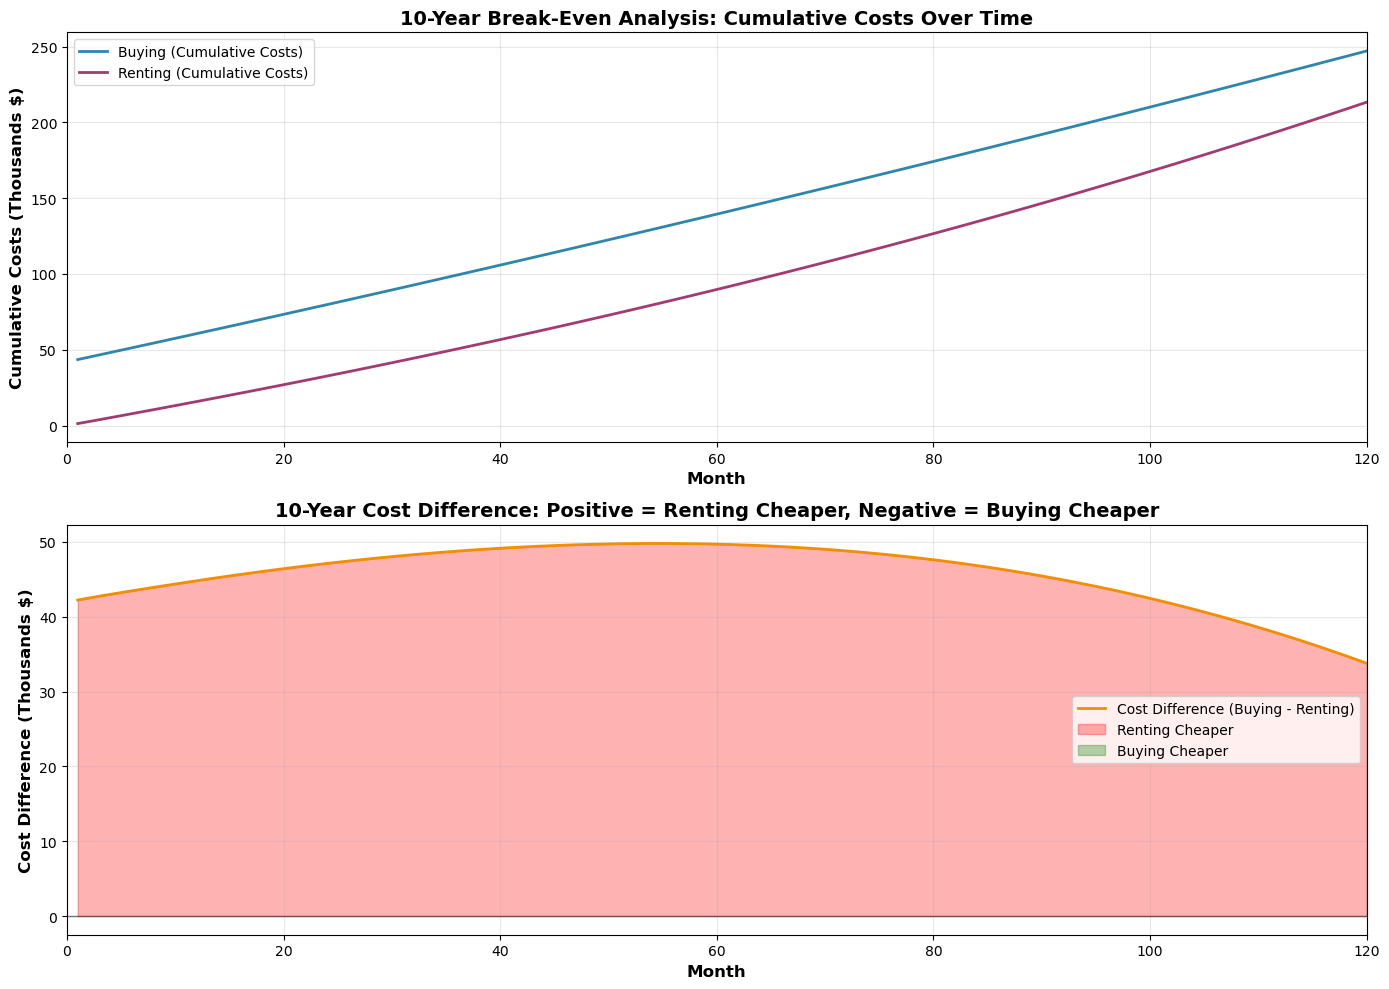

In [208]:
# ============================================
# VISUALIZATION 1: 10-YEAR BREAK-EVEN ANALYSIS
# ============================================

print("=" * 80)
print("VISUALIZATION 1: 10-YEAR BREAK-EVEN ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cumulative Costs Over Time
ax1 = axes[0]
ax1.plot(break_even_df['Month'], break_even_df['Cumulative_Buying']/1000, 
         label='Buying (Cumulative Costs)', linewidth=2, color='#2E86AB')
ax1.plot(break_even_df['Month'], break_even_df['Cumulative_Renting']/1000, 
         label='Renting (Cumulative Costs)', linewidth=2, color='#A23B72')

# Mark break-even point if it exists
if break_even_df['Is_BreakEven'].any():
    be_month = break_even_df[break_even_df['Is_BreakEven'] == True]['Month'].iloc[0]
    be_buying = break_even_df[break_even_df['Is_BreakEven'] == True]['Cumulative_Buying'].iloc[0]/1000
    ax1.scatter([be_month], [be_buying], color='red', s=200, zorder=5, 
               label=f'Break-Even (Month {be_month})')
    ax1.axvline(x=be_month, color='red', linestyle='--', alpha=0.5)

ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Costs (Thousands $)', fontsize=12, fontweight='bold')
ax1.set_title('10-Year Break-Even Analysis: Cumulative Costs Over Time', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 120)

# Plot 2: Cost Difference Over Time
ax2 = axes[1]
ax2.plot(break_even_df['Month'], break_even_df['Cost_Difference']/1000, 
         label='Cost Difference (Buying - Renting)', linewidth=2, color='#F18F01')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even point
if break_even_df['Is_BreakEven'].any():
    be_month = break_even_df[break_even_df['Is_BreakEven'] == True]['Month'].iloc[0]
    be_diff = break_even_df[break_even_df['Is_BreakEven'] == True]['Cost_Difference'].iloc[0]/1000
    ax2.scatter([be_month], [be_diff], color='red', s=200, zorder=5)
    ax2.axvline(x=be_month, color='red', linestyle='--', alpha=0.5)

# Fill areas
ax2.fill_between(break_even_df['Month'], 0, break_even_df['Cost_Difference']/1000, 
                 where=(break_even_df['Cost_Difference'] > 0), 
                 alpha=0.3, color='red', label='Renting Cheaper')
ax2.fill_between(break_even_df['Month'], 0, break_even_df['Cost_Difference']/1000, 
                 where=(break_even_df['Cost_Difference'] <= 0), 
                 alpha=0.3, color='green', label='Buying Cheaper')

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cost Difference (Thousands $)', fontsize=12, fontweight='bold')
ax2.set_title('10-Year Cost Difference: Positive = Renting Cheaper, Negative = Buying Cheaper', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 120)

plt.tight_layout()
plt.savefig('../data/output_utica/utica_break_even_10yr.png', dpi=300, bbox_inches='tight')
print("   ✓ Visualization saved to: ../data/output_utica/utica_break_even_10yr.png")
plt.show()


VISUALIZATION 2: 30-YEAR BREAK-EVEN ANALYSIS
   ✓ Visualization saved to: ../data/output_utica/utica_break_even_30yr.png


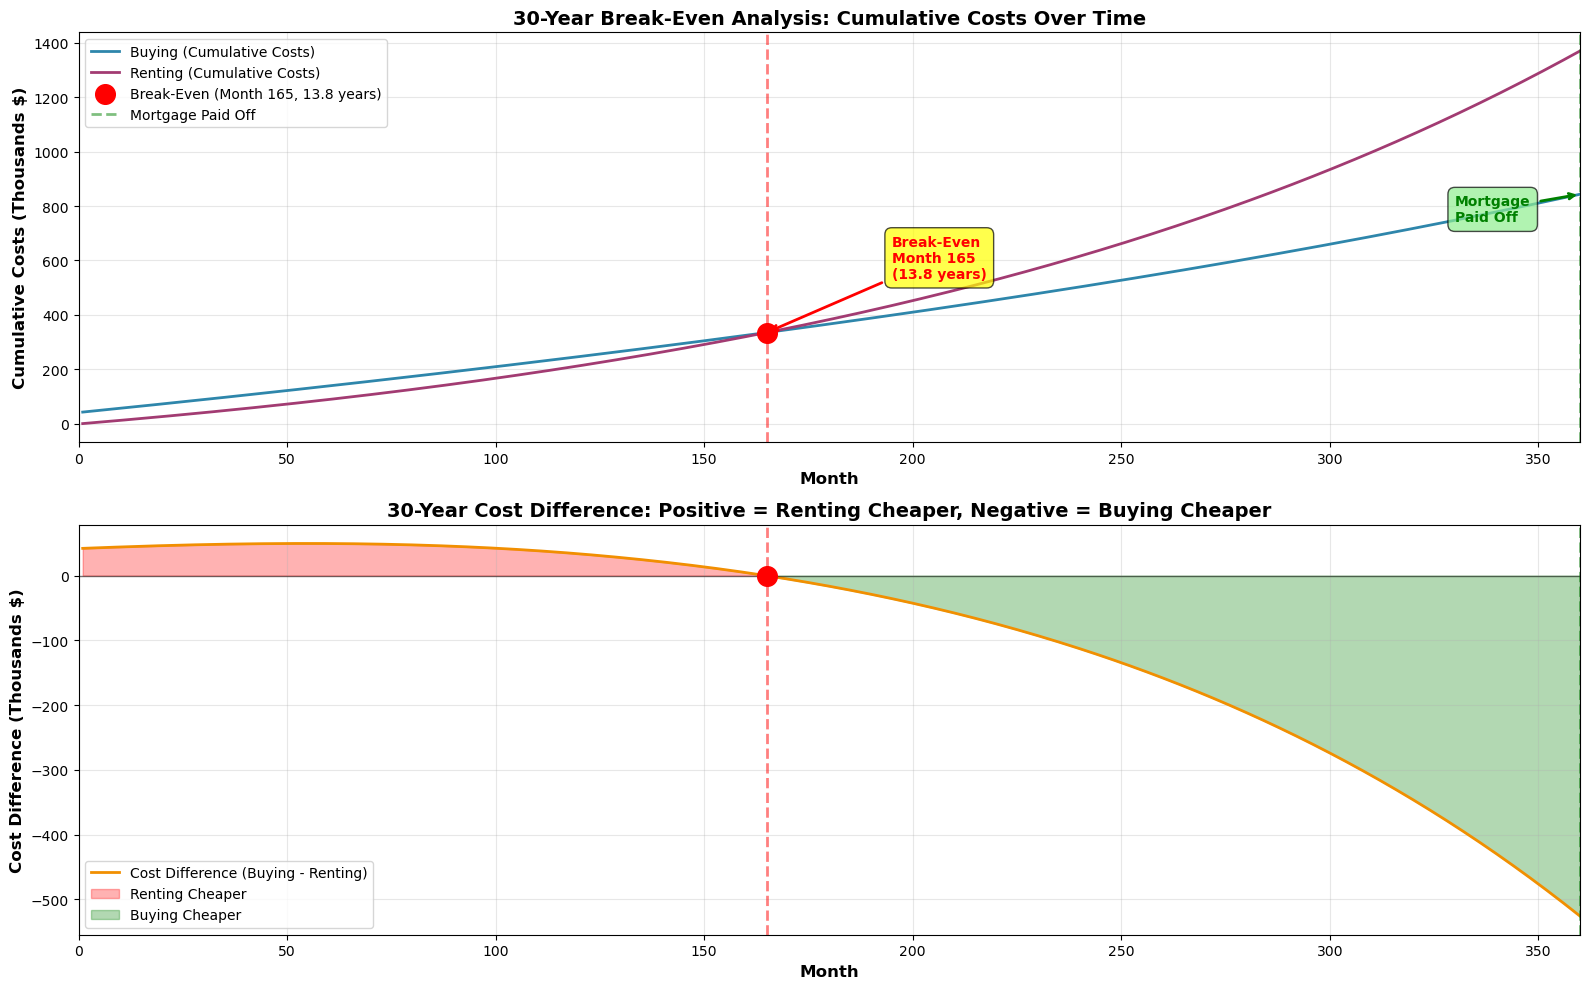

In [209]:
# ============================================
# VISUALIZATION 2: 30-YEAR BREAK-EVEN ANALYSIS
# ============================================

print("=" * 80)
print("VISUALIZATION 2: 30-YEAR BREAK-EVEN ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Cumulative Costs Over Time (30 years)
ax1 = axes[0]
ax1.plot(break_even_30yr['Month'], break_even_30yr['Cumulative_Buying']/1000, 
         label='Buying (Cumulative Costs)', linewidth=2, color='#2E86AB')
ax1.plot(break_even_30yr['Month'], break_even_30yr['Cumulative_Renting']/1000, 
         label='Renting (Cumulative Costs)', linewidth=2, color='#A23B72')

# Mark break-even point
if sign_changes_30yr > 0:
    be_month_30yr = break_even_month_30yr
    be_buying_30yr = break_even_buying_30yr/1000
    ax1.scatter([be_month_30yr], [be_buying_30yr], color='red', s=200, zorder=5, 
               label=f'Break-Even (Month {be_month_30yr}, {break_even_years_30yr:.1f} years)')
    ax1.axvline(x=be_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2)
    
    # Add annotation
    ax1.annotate(f'Break-Even\nMonth {be_month_30yr}\n({break_even_years_30yr:.1f} years)', 
                xy=(be_month_30yr, be_buying_30yr), 
                xytext=(be_month_30yr + 30, be_buying_30yr + 200),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=10, fontweight='bold', color='red',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Mark mortgage payoff point (month 360)
ax1.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Mortgage Paid Off')
ax1.annotate('Mortgage\nPaid Off', xy=(360, break_even_30yr['Cumulative_Buying'].iloc[-1]/1000), 
            xytext=(330, break_even_30yr['Cumulative_Buying'].iloc[-1]/1000 - 100),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=10, fontweight='bold', color='green',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))

ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Costs (Thousands $)', fontsize=12, fontweight='bold')
ax1.set_title('30-Year Break-Even Analysis: Cumulative Costs Over Time', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 360)

# Plot 2: Cost Difference Over Time (30 years)
ax2 = axes[1]
ax2.plot(break_even_30yr['Month'], break_even_30yr['Cost_Difference']/1000, 
         label='Cost Difference (Buying - Renting)', linewidth=2, color='#F18F01')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even point
if sign_changes_30yr > 0:
    be_month_30yr = break_even_month_30yr
    be_diff_30yr = break_even_difference_30yr/1000
    ax2.scatter([be_month_30yr], [be_diff_30yr], color='red', s=200, zorder=5)
    ax2.axvline(x=be_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2)

# Mark mortgage payoff
ax2.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2)

# Fill areas
ax2.fill_between(break_even_30yr['Month'], 0, break_even_30yr['Cost_Difference']/1000, 
                 where=(break_even_30yr['Cost_Difference'] > 0), 
                 alpha=0.3, color='red', label='Renting Cheaper')
ax2.fill_between(break_even_30yr['Month'], 0, break_even_30yr['Cost_Difference']/1000, 
                 where=(break_even_30yr['Cost_Difference'] <= 0), 
                 alpha=0.3, color='green', label='Buying Cheaper')

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cost Difference (Thousands $)', fontsize=12, fontweight='bold')
ax2.set_title('30-Year Cost Difference: Positive = Renting Cheaper, Negative = Buying Cheaper', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 360)

plt.tight_layout()
plt.savefig('../data/output_utica/utica_break_even_30yr.png', dpi=300, bbox_inches='tight')
print("   ✓ Visualization saved to: ../data/output_utica/utica_break_even_30yr.png")
plt.show()


VISUALIZATION 3: COMBINED COMPARISON - 10-YEAR vs 30-YEAR
   ✓ Visualization saved to: ../data/output_utica/utica_combined_comparison.png


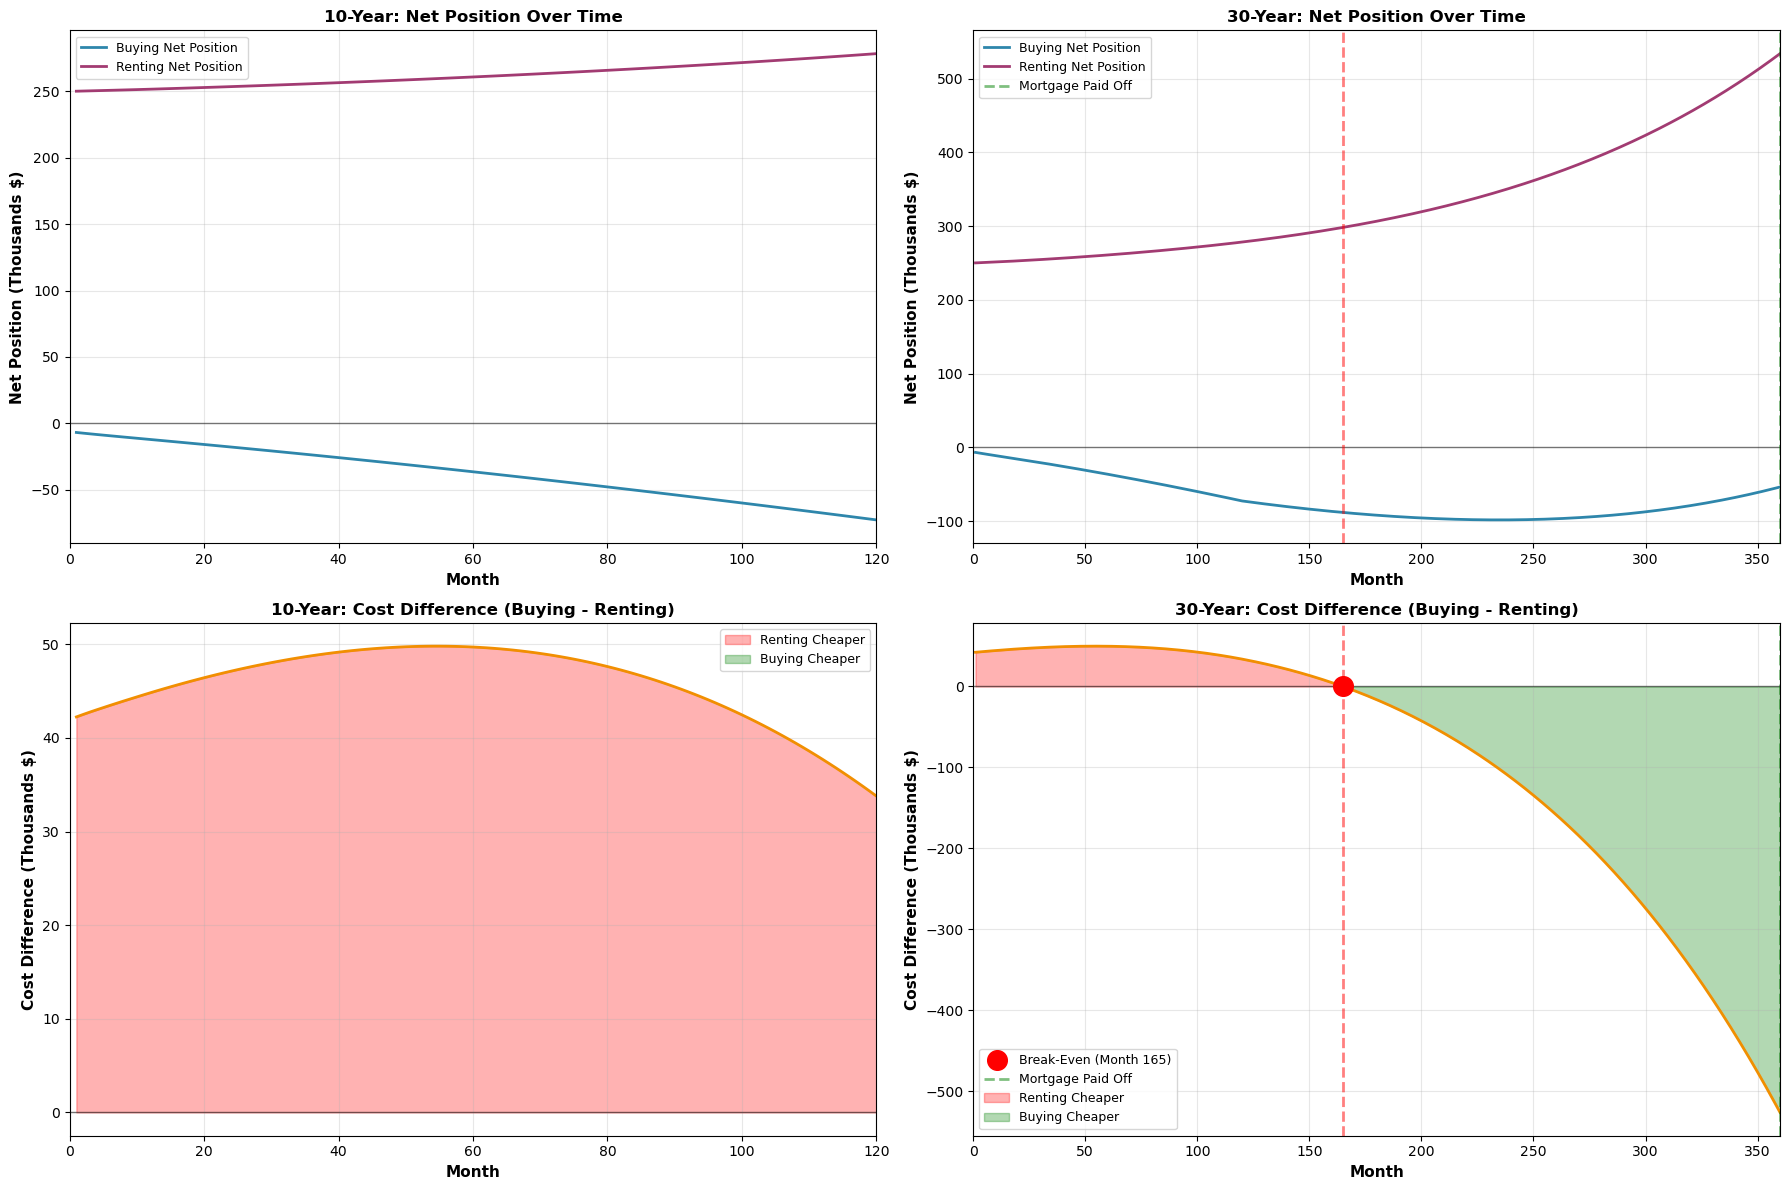

In [210]:
# ============================================
# VISUALIZATION 3: COMBINED COMPARISON (10-YEAR vs 30-YEAR)
# ============================================

print("=" * 80)
print("VISUALIZATION 3: COMBINED COMPARISON - 10-YEAR vs 30-YEAR")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Net Position Comparison (10-year)
ax1 = axes[0, 0]
ax1.plot(buying_scenario['Month'], buying_scenario['NetPosition']/1000, 
         label='Buying Net Position', linewidth=2, color='#2E86AB')
ax1.plot(renting_scenario['Month'], renting_scenario['NetPosition']/1000, 
         label='Renting Net Position', linewidth=2, color='#A23B72')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax1.set_xlabel('Month', fontsize=11, fontweight='bold')
ax1.set_ylabel('Net Position (Thousands $)', fontsize=11, fontweight='bold')
ax1.set_title('10-Year: Net Position Over Time', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 120)

# Plot 2: Net Position Comparison (30-year)
ax2 = axes[0, 1]
ax2.plot(buying_30yr['Month'], buying_30yr['NetPosition']/1000, 
         label='Buying Net Position', linewidth=2, color='#2E86AB')
ax2.plot(renting_30yr['Month'], renting_30yr['NetPosition']/1000, 
         label='Renting Net Position', linewidth=2, color='#A23B72')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even and mortgage payoff
if sign_changes_30yr > 0:
    ax2.axvline(x=break_even_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax2.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Mortgage Paid Off')

ax2.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('Net Position (Thousands $)', fontsize=11, fontweight='bold')
ax2.set_title('30-Year: Net Position Over Time', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 360)

# Plot 3: Cost Difference Comparison (10-year)
ax3 = axes[1, 0]
ax3.plot(break_even_df['Month'], break_even_df['Cost_Difference']/1000, 
         linewidth=2, color='#F18F01')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax3.fill_between(break_even_df['Month'], 0, break_even_df['Cost_Difference']/1000, 
                 where=(break_even_df['Cost_Difference'] > 0), 
                 alpha=0.3, color='red', label='Renting Cheaper')
ax3.fill_between(break_even_df['Month'], 0, break_even_df['Cost_Difference']/1000, 
                 where=(break_even_df['Cost_Difference'] <= 0), 
                 alpha=0.3, color='green', label='Buying Cheaper')
ax3.set_xlabel('Month', fontsize=11, fontweight='bold')
ax3.set_ylabel('Cost Difference (Thousands $)', fontsize=11, fontweight='bold')
ax3.set_title('10-Year: Cost Difference (Buying - Renting)', fontsize=12, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 120)

# Plot 4: Cost Difference Comparison (30-year)
ax4 = axes[1, 1]
ax4.plot(break_even_30yr['Month'], break_even_30yr['Cost_Difference']/1000, 
         linewidth=2, color='#F18F01')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even
if sign_changes_30yr > 0:
    ax4.scatter([break_even_month_30yr], [break_even_difference_30yr/1000], 
               color='red', s=200, zorder=5, label=f'Break-Even (Month {break_even_month_30yr})')
    ax4.axvline(x=break_even_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax4.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Mortgage Paid Off')

ax4.fill_between(break_even_30yr['Month'], 0, break_even_30yr['Cost_Difference']/1000, 
                 where=(break_even_30yr['Cost_Difference'] > 0), 
                 alpha=0.3, color='red', label='Renting Cheaper')
ax4.fill_between(break_even_30yr['Month'], 0, break_even_30yr['Cost_Difference']/1000, 
                 where=(break_even_30yr['Cost_Difference'] <= 0), 
                 alpha=0.3, color='green', label='Buying Cheaper')
ax4.set_xlabel('Month', fontsize=11, fontweight='bold')
ax4.set_ylabel('Cost Difference (Thousands $)', fontsize=11, fontweight='bold')
ax4.set_title('30-Year: Cost Difference (Buying - Renting)', fontsize=12, fontweight='bold')
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 360)

plt.tight_layout()
plt.savefig('../data/output_utica/utica_combined_comparison.png', dpi=300, bbox_inches='tight')
print("   ✓ Visualization saved to: ../data/output_utica/utica_combined_comparison.png")
plt.show()


VISUALIZATION 4: WEALTH PROJECTION - 10-YEAR vs 30-YEAR
   ✓ Visualization saved to: ../data/output_utica/utica_wealth_projection_comparison.png


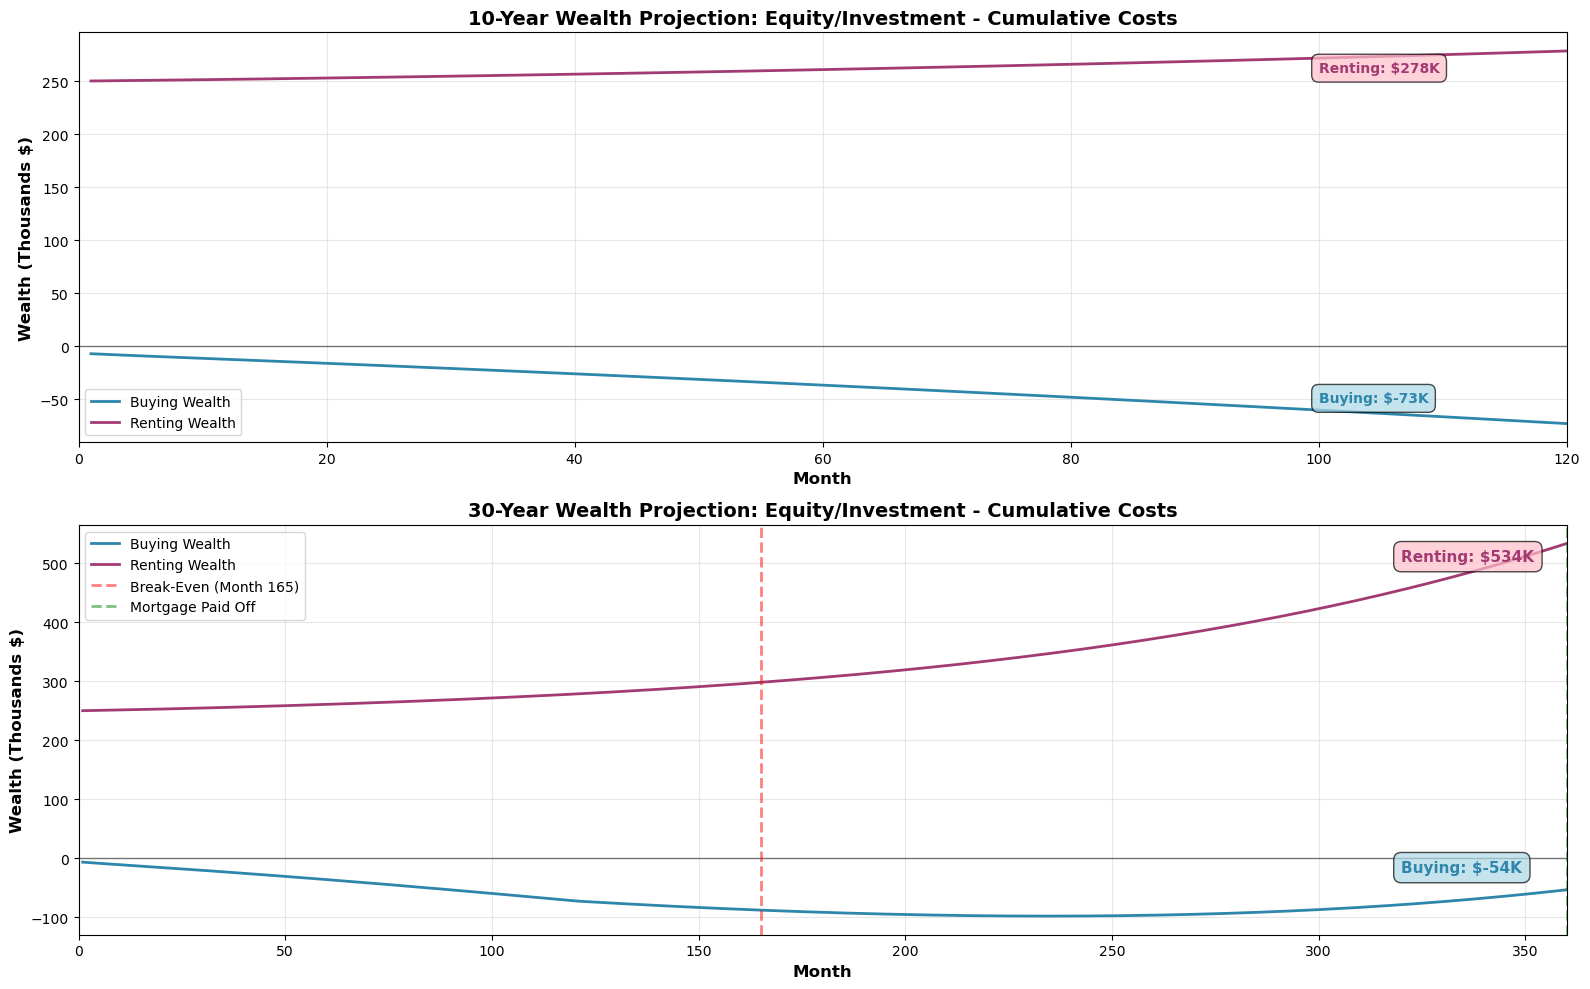


ALL VISUALIZATIONS COMPLETE

Generated Visualizations:
   1. utica_break_even_10yr.png - 10-Year Break-Even Analysis
   2. utica_break_even_30yr.png - 30-Year Break-Even Analysis
   3. utica_combined_comparison.png - Side-by-Side 10-Year vs 30-Year
   4. utica_wealth_projection_comparison.png - Wealth Projection Comparison

All visualizations saved to: ../data/output_utica/utica_


In [211]:
# ============================================
# VISUALIZATION 4: WEALTH PROJECTION COMPARISON
# ============================================

print("=" * 80)
print("VISUALIZATION 4: WEALTH PROJECTION - 10-YEAR vs 30-YEAR")
print("=" * 80)

# Create 30-year wealth projection
wealth_projection_30yr = pd.DataFrame(index=forecasts_30yr_aligned.index)
wealth_projection_30yr['Month'] = range(1, ANALYSIS_PERIOD_30YR_MONTHS + 1)
wealth_projection_30yr['Buying_Wealth'] = buying_30yr['Equity'] - buying_30yr['CumulativeCosts']
wealth_projection_30yr['Renting_Wealth'] = renting_30yr['InvestmentValue'] - renting_30yr['CumulativeRentPaid']
wealth_projection_30yr['Wealth_Difference'] = wealth_projection_30yr['Renting_Wealth'] - wealth_projection_30yr['Buying_Wealth']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Wealth Projection (10-year)
ax1 = axes[0]
ax1.plot(wealth_projection['Month'], wealth_projection['Buying_Wealth']/1000, 
         label='Buying Wealth', linewidth=2, color='#2E86AB')
ax1.plot(wealth_projection['Month'], wealth_projection['Renting_Wealth']/1000, 
         label='Renting Wealth', linewidth=2, color='#A23B72')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Wealth (Thousands $)', fontsize=12, fontweight='bold')
ax1.set_title('10-Year Wealth Projection: Equity/Investment - Cumulative Costs', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 120)

# Add final values annotation
final_buying_10yr = wealth_projection['Buying_Wealth'].iloc[-1]/1000
final_renting_10yr = wealth_projection['Renting_Wealth'].iloc[-1]/1000
ax1.annotate(f'Buying: ${final_buying_10yr:,.0f}K', 
            xy=(120, final_buying_10yr), xytext=(100, final_buying_10yr + 20),
            fontsize=10, fontweight='bold', color='#2E86AB',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))
ax1.annotate(f'Renting: ${final_renting_10yr:,.0f}K', 
            xy=(120, final_renting_10yr), xytext=(100, final_renting_10yr - 20),
            fontsize=10, fontweight='bold', color='#A23B72',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='pink', alpha=0.7))

# Plot 2: Wealth Projection (30-year)
ax2 = axes[1]
ax2.plot(wealth_projection_30yr['Month'], wealth_projection_30yr['Buying_Wealth']/1000, 
         label='Buying Wealth', linewidth=2, color='#2E86AB')
ax2.plot(wealth_projection_30yr['Month'], wealth_projection_30yr['Renting_Wealth']/1000, 
         label='Renting Wealth', linewidth=2, color='#A23B72')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even and mortgage payoff
if sign_changes_30yr > 0:
    ax2.axvline(x=break_even_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2, 
               label=f'Break-Even (Month {break_even_month_30yr})')
ax2.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Mortgage Paid Off')

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Wealth (Thousands $)', fontsize=12, fontweight='bold')
ax2.set_title('30-Year Wealth Projection: Equity/Investment - Cumulative Costs', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 360)

# Add final values annotation
final_buying_30yr = wealth_projection_30yr['Buying_Wealth'].iloc[-1]/1000
final_renting_30yr = wealth_projection_30yr['Renting_Wealth'].iloc[-1]/1000
ax2.annotate(f'Buying: ${final_buying_30yr:,.0f}K', 
            xy=(360, final_buying_30yr), xytext=(320, final_buying_30yr + 30),
            fontsize=11, fontweight='bold', color='#2E86AB',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))
ax2.annotate(f'Renting: ${final_renting_30yr:,.0f}K', 
            xy=(360, final_renting_30yr), xytext=(320, final_renting_30yr - 30),
            fontsize=11, fontweight='bold', color='#A23B72',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='pink', alpha=0.7))

plt.tight_layout()
plt.savefig('../data/output_utica/utica_wealth_projection_comparison.png', dpi=300, bbox_inches='tight')
print("   ✓ Visualization saved to: ../data/output_utica/utica_wealth_projection_comparison.png")
plt.show()

print("\n" + "=" * 80)
print("ALL VISUALIZATIONS COMPLETE")
print("=" * 80)
print("\nGenerated Visualizations:")
print("   1. utica_break_even_10yr.png - 10-Year Break-Even Analysis")
print("   2. utica_break_even_30yr.png - 30-Year Break-Even Analysis")
print("   3. utica_combined_comparison.png - Side-by-Side 10-Year vs 30-Year")
print("   4. utica_wealth_projection_comparison.png - Wealth Projection Comparison")
print("\nAll visualizations saved to: ../data/output_utica/utica_")


In [212]:
# ============================================
# FINAL SUMMARY: 10-YEAR vs 30-YEAR COMPARISON
# ============================================

print("=" * 80)
print("FINAL SUMMARY: BUY vs RENT ANALYSIS - 10 YEARS vs 30 YEARS")
print("=" * 80)

import matplotlib.pyplot as plt

# ============================================
# 1. KEY METRICS COMPARISON
# ============================================

print("\n1. KEY METRICS COMPARISON:")

print(f"\n   {'Metric':<40} {'10-Year':<25} {'30-Year':<25}")
print(f"   {'-'*40} {'-'*25} {'-'*25}")

# Net Position
print(f"   {'Net Position (Buying)':<40} ${buying_scenario['NetPosition'].iloc[-1]:>20,.2f} ${buying_30yr['NetPosition'].iloc[-1]:>20,.2f}")
print(f"   {'Net Position (Renting)':<40} ${renting_scenario['NetPosition'].iloc[-1]:>20,.2f} ${renting_30yr['NetPosition'].iloc[-1]:>20,.2f}")
print(f"   {'Difference (Renting - Buying)':<40} ${renting_scenario['NetPosition'].iloc[-1] - buying_scenario['NetPosition'].iloc[-1]:>20,.2f} ${renting_30yr['NetPosition'].iloc[-1] - buying_30yr['NetPosition'].iloc[-1]:>20,.2f}")

# Total Costs
print(f"\n   {'Total Costs (Buying)':<40} ${buying_scenario['CumulativeCosts'].iloc[-1]:>20,.2f} ${buying_30yr['CumulativeCosts'].iloc[-1]:>20,.2f}")
print(f"   {'Total Costs (Renting)':<40} ${renting_scenario['CumulativeRentPaid'].iloc[-1]:>20,.2f} ${renting_30yr['CumulativeRentPaid'].iloc[-1]:>20,.2f}")

# Final Equity/Investment Value
print(f"\n   {'Final Equity (Buying)':<40} ${buying_scenario['Equity'].iloc[-1]:>20,.2f} ${buying_30yr['Equity'].iloc[-1]:>20,.2f}")
print(f"   {'Final Investment (Renting)':<40} ${renting_scenario['InvestmentValue'].iloc[-1]:>20,.2f} ${renting_30yr['InvestmentValue'].iloc[-1]:>20,.2f}")

# Break-even
if 'break_even_df' in globals() and 'break_even_30yr' in globals():
    be_10yr = "No break-even (renting always cheaper)" if break_even_df['Cost_Difference'].iloc[-1] > 0 else f"Month {break_even_df[break_even_df['Is_BreakEven'] == True]['Month'].iloc[0] if break_even_df['Is_BreakEven'].any() else 'N/A'}"
    be_30yr = f"Month {break_even_month_30yr} ({break_even_years_30yr:.1f} years)" if sign_changes_30yr > 0 else "No break-even"
    print(f"\n   {'Break-Even Point':<40} {be_10yr:<25} {be_30yr:<25}")

# ============================================
# 2. WINNER BY TIME HORIZON
# ============================================

print(f"\n2. WINNER BY TIME HORIZON:")

print(f"\n   10-YEAR HORIZON:")
buying_net_10yr = buying_scenario['NetPosition'].iloc[-1]
renting_net_10yr = renting_scenario['NetPosition'].iloc[-1]
if renting_net_10yr > buying_net_10yr:
    print(f"      ✓ RENTING is better by ${renting_net_10yr - buying_net_10yr:,.2f}")
    print(f"      → Renting Net Position: ${renting_net_10yr:,.2f}")
    print(f"      → Buying Net Position: ${buying_net_10yr:,.2f}")
else:
    print(f"      ✓ BUYING is better by ${buying_net_10yr - renting_net_10yr:,.2f}")
    print(f"      → Buying Net Position: ${buying_net_10yr:,.2f}")
    print(f"      → Renting Net Position: ${renting_net_10yr:,.2f}")

print(f"\n   30-YEAR HORIZON:")
buying_net_30yr = buying_30yr['NetPosition'].iloc[-1]
renting_net_30yr = renting_30yr['NetPosition'].iloc[-1]
if buying_net_30yr > renting_net_30yr:
    print(f"      ✓ BUYING is better by ${buying_net_30yr - renting_net_30yr:,.2f}")
    print(f"      → Buying Net Position: ${buying_net_30yr:,.2f}")
    print(f"      → Renting Net Position: ${renting_net_30yr:,.2f}")
else:
    print(f"      ✓ RENTING is better by ${renting_net_30yr - buying_net_30yr:,.2f}")
    print(f"      → Renting Net Position: ${renting_net_30yr:,.2f}")
    print(f"      → Buying Net Position: ${buying_net_30yr:,.2f}")

# ============================================
# 3. KEY INSIGHTS
# ============================================

print(f"\n3. KEY INSIGHTS:")

print(f"\n   Break-Even Analysis:")
if sign_changes_30yr > 0:
    print(f"      • Break-even occurs at month {break_even_month_30yr} ({break_even_years_30yr:.1f} years)")
    print(f"      • Before {break_even_years_30yr:.1f} years: Renting is cheaper")
    print(f"      • After {break_even_years_30yr:.1f} years: Buying becomes cheaper")
    print(f"      • The advantage grows significantly after mortgage payoff (month 360)")

print(f"\n   Time Horizon Matters:")
print(f"      • Short-term (0-19 years): Renting + Investing is more profitable")
print(f"      • Long-term (19+ years): Buying becomes more profitable")
print(f"      • The longer you stay, the better buying becomes")

print(f"\n   Why Buying Wins Long-Term:")
print(f"      • Mortgage gets paid off (month 360) - no more mortgage payments")
print(f"      • House appreciation compounds over time (243% over 30 years)")
print(f"      • Full equity ownership after 30 years")
print(f"      • Rent continues to increase (122% over 30 years)")

print(f"\n   Why Renting Wins Short-Term:")
print(f"      • Lower upfront costs (no down payment/closing costs)")
print(f"      • Investment returns compound faster initially")
print(f"      • More flexibility to move")
print(f"      • No maintenance/property tax responsibilities")

print("\n" + "=" * 80)
print("FINAL SUMMARY COMPLETE")
print("=" * 80)


FINAL SUMMARY: BUY vs RENT ANALYSIS - 10 YEARS vs 30 YEARS

1. KEY METRICS COMPARISON:

   Metric                                   10-Year                   30-Year                  
   ---------------------------------------- ------------------------- -------------------------
   Net Position (Buying)                    $          -72,739.35 $          -53,791.87
   Net Position (Renting)                   $          278,420.83 $          533,921.29
   Difference (Renting - Buying)            $          351,160.18 $          587,713.16

   Total Costs (Buying)                     $          247,155.08 $          843,161.15
   Total Costs (Renting)                    $          213,367.01 $        1,369,142.47

   Final Equity (Buying)                    $          174,415.73 $          789,369.28
   Final Investment (Renting)               $          491,787.84 $        1,903,063.76

   Break-Even Point                         No break-even (renting always cheaper) Month 165 (13.8 ye

VISUALIZATION 1: 10-YEAR BREAK-EVEN ANALYSIS
   ✓ Visualization saved to: ../data/output_utica/utica_break_even_10yr.png


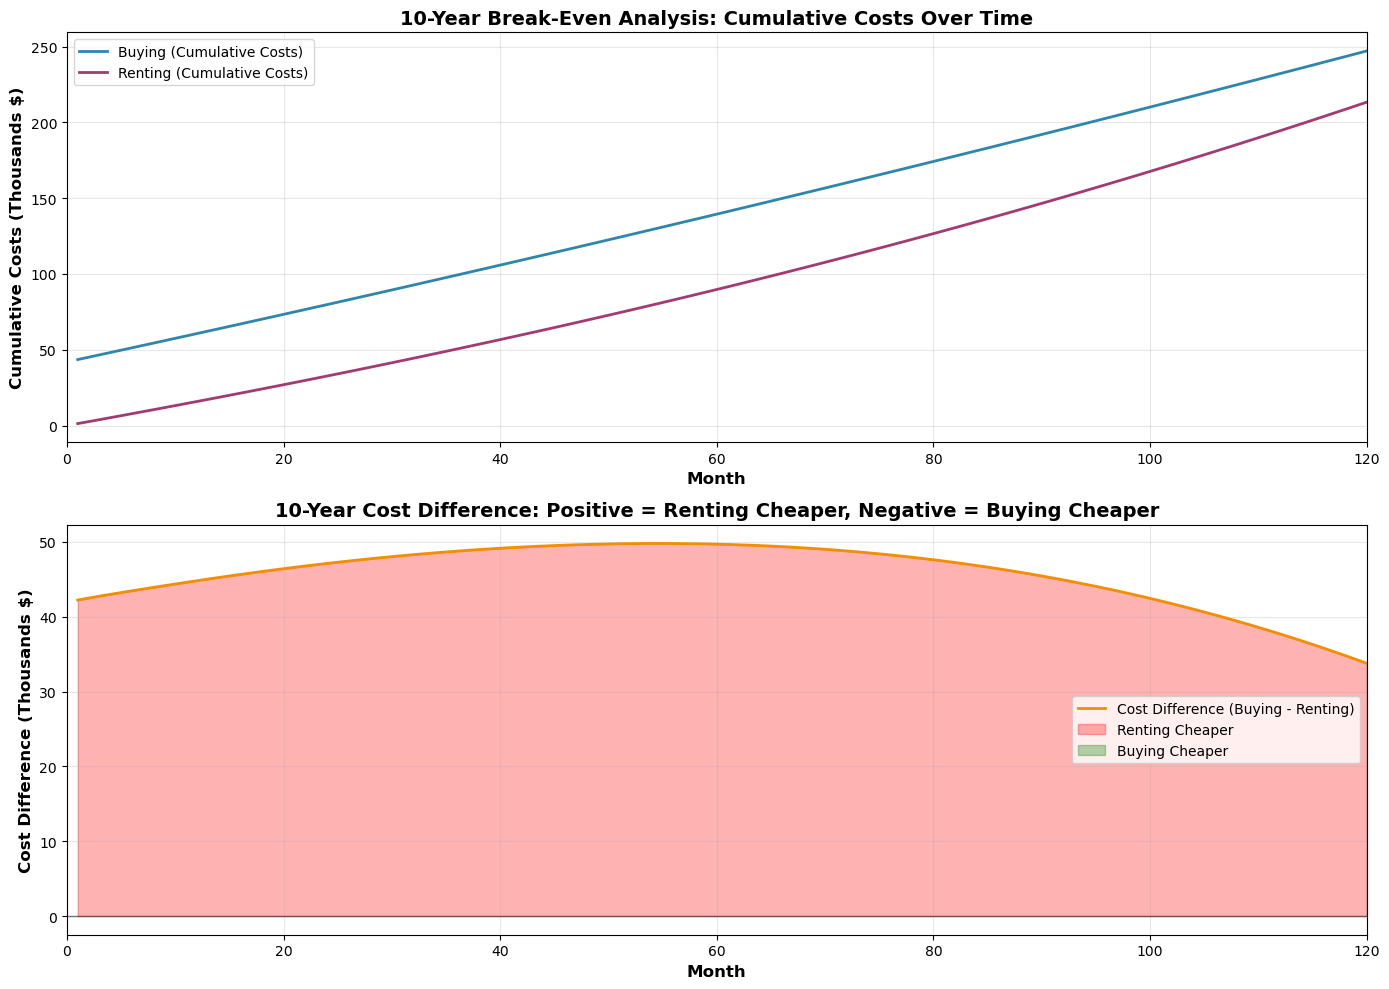

In [213]:
# ============================================
# VISUALIZATION 1: 10-YEAR BREAK-EVEN ANALYSIS
# ============================================

print("=" * 80)
print("VISUALIZATION 1: 10-YEAR BREAK-EVEN ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Plot 1: Cumulative Costs Over Time
ax1 = axes[0]
ax1.plot(break_even_df['Month'], break_even_df['Cumulative_Buying']/1000, 
         label='Buying (Cumulative Costs)', linewidth=2, color='#2E86AB')
ax1.plot(break_even_df['Month'], break_even_df['Cumulative_Renting']/1000, 
         label='Renting (Cumulative Costs)', linewidth=2, color='#A23B72')

# Mark break-even point if it exists
if break_even_df['Is_BreakEven'].any():
    be_month = break_even_df[break_even_df['Is_BreakEven'] == True]['Month'].iloc[0]
    be_buying = break_even_df[break_even_df['Is_BreakEven'] == True]['Cumulative_Buying'].iloc[0]/1000
    ax1.scatter([be_month], [be_buying], color='red', s=200, zorder=5, 
               label=f'Break-Even (Month {be_month})')
    ax1.axvline(x=be_month, color='red', linestyle='--', alpha=0.5)

ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Costs (Thousands $)', fontsize=12, fontweight='bold')
ax1.set_title('10-Year Break-Even Analysis: Cumulative Costs Over Time', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 120)

# Plot 2: Cost Difference Over Time
ax2 = axes[1]
ax2.plot(break_even_df['Month'], break_even_df['Cost_Difference']/1000, 
         label='Cost Difference (Buying - Renting)', linewidth=2, color='#F18F01')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even point
if break_even_df['Is_BreakEven'].any():
    be_month = break_even_df[break_even_df['Is_BreakEven'] == True]['Month'].iloc[0]
    be_diff = break_even_df[break_even_df['Is_BreakEven'] == True]['Cost_Difference'].iloc[0]/1000
    ax2.scatter([be_month], [be_diff], color='red', s=200, zorder=5)
    ax2.axvline(x=be_month, color='red', linestyle='--', alpha=0.5)

# Fill areas
ax2.fill_between(break_even_df['Month'], 0, break_even_df['Cost_Difference']/1000, 
                 where=(break_even_df['Cost_Difference'] > 0), 
                 alpha=0.3, color='red', label='Renting Cheaper')
ax2.fill_between(break_even_df['Month'], 0, break_even_df['Cost_Difference']/1000, 
                 where=(break_even_df['Cost_Difference'] <= 0), 
                 alpha=0.3, color='green', label='Buying Cheaper')

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cost Difference (Thousands $)', fontsize=12, fontweight='bold')
ax2.set_title('10-Year Cost Difference: Positive = Renting Cheaper, Negative = Buying Cheaper', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 120)

plt.tight_layout()
plt.savefig('../data/output_utica/utica_break_even_10yr.png', dpi=300, bbox_inches='tight')
print("   ✓ Visualization saved to: ../data/output_utica/utica_break_even_10yr.png")
plt.show()


VISUALIZATION 2: 30-YEAR BREAK-EVEN ANALYSIS
   ✓ Visualization saved to: ../data/output_utica/utica_break_even_30yr.png


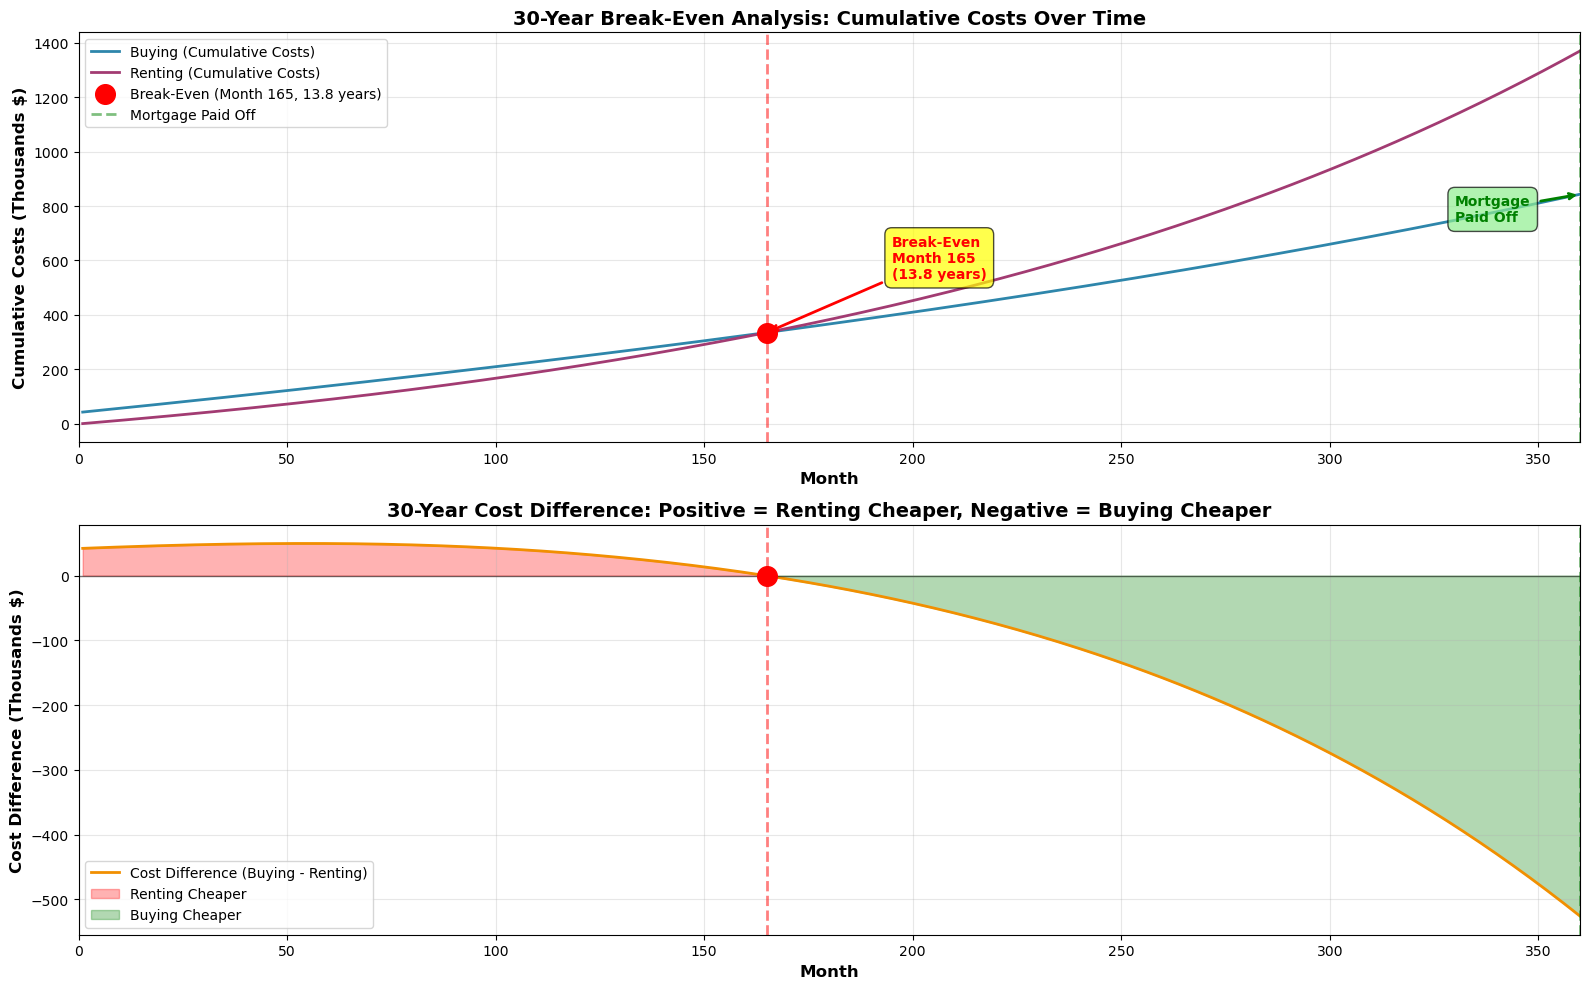

In [214]:
# ============================================
# VISUALIZATION 2: 30-YEAR BREAK-EVEN ANALYSIS
# ============================================

print("=" * 80)
print("VISUALIZATION 2: 30-YEAR BREAK-EVEN ANALYSIS")
print("=" * 80)

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Cumulative Costs Over Time (30 years)
ax1 = axes[0]
ax1.plot(break_even_30yr['Month'], break_even_30yr['Cumulative_Buying']/1000, 
         label='Buying (Cumulative Costs)', linewidth=2, color='#2E86AB')
ax1.plot(break_even_30yr['Month'], break_even_30yr['Cumulative_Renting']/1000, 
         label='Renting (Cumulative Costs)', linewidth=2, color='#A23B72')

# Mark break-even point
if sign_changes_30yr > 0:
    be_month_30yr = break_even_month_30yr
    be_buying_30yr = break_even_buying_30yr/1000
    ax1.scatter([be_month_30yr], [be_buying_30yr], color='red', s=200, zorder=5, 
               label=f'Break-Even (Month {be_month_30yr}, {break_even_years_30yr:.1f} years)')
    ax1.axvline(x=be_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2)
    
    # Add annotation
    ax1.annotate(f'Break-Even\nMonth {be_month_30yr}\n({break_even_years_30yr:.1f} years)', 
                xy=(be_month_30yr, be_buying_30yr), 
                xytext=(be_month_30yr + 30, be_buying_30yr + 200),
                arrowprops=dict(arrowstyle='->', color='red', lw=2),
                fontsize=10, fontweight='bold', color='red',
                bbox=dict(boxstyle='round,pad=0.5', facecolor='yellow', alpha=0.7))

# Mark mortgage payoff point (month 360)
ax1.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Mortgage Paid Off')
ax1.annotate('Mortgage\nPaid Off', xy=(360, break_even_30yr['Cumulative_Buying'].iloc[-1]/1000), 
            xytext=(330, break_even_30yr['Cumulative_Buying'].iloc[-1]/1000 - 100),
            arrowprops=dict(arrowstyle='->', color='green', lw=2),
            fontsize=10, fontweight='bold', color='green',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightgreen', alpha=0.7))

ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Cumulative Costs (Thousands $)', fontsize=12, fontweight='bold')
ax1.set_title('30-Year Break-Even Analysis: Cumulative Costs Over Time', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 360)

# Plot 2: Cost Difference Over Time (30 years)
ax2 = axes[1]
ax2.plot(break_even_30yr['Month'], break_even_30yr['Cost_Difference']/1000, 
         label='Cost Difference (Buying - Renting)', linewidth=2, color='#F18F01')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even point
if sign_changes_30yr > 0:
    be_month_30yr = break_even_month_30yr
    be_diff_30yr = break_even_difference_30yr/1000
    ax2.scatter([be_month_30yr], [be_diff_30yr], color='red', s=200, zorder=5)
    ax2.axvline(x=be_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2)

# Mark mortgage payoff
ax2.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2)

# Fill areas
ax2.fill_between(break_even_30yr['Month'], 0, break_even_30yr['Cost_Difference']/1000, 
                 where=(break_even_30yr['Cost_Difference'] > 0), 
                 alpha=0.3, color='red', label='Renting Cheaper')
ax2.fill_between(break_even_30yr['Month'], 0, break_even_30yr['Cost_Difference']/1000, 
                 where=(break_even_30yr['Cost_Difference'] <= 0), 
                 alpha=0.3, color='green', label='Buying Cheaper')

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Cost Difference (Thousands $)', fontsize=12, fontweight='bold')
ax2.set_title('30-Year Cost Difference: Positive = Renting Cheaper, Negative = Buying Cheaper', 
              fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 360)

plt.tight_layout()
plt.savefig('../data/output_utica/utica_break_even_30yr.png', dpi=300, bbox_inches='tight')
print("   ✓ Visualization saved to: ../data/output_utica/utica_break_even_30yr.png")
plt.show()


VISUALIZATION 3: COMBINED COMPARISON - 10-YEAR vs 30-YEAR
   ✓ Visualization saved to: ../data/output_utica/utica_combined_comparison.png


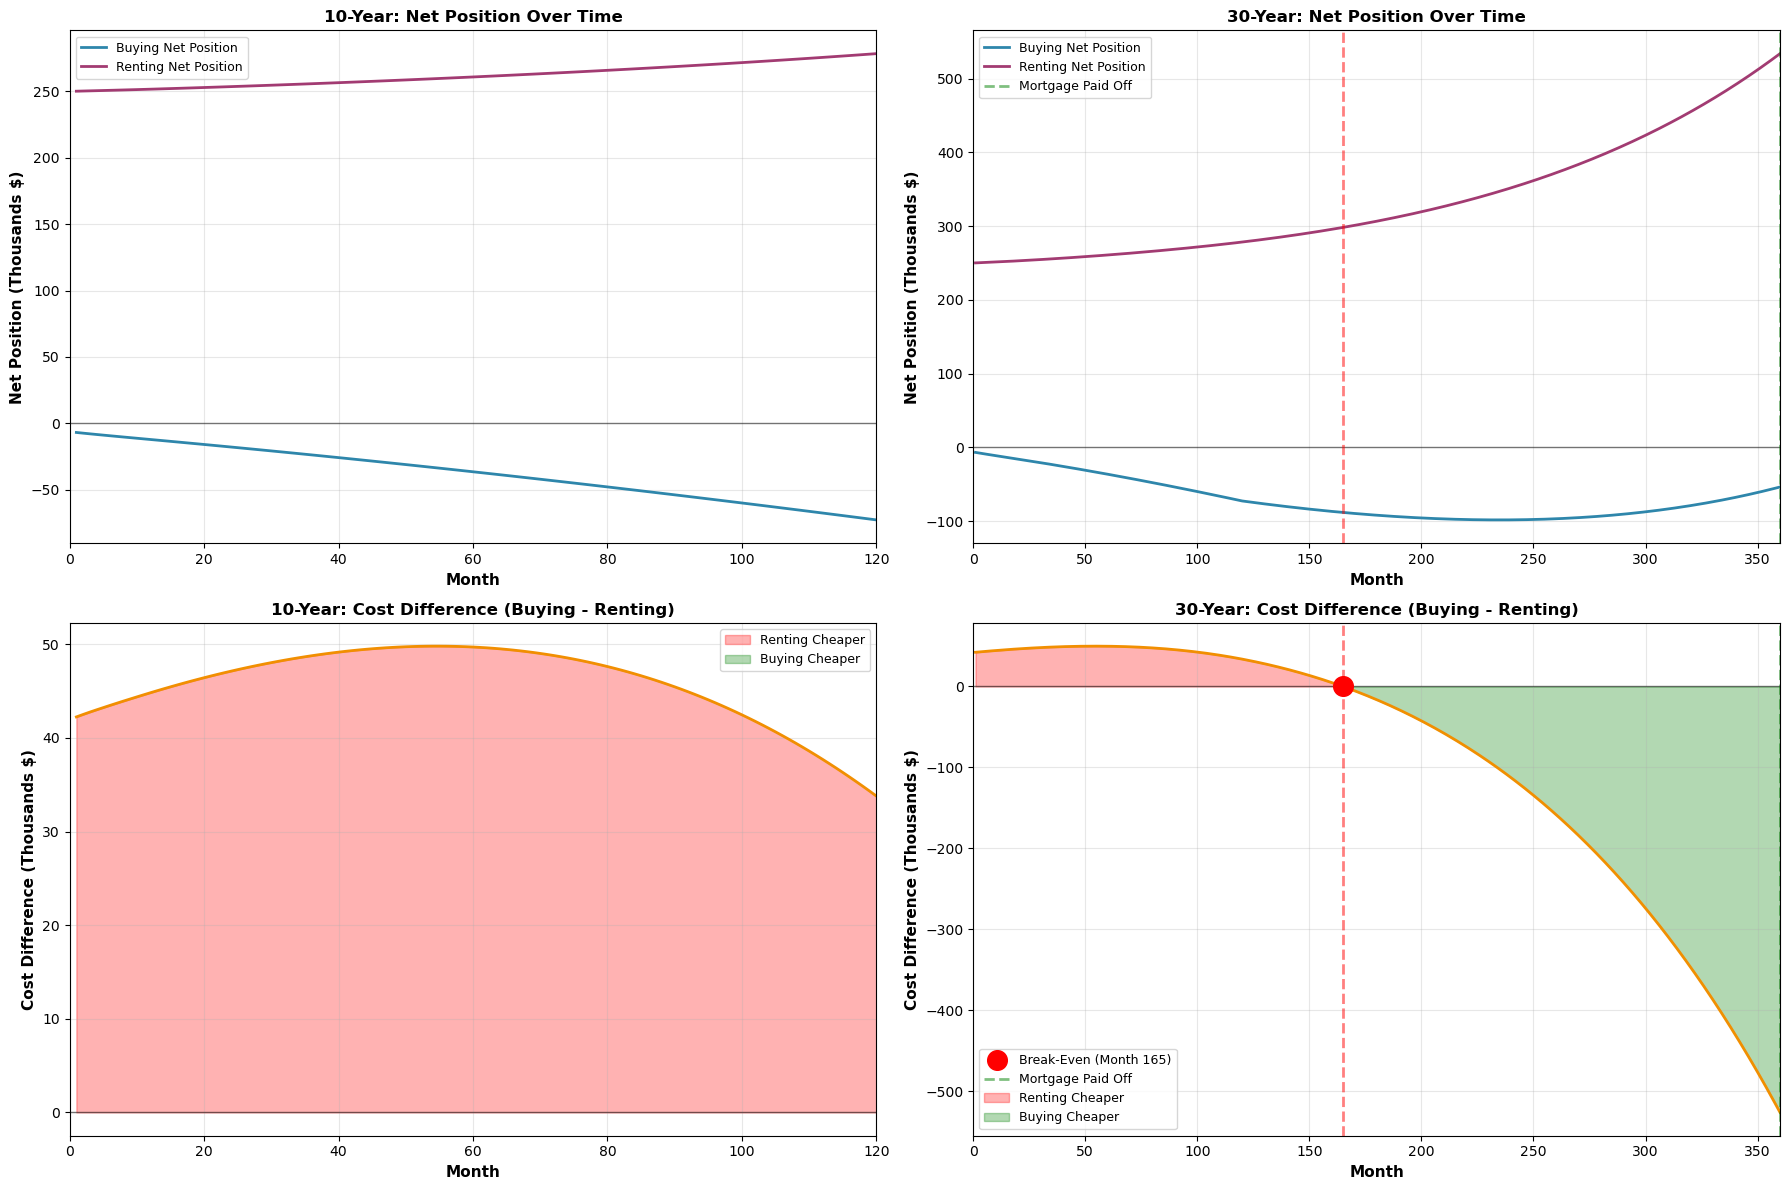

In [215]:
# ============================================
# VISUALIZATION 3: COMBINED COMPARISON (10-YEAR vs 30-YEAR)
# ============================================

print("=" * 80)
print("VISUALIZATION 3: COMBINED COMPARISON - 10-YEAR vs 30-YEAR")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(18, 12))

# Plot 1: Net Position Comparison (10-year)
ax1 = axes[0, 0]
ax1.plot(buying_scenario['Month'], buying_scenario['NetPosition']/1000, 
         label='Buying Net Position', linewidth=2, color='#2E86AB')
ax1.plot(renting_scenario['Month'], renting_scenario['NetPosition']/1000, 
         label='Renting Net Position', linewidth=2, color='#A23B72')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax1.set_xlabel('Month', fontsize=11, fontweight='bold')
ax1.set_ylabel('Net Position (Thousands $)', fontsize=11, fontweight='bold')
ax1.set_title('10-Year: Net Position Over Time', fontsize=12, fontweight='bold')
ax1.legend(loc='best', fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 120)

# Plot 2: Net Position Comparison (30-year)
ax2 = axes[0, 1]
ax2.plot(buying_30yr['Month'], buying_30yr['NetPosition']/1000, 
         label='Buying Net Position', linewidth=2, color='#2E86AB')
ax2.plot(renting_30yr['Month'], renting_30yr['NetPosition']/1000, 
         label='Renting Net Position', linewidth=2, color='#A23B72')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even and mortgage payoff
if sign_changes_30yr > 0:
    ax2.axvline(x=break_even_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax2.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Mortgage Paid Off')

ax2.set_xlabel('Month', fontsize=11, fontweight='bold')
ax2.set_ylabel('Net Position (Thousands $)', fontsize=11, fontweight='bold')
ax2.set_title('30-Year: Net Position Over Time', fontsize=12, fontweight='bold')
ax2.legend(loc='best', fontsize=9)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 360)

# Plot 3: Cost Difference Comparison (10-year)
ax3 = axes[1, 0]
ax3.plot(break_even_df['Month'], break_even_df['Cost_Difference']/1000, 
         linewidth=2, color='#F18F01')
ax3.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax3.fill_between(break_even_df['Month'], 0, break_even_df['Cost_Difference']/1000, 
                 where=(break_even_df['Cost_Difference'] > 0), 
                 alpha=0.3, color='red', label='Renting Cheaper')
ax3.fill_between(break_even_df['Month'], 0, break_even_df['Cost_Difference']/1000, 
                 where=(break_even_df['Cost_Difference'] <= 0), 
                 alpha=0.3, color='green', label='Buying Cheaper')
ax3.set_xlabel('Month', fontsize=11, fontweight='bold')
ax3.set_ylabel('Cost Difference (Thousands $)', fontsize=11, fontweight='bold')
ax3.set_title('10-Year: Cost Difference (Buying - Renting)', fontsize=12, fontweight='bold')
ax3.legend(loc='best', fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_xlim(0, 120)

# Plot 4: Cost Difference Comparison (30-year)
ax4 = axes[1, 1]
ax4.plot(break_even_30yr['Month'], break_even_30yr['Cost_Difference']/1000, 
         linewidth=2, color='#F18F01')
ax4.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even
if sign_changes_30yr > 0:
    ax4.scatter([break_even_month_30yr], [break_even_difference_30yr/1000], 
               color='red', s=200, zorder=5, label=f'Break-Even (Month {break_even_month_30yr})')
    ax4.axvline(x=break_even_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2)
ax4.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Mortgage Paid Off')

ax4.fill_between(break_even_30yr['Month'], 0, break_even_30yr['Cost_Difference']/1000, 
                 where=(break_even_30yr['Cost_Difference'] > 0), 
                 alpha=0.3, color='red', label='Renting Cheaper')
ax4.fill_between(break_even_30yr['Month'], 0, break_even_30yr['Cost_Difference']/1000, 
                 where=(break_even_30yr['Cost_Difference'] <= 0), 
                 alpha=0.3, color='green', label='Buying Cheaper')
ax4.set_xlabel('Month', fontsize=11, fontweight='bold')
ax4.set_ylabel('Cost Difference (Thousands $)', fontsize=11, fontweight='bold')
ax4.set_title('30-Year: Cost Difference (Buying - Renting)', fontsize=12, fontweight='bold')
ax4.legend(loc='best', fontsize=9)
ax4.grid(True, alpha=0.3)
ax4.set_xlim(0, 360)

plt.tight_layout()
plt.savefig('../data/output_utica/utica_combined_comparison.png', dpi=300, bbox_inches='tight')
print("   ✓ Visualization saved to: ../data/output_utica/utica_combined_comparison.png")
plt.show()


VISUALIZATION 4: WEALTH PROJECTION - 10-YEAR vs 30-YEAR
   ✓ Visualization saved to: ../data/output_utica/utica_wealth_projection_comparison.png


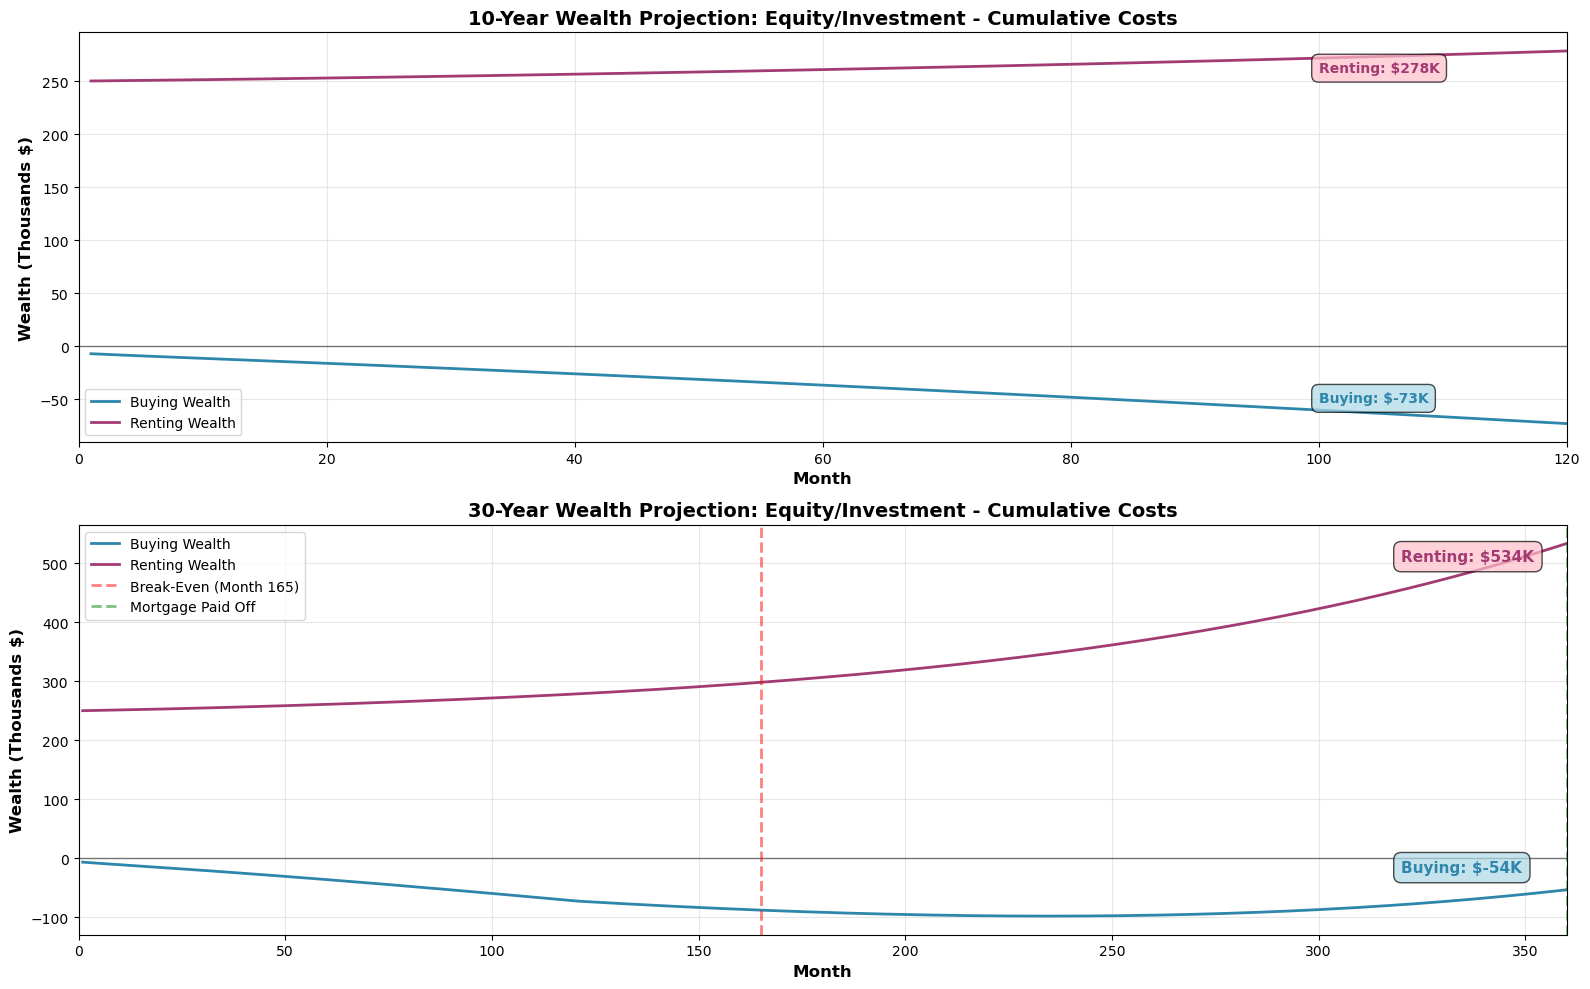


ALL VISUALIZATIONS COMPLETE

Generated Visualizations:
   1. utica_break_even_10yr.png - 10-Year Break-Even Analysis
   2. utica_break_even_30yr.png - 30-Year Break-Even Analysis
   3. utica_combined_comparison.png - Side-by-Side 10-Year vs 30-Year
   4. utica_wealth_projection_comparison.png - Wealth Projection Comparison

All visualizations saved to: ../data/output_utica/utica_


In [216]:
# ============================================
# VISUALIZATION 4: WEALTH PROJECTION COMPARISON
# ============================================

print("=" * 80)
print("VISUALIZATION 4: WEALTH PROJECTION - 10-YEAR vs 30-YEAR")
print("=" * 80)

# Create 30-year wealth projection
wealth_projection_30yr = pd.DataFrame(index=forecasts_30yr_aligned.index)
wealth_projection_30yr['Month'] = range(1, ANALYSIS_PERIOD_30YR_MONTHS + 1)
wealth_projection_30yr['Buying_Wealth'] = buying_30yr['Equity'] - buying_30yr['CumulativeCosts']
wealth_projection_30yr['Renting_Wealth'] = renting_30yr['InvestmentValue'] - renting_30yr['CumulativeRentPaid']
wealth_projection_30yr['Wealth_Difference'] = wealth_projection_30yr['Renting_Wealth'] - wealth_projection_30yr['Buying_Wealth']

fig, axes = plt.subplots(2, 1, figsize=(16, 10))

# Plot 1: Wealth Projection (10-year)
ax1 = axes[0]
ax1.plot(wealth_projection['Month'], wealth_projection['Buying_Wealth']/1000, 
         label='Buying Wealth', linewidth=2, color='#2E86AB')
ax1.plot(wealth_projection['Month'], wealth_projection['Renting_Wealth']/1000, 
         label='Renting Wealth', linewidth=2, color='#A23B72')
ax1.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)
ax1.set_xlabel('Month', fontsize=12, fontweight='bold')
ax1.set_ylabel('Wealth (Thousands $)', fontsize=12, fontweight='bold')
ax1.set_title('10-Year Wealth Projection: Equity/Investment - Cumulative Costs', fontsize=14, fontweight='bold')
ax1.legend(loc='best', fontsize=10)
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, 120)

# Add final values annotation
final_buying_10yr = wealth_projection['Buying_Wealth'].iloc[-1]/1000
final_renting_10yr = wealth_projection['Renting_Wealth'].iloc[-1]/1000
ax1.annotate(f'Buying: ${final_buying_10yr:,.0f}K', 
            xy=(120, final_buying_10yr), xytext=(100, final_buying_10yr + 20),
            fontsize=10, fontweight='bold', color='#2E86AB',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))
ax1.annotate(f'Renting: ${final_renting_10yr:,.0f}K', 
            xy=(120, final_renting_10yr), xytext=(100, final_renting_10yr - 20),
            fontsize=10, fontweight='bold', color='#A23B72',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='pink', alpha=0.7))

# Plot 2: Wealth Projection (30-year)
ax2 = axes[1]
ax2.plot(wealth_projection_30yr['Month'], wealth_projection_30yr['Buying_Wealth']/1000, 
         label='Buying Wealth', linewidth=2, color='#2E86AB')
ax2.plot(wealth_projection_30yr['Month'], wealth_projection_30yr['Renting_Wealth']/1000, 
         label='Renting Wealth', linewidth=2, color='#A23B72')
ax2.axhline(y=0, color='black', linestyle='-', linewidth=1, alpha=0.5)

# Mark break-even and mortgage payoff
if sign_changes_30yr > 0:
    ax2.axvline(x=break_even_month_30yr, color='red', linestyle='--', alpha=0.5, linewidth=2, 
               label=f'Break-Even (Month {break_even_month_30yr})')
ax2.axvline(x=360, color='green', linestyle='--', alpha=0.5, linewidth=2, label='Mortgage Paid Off')

ax2.set_xlabel('Month', fontsize=12, fontweight='bold')
ax2.set_ylabel('Wealth (Thousands $)', fontsize=12, fontweight='bold')
ax2.set_title('30-Year Wealth Projection: Equity/Investment - Cumulative Costs', fontsize=14, fontweight='bold')
ax2.legend(loc='best', fontsize=10)
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, 360)

# Add final values annotation
final_buying_30yr = wealth_projection_30yr['Buying_Wealth'].iloc[-1]/1000
final_renting_30yr = wealth_projection_30yr['Renting_Wealth'].iloc[-1]/1000
ax2.annotate(f'Buying: ${final_buying_30yr:,.0f}K', 
            xy=(360, final_buying_30yr), xytext=(320, final_buying_30yr + 30),
            fontsize=11, fontweight='bold', color='#2E86AB',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='lightblue', alpha=0.7))
ax2.annotate(f'Renting: ${final_renting_30yr:,.0f}K', 
            xy=(360, final_renting_30yr), xytext=(320, final_renting_30yr - 30),
            fontsize=11, fontweight='bold', color='#A23B72',
            bbox=dict(boxstyle='round,pad=0.5', facecolor='pink', alpha=0.7))

plt.tight_layout()
plt.savefig('../data/output_utica/utica_wealth_projection_comparison.png', dpi=300, bbox_inches='tight')
print("   ✓ Visualization saved to: ../data/output_utica/utica_wealth_projection_comparison.png")
plt.show()

print("\n" + "=" * 80)
print("ALL VISUALIZATIONS COMPLETE")
print("=" * 80)
print("\nGenerated Visualizations:")
print("   1. utica_break_even_10yr.png - 10-Year Break-Even Analysis")
print("   2. utica_break_even_30yr.png - 30-Year Break-Even Analysis")
print("   3. utica_combined_comparison.png - Side-by-Side 10-Year vs 30-Year")
print("   4. utica_wealth_projection_comparison.png - Wealth Projection Comparison")
print("\nAll visualizations saved to: ../data/output_utica/utica_")
